In [1]:
import os
import gc
import glob
import json
#import h5py
import numpy as np
import pickle
import pandas as pd
#from IPython.display import Audio, display
from collections import Counter, defaultdict
from pynwb import NWBHDF5IO
from datetime import datetime
import scipy.signal
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cosine, euclidean
from scipy.signal import decimate

In [2]:
from extract_features import extractHG, stackFeatures, downsampleLabels
from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
#from feature_vizualizer import PhonemeFeatureVisualizer
from markov_phoneme_model import MarkovPhonemeModel
from extract_features import extractHG, downsampleLabels, extractMelSpecs
from pipeline import UnifiedPhonemePipeline
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch


In [3]:
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from phoneme_detection_diagnostic import Dutch30PhonemeDetectionDiagnostic 
from dataset_config import Dutch30Config

from transformers import Wav2Vec2Model, Wav2Vec2Processor
import torch

In [4]:
# plt.ion()

In [5]:
dutch30_dir = DUTCH_30_PATH

# List all .npy files for one patient
patient_files = glob.glob(os.path.join(dutch30_dir, 'P01*.npy'))

In [6]:
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')

BIDS path: C:\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: C:\mozg\code\SingleWordProductionDutch\features
Results path: C:\mozg\code\SingleWordProductionDutch\results


In [7]:
# Create config
# config = Dutch30Config()

# # Pass config to both extractor and pipeline
# extractor = Dutch30FeatureExtractor(config=config)

# pipeline = Dutch30Pipeline(
#     dutch30_extractor=extractor,
#     config=config, 
#     debug_mode=True,
#     pca_components=100,
#     feature_extraction_method='high_gamma', 
    
# )

# # Debug a specific patient
# pipeline.debug_sentence_parsing('sub-p21', max_samples=3)
# print([attr for attr in dir(pipeline_debug) if 'detect' in attr.lower()])

In [8]:
# Load pre-trained wav2vec model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", use_safetensors=True)
config = Dutch30Config()
extractor = Dutch30FeatureExtractor()

C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz


In [9]:
config = Dutch30Config()
extractor = Dutch30FeatureExtractor(config=config)

high_gamma_pipeline = Dutch30Pipeline(
    dutch30_extractor=extractor,
    config=config, 
    debug_mode=False,
    pca_components= None, #100,
    feature_extraction_method = 'high_gamma',# 'high_gamma', #'band_powers', #'band_power_hjorth', # 'hjorth', #'band_powers',# 'hjorth', #'high_gamma', # 'band_powers', # 'band_power_hjorth'
    use_rms_boundaries=False,   
    use_multifeature=False,
    use_wav2vec=True,
    subtract_baseline=False,
    #baseline_method = 'band_powers' #'feature_matched', 'band_powers', 'raw'
)


Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 1 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=None, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: A

In [10]:
# step_0
# pipeline.analyze_dutch30_channels()
#pipeline.step1_load_dutch30_data(num_patients = 20)
#best_patients = ['P03', 'P11', 'P16', 'P17', 'P21']
#pipeline.step1_load_dutch30_data(patient_ids=best_patients)

high_gamma_pipeline.step1_load_dutch30_data(patient_range=(1,30))
high_gamma_pipeline.split_result = None
high_gamma_pipeline.step2_split_by_instances();

UnifiedPhonemePipeline: Step 1: Loading Dutch30...
UnifiedPhonemePipeline:   Using patients P01 to P30: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline: P01: 70 train, 31 test, baseline: (130,)
UnifiedPhonemePipeline: P02: 68 train, 33 test, baseline: (130,)
UnifiedPhonemePipeline: P03: 71 train, 30 test, baseline: (133,)
UnifiedPhonemePipeline: P04: 78 train, 23 test, baseline: (128,)
UnifiedPhonemePipeline: P06: 76 train, 25 test, baseline: (133,)
UnifiedPhonemePipeline: P07: 66 train, 35 test, baseline: (130,)
UnifiedPhonemePipeline: P08: 68 train, 33 test, baseline: (127,)
UnifiedPhonemePipeline: P09: 81 train, 19 test, baseline: (125,)
UnifiedPhonemePipeline: P10: 62 train, 34 test, baseline: (125,)
UnifiedPhonemePipeline: P11: 60 train, 40 test, baseline: (130,)
UnifiedPhonemePipeline: P12: 60 train, 40 test, baseline

In [16]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import welch, butter, filtfilt
# from collections import defaultdict
# import json

# class ChannelInspector:
#     """
#     Visual inspection tool for EEG channels to manually identify bad channels.
    
#     Creates detailed plots showing:
#     - Raw signal traces for each channel
#     - Power spectral density
#     - Channel statistics (std, kurtosis, etc.)
#     - High-gamma band activity
#     """
    
#     def __init__(self, pipeline):
#         self.pipeline = pipeline
#         self.config = pipeline.config
#         self.word_segments_dict = pipeline.split_result['word_segments_dict']
#         self.eeg_sr = pipeline.config.eeg_sr
        
#         # Store exclusion decisions
#         self.exclusions = {}
    
#     def get_patient_eeg(self, patient_id, n_words=30, n_instances_per_word=3, max_duration_sec=10):
#         """
#         Extract concatenated EEG for a patient.
        
#         Args:
#             patient_id: Patient ID
#             n_words: Number of words to sample
#             n_instances_per_word: Instances per word
#             max_duration_sec: Maximum duration to extract
            
#         Returns:
#             eeg: (n_samples, n_channels) array
#         """
#         if patient_id not in self.word_segments_dict:
#             raise ValueError(f"Patient {patient_id} not found")
        
#         words_data = self.word_segments_dict[patient_id]['words']
        
#         all_eeg = []
#         total_samples = 0
#         max_samples = int(max_duration_sec * self.eeg_sr)
        
#         for word, word_info in list(words_data.items())[:n_words]:
#             for instance in word_info['instances'][:n_instances_per_word]:
#                 eeg = instance['eeg_segment']
#                 if eeg is not None and eeg.size > 0:
#                     all_eeg.append(eeg)
#                     total_samples += eeg.shape[0]
#                     if total_samples >= max_samples:
#                         break
#             if total_samples >= max_samples:
#                 break
        
#         if not all_eeg:
#             raise ValueError(f"No EEG data found for {patient_id}")
        
#         eeg_concat = np.vstack(all_eeg)
        
#         # Trim to max duration
#         if eeg_concat.shape[0] > max_samples:
#             eeg_concat = eeg_concat[:max_samples, :]
        
#         return eeg_concat
    
#     def compute_channel_stats(self, eeg):
#         """
#         Compute statistics for each channel.
        
#         Args:
#             eeg: (n_samples, n_channels) array
            
#         Returns:
#             dict with per-channel statistics
#         """
#         n_channels = eeg.shape[1]
        
#         stats = {
#             'std': np.std(eeg, axis=0),
#             'mean': np.mean(eeg, axis=0),
#             'min': np.min(eeg, axis=0),
#             'max': np.max(eeg, axis=0),
#             'range': np.ptp(eeg, axis=0),
#             'kurtosis': np.zeros(n_channels),
#             'skewness': np.zeros(n_channels),
#         }
        
#         # Compute kurtosis and skewness
#         for ch in range(n_channels):
#             data = eeg[:, ch]
#             mean = stats['mean'][ch]
#             std = stats['std'][ch] + 1e-10
            
#             # Kurtosis (excess)
#             stats['kurtosis'][ch] = np.mean(((data - mean) / std) ** 4) - 3
#             # Skewness
#             stats['skewness'][ch] = np.mean(((data - mean) / std) ** 3)
        
#         return stats
    
#     def extract_high_gamma(self, eeg):
#         """Extract high-gamma band (70-170 Hz) envelope."""
#         nyq = self.eeg_sr / 2
#         low = 70 / nyq
#         high = min(170 / nyq, 0.99)
        
#         if low >= high:
#             return np.abs(eeg)
        
#         try:
#             b, a = butter(4, [low, high], btype='band')
#             filtered = filtfilt(b, a, eeg, axis=0)
#             from scipy.signal import hilbert
#             envelope = np.abs(hilbert(filtered, axis=0))
#             return envelope
#         except:
#             return np.abs(eeg)
    
#     def plot_channel_overview(self, patient_id, figsize=(20, 16)):
#         """
#         Plot overview of all channels for a patient.
        
#         Shows:
#         - Channel statistics as bar plots
#         - Flags potentially bad channels
#         """
#         print(f"Loading data for {patient_id}...")
#         eeg = self.get_patient_eeg(patient_id, max_duration_sec=15)
#         stats = self.compute_channel_stats(eeg)
        
#         n_channels = eeg.shape[1]
#         print(f"Channels: {n_channels}, Duration: {eeg.shape[0]/self.eeg_sr:.1f}s")
        
#         # Identify outliers
#         std_median = np.median(stats['std'])
#         std_mad = np.median(np.abs(stats['std'] - std_median))
        
#         high_std = stats['std'] > std_median + 5 * std_mad
#         low_std = stats['std'] < std_median * 0.1
#         high_kurtosis = stats['kurtosis'] > 10
        
#         suspect_channels = high_std | low_std | high_kurtosis
        
#         fig, axes = plt.subplots(2, 2, figsize=figsize)
        
#         # Plot 1: Standard deviation
#         ax = axes[0, 0]
#         colors = ['red' if suspect_channels[i] else 'steelblue' for i in range(n_channels)]
#         ax.bar(range(n_channels), stats['std'], color=colors, alpha=0.7, width=1.0)
#         ax.axhline(std_median, color='green', linestyle='-', linewidth=2, label=f'Median: {std_median:.1f}')
#         ax.axhline(std_median + 5*std_mad, color='red', linestyle='--', label=f'Threshold: {std_median + 5*std_mad:.1f}')
#         ax.set_xlabel('Channel')
#         ax.set_ylabel('Standard Deviation')
#         ax.set_title(f'{patient_id}: Channel Std Dev (red = suspect)')
#         ax.legend()
        
#         # Plot 2: Kurtosis
#         ax = axes[0, 1]
#         colors = ['red' if high_kurtosis[i] else 'steelblue' for i in range(n_channels)]
#         ax.bar(range(n_channels), np.clip(stats['kurtosis'], -10, 50), color=colors, alpha=0.7, width=1.0)
#         ax.axhline(10, color='red', linestyle='--', label='Threshold: 10')
#         ax.axhline(0, color='gray', linestyle='-', alpha=0.5)
#         ax.set_xlabel('Channel')
#         ax.set_ylabel('Excess Kurtosis')
#         ax.set_title(f'{patient_id}: Channel Kurtosis (high = spiky)')
#         ax.legend()
        
#         # Plot 3: Range
#         ax = axes[1, 0]
#         ax.bar(range(n_channels), stats['range'], color='steelblue', alpha=0.7, width=1.0)
#         ax.set_xlabel('Channel')
#         ax.set_ylabel('Range (max - min)')
#         ax.set_title(f'{patient_id}: Channel Range')
        
#         # Plot 4: Summary
#         ax = axes[1, 1]
#         suspect_idx = np.where(suspect_channels)[0]
        
#         text = f"Patient: {patient_id}\n"
#         text += f"Total channels: {n_channels}\n"
#         text += f"Duration: {eeg.shape[0]/self.eeg_sr:.1f} seconds\n"
#         text += f"Sampling rate: {self.eeg_sr} Hz\n\n"
#         text += f"Suspect channels: {len(suspect_idx)}\n"
#         text += f"  High std: {sum(high_std)}\n"
#         text += f"  Low std (flat): {sum(low_std)}\n"
#         text += f"  High kurtosis: {sum(high_kurtosis)}\n\n"
        
#         if len(suspect_idx) > 0:
#             text += f"Suspect indices:\n{list(suspect_idx)}"
        
#         ax.text(0.1, 0.9, text, transform=ax.transAxes, fontsize=12,
#                 verticalalignment='top', fontfamily='monospace')
#         ax.axis('off')
#         ax.set_title('Summary')
        
#         plt.suptitle(f'Channel Quality Overview: {patient_id}', fontsize=16, fontweight='bold')
#         plt.tight_layout()
#         plt.show()
        
#         return suspect_idx
    
#     def plot_channel_traces(self, patient_id, channels=None, duration_sec=5, 
#                             offset_scale=None, figsize=(20, 20)):
#         """
#         Plot raw signal traces for selected channels.
        
#         Args:
#             patient_id: Patient ID
#             channels: List of channel indices to plot (None = first 30)
#             duration_sec: Duration to plot in seconds
#             offset_scale: Vertical offset between channels (None = auto)
#             figsize: Figure size
#         """
#         print(f"Loading data for {patient_id}...")
#         eeg = self.get_patient_eeg(patient_id, max_duration_sec=duration_sec + 1)
#         stats = self.compute_channel_stats(eeg)
        
#         n_samples = min(int(duration_sec * self.eeg_sr), eeg.shape[0])
#         n_channels_total = eeg.shape[1]
        
#         if channels is None:
#             channels = list(range(min(30, n_channels_total)))
        
#         n_channels = len(channels)
        
#         # Time axis
#         time = np.arange(n_samples) / self.eeg_sr
        
#         # Auto-scale offset
#         if offset_scale is None:
#             offset_scale = np.median(stats['std']) * 6
        
#         fig, ax = plt.subplots(figsize=figsize)
        
#         # Identify suspect channels
#         std_median = np.median(stats['std'])
#         std_mad = np.median(np.abs(stats['std'] - std_median))
        
#         for i, ch in enumerate(channels):
#             signal = eeg[:n_samples, ch]
            
#             # Normalize to zero mean
#             signal = signal - np.mean(signal)
            
#             # Offset for stacking
#             offset = i * offset_scale
            
#             # Color based on quality
#             ch_std = stats['std'][ch]
#             ch_kurt = stats['kurtosis'][ch]
            
#             if ch_std > std_median + 5 * std_mad:
#                 color = 'red'
#                 label_suffix = ' [HIGH STD]'
#             elif ch_std < std_median * 0.1:
#                 color = 'orange'
#                 label_suffix = ' [FLAT]'
#             elif ch_kurt > 10:
#                 color = 'purple'
#                 label_suffix = ' [SPIKY]'
#             else:
#                 color = 'black'
#                 label_suffix = ''
            
#             ax.plot(time, signal + offset, color=color, linewidth=0.5, alpha=0.8)
            
#             # Channel label
#             ax.text(-0.05, offset, f'Ch {ch}{label_suffix}', fontsize=8, 
#                     verticalalignment='center', color=color)
        
#         ax.set_xlabel('Time (seconds)', fontsize=12)
#         ax.set_ylabel('Channels (with offset)', fontsize=12)
#         ax.set_title(f'{patient_id}: Raw EEG Traces (Channels {channels[0]}-{channels[-1]})\n'
#                      f'Red=high std, Orange=flat, Purple=spiky', fontsize=14)
#         ax.set_xlim([0, duration_sec])
#         ax.set_yticks([])
        
#         plt.tight_layout()
#         plt.show()
    
#     def plot_channel_psd(self, patient_id, channels=None, figsize=(20, 16)):
#         """
#         Plot power spectral density for selected channels.
        
#         Args:
#             patient_id: Patient ID
#             channels: List of channel indices (None = first 20)
#             figsize: Figure size
#         """
#         print(f"Loading data for {patient_id}...")
#         eeg = self.get_patient_eeg(patient_id, max_duration_sec=20)
#         stats = self.compute_channel_stats(eeg)
        
#         n_channels_total = eeg.shape[1]
        
#         if channels is None:
#             channels = list(range(min(20, n_channels_total)))
        
#         n_channels = len(channels)
#         n_cols = 5
#         n_rows = (n_channels + n_cols - 1) // n_cols
        
#         fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
#         axes = axes.flatten()
        
#         # Identify suspect channels
#         std_median = np.median(stats['std'])
#         std_mad = np.median(np.abs(stats['std'] - std_median))
        
#         for i, ch in enumerate(channels):
#             ax = axes[i]
            
#             # Compute PSD
#             freqs, psd = welch(eeg[:, ch], fs=self.eeg_sr, nperseg=512)
            
#             # Color based on quality
#             ch_std = stats['std'][ch]
#             ch_kurt = stats['kurtosis'][ch]
            
#             if ch_std > std_median + 5 * std_mad:
#                 color = 'red'
#                 status = 'HIGH STD'
#             elif ch_std < std_median * 0.1:
#                 color = 'orange'
#                 status = 'FLAT'
#             elif ch_kurt > 10:
#                 color = 'purple'
#                 status = 'SPIKY'
#             else:
#                 color = 'steelblue'
#                 status = 'OK'
            
#             ax.semilogy(freqs, psd, color=color, linewidth=1)
#             ax.axvspan(70, 170, alpha=0.2, color='green')
#             ax.axvline(70, color='green', linestyle='--', alpha=0.5)
#             ax.axvline(170, color='green', linestyle='--', alpha=0.5)
            
#             ax.set_xlim([0, 250])
#             ax.set_title(f'Ch {ch} [{status}]', fontsize=10, color=color)
#             ax.set_xlabel('Freq (Hz)', fontsize=8)
#             ax.set_ylabel('Power', fontsize=8)
#             ax.tick_params(labelsize=7)
        
#         # Hide unused axes
#         for i in range(n_channels, len(axes)):
#             axes[i].set_visible(False)
        
#         plt.suptitle(f'{patient_id}: Power Spectral Density per Channel\n'
#                      f'Green band = High Gamma (70-170 Hz)', fontsize=14, fontweight='bold')
#         plt.tight_layout()
#         plt.show()
    
#     def plot_detailed_inspection(self, patient_id, channels=None, duration_sec=3, figsize=(24, 20)):
#         """
#         Detailed inspection plot showing raw, filtered, and high-gamma for each channel.
        
#         Args:
#             patient_id: Patient ID
#             channels: List of channel indices (None = first 12)
#             duration_sec: Duration to show
#             figsize: Figure size
#         """
#         print(f"Loading data for {patient_id}...")
#         eeg = self.get_patient_eeg(patient_id, max_duration_sec=duration_sec + 1)
#         stats = self.compute_channel_stats(eeg)
        
#         n_samples = min(int(duration_sec * self.eeg_sr), eeg.shape[0])
#         n_channels_total = eeg.shape[1]
        
#         if channels is None:
#             channels = list(range(min(12, n_channels_total)))
        
#         # Extract high gamma
#         hg = self.extract_high_gamma(eeg[:n_samples, :])
        
#         time = np.arange(n_samples) / self.eeg_sr
        
#         n_channels = len(channels)
#         fig, axes = plt.subplots(n_channels, 3, figsize=figsize)
        
#         # Identify suspect channels
#         std_median = np.median(stats['std'])
#         std_mad = np.median(np.abs(stats['std'] - std_median))
        
#         for i, ch in enumerate(channels):
#             # Determine status
#             ch_std = stats['std'][ch]
#             ch_kurt = stats['kurtosis'][ch]
            
#             if ch_std > std_median + 5 * std_mad:
#                 status = 'HIGH STD'
#                 color = 'red'
#             elif ch_std < std_median * 0.1:
#                 status = 'FLAT'
#                 color = 'orange'
#             elif ch_kurt > 10:
#                 status = 'SPIKY'
#                 color = 'purple'
#             else:
#                 status = 'OK'
#                 color = 'black'
            
#             # Raw signal
#             ax = axes[i, 0]
#             ax.plot(time, eeg[:n_samples, ch], color=color, linewidth=0.5)
#             ax.set_ylabel(f'Ch {ch}\n[{status}]', fontsize=9, color=color)
#             if i == 0:
#                 ax.set_title('Raw Signal', fontsize=12)
#             if i == n_channels - 1:
#                 ax.set_xlabel('Time (s)')
#             ax.set_xlim([0, duration_sec])
            
#             # PSD
#             ax = axes[i, 1]
#             freqs, psd = welch(eeg[:, ch], fs=self.eeg_sr, nperseg=512)
#             ax.semilogy(freqs, psd, color=color, linewidth=1)
#             ax.axvspan(70, 170, alpha=0.2, color='green')
#             ax.set_xlim([0, 250])
#             if i == 0:
#                 ax.set_title('Power Spectrum', fontsize=12)
#             if i == n_channels - 1:
#                 ax.set_xlabel('Frequency (Hz)')
            
#             # High gamma envelope
#             ax = axes[i, 2]
#             ax.plot(time, hg[:, ch], color=color, linewidth=0.5)
#             if i == 0:
#                 ax.set_title('High Gamma Envelope (70-170 Hz)', fontsize=12)
#             if i == n_channels - 1:
#                 ax.set_xlabel('Time (s)')
#             ax.set_xlim([0, duration_sec])
        
#         plt.suptitle(f'{patient_id}: Detailed Channel Inspection\n'
#                      f'Red=high std, Orange=flat, Purple=spiky, Black=OK', 
#                      fontsize=14, fontweight='bold')
#         plt.tight_layout()
#         plt.show()
    
#     def plot_all_channels_grid(self, patient_id, duration_sec=2, channels_per_page=40, figsize=(24, 20)):
#         """
#         Plot all channels in a grid for comprehensive inspection.
        
#         Args:
#             patient_id: Patient ID
#             duration_sec: Duration to show per channel
#             channels_per_page: Channels per figure
#             figsize: Figure size
#         """
#         print(f"Loading data for {patient_id}...")
#         eeg = self.get_patient_eeg(patient_id, max_duration_sec=duration_sec + 1)
#         stats = self.compute_channel_stats(eeg)
        
#         n_samples = min(int(duration_sec * self.eeg_sr), eeg.shape[0])
#         n_channels_total = eeg.shape[1]
        
#         time = np.arange(n_samples) / self.eeg_sr
        
#         # Identify suspect channels
#         std_median = np.median(stats['std'])
#         std_mad = np.median(np.abs(stats['std'] - std_median))
        
#         n_pages = (n_channels_total + channels_per_page - 1) // channels_per_page
        
#         for page in range(n_pages):
#             start_ch = page * channels_per_page
#             end_ch = min(start_ch + channels_per_page, n_channels_total)
#             channels = list(range(start_ch, end_ch))
#             n_channels = len(channels)
            
#             n_cols = 8
#             n_rows = (n_channels + n_cols - 1) // n_cols
            
#             fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
#             axes = axes.flatten()
            
#             for i, ch in enumerate(channels):
#                 ax = axes[i]
                
#                 signal = eeg[:n_samples, ch]
#                 signal = signal - np.mean(signal)
                
#                 # Determine status
#                 ch_std = stats['std'][ch]
#                 ch_kurt = stats['kurtosis'][ch]
                
#                 if ch_std > std_median + 5 * std_mad:
#                     status = 'HIGH'
#                     color = 'red'
#                 elif ch_std < std_median * 0.1:
#                     status = 'FLAT'
#                     color = 'orange'
#                 elif ch_kurt > 10:
#                     status = 'SPIKY'
#                     color = 'purple'
#                 else:
#                     status = ''
#                     color = 'steelblue'
                
#                 ax.plot(time, signal, color=color, linewidth=0.3)
#                 ax.set_title(f'{ch} {status}', fontsize=8, color=color)
#                 ax.set_xticks([])
#                 ax.set_yticks([])
#                 ax.set_xlim([0, duration_sec])
            
#             # Hide unused
#             for i in range(n_channels, len(axes)):
#                 axes[i].set_visible(False)
            
#             plt.suptitle(f'{patient_id}: Channels {start_ch}-{end_ch-1} '
#                          f'(Page {page+1}/{n_pages})\n'
#                          f'Red=high std, Orange=flat, Purple=spiky', 
#                          fontsize=14, fontweight='bold')
#             plt.tight_layout()
#             plt.show()
    
#     def interactive_exclude(self, patient_id):
#         """
#         Interactive channel exclusion helper.
#         Shows summary and prompts for channels to exclude.
#         """
#         suspect = self.plot_channel_overview(patient_id)
        
#         print(f"\nSuspect channels identified: {list(suspect)}")
#         print("\nVisualization options:")
#         print("  1. inspector.plot_channel_traces('{pid}', channels=[...], duration_sec=5)")
#         print("  2. inspector.plot_channel_psd('{pid}', channels=[...])")
#         print("  3. inspector.plot_detailed_inspection('{pid}', channels=[...])")
#         print("  4. inspector.plot_all_channels_grid('{pid}')")
#         print(f"\nTo exclude channels, run:")
#         print(f"  inspector.set_exclusions('{patient_id}', [list of channel indices])")
    
#     def set_exclusions(self, patient_id, exclude_indices):
#         """
#         Set channels to exclude for a patient.
        
#         Args:
#             patient_id: Patient ID
#             exclude_indices: List of channel indices to exclude
#         """
#         eeg = self.get_patient_eeg(patient_id, max_duration_sec=1)
#         n_channels = eeg.shape[1]
        
#         keep_indices = [i for i in range(n_channels) if i not in exclude_indices]
        
#         self.exclusions[patient_id] = {
#             'exclude_indices': list(exclude_indices),
#             'keep_indices': keep_indices,
#             'n_original': n_channels,
#             'n_excluded': len(exclude_indices),
#             'n_kept': len(keep_indices)
#         }
        
#         print(f"{patient_id}: Excluding {len(exclude_indices)} channels, keeping {len(keep_indices)}")
#         print(f"  Excluded: {exclude_indices}")
    
#     def save_exclusions(self, filepath):
#         """Save exclusions to JSON file."""
#         with open(filepath, 'w') as f:
#             json.dump(self.exclusions, f, indent=2)
#         print(f"Saved exclusions to {filepath}")
    
#     def load_exclusions(self, filepath):
#         """Load exclusions from JSON file."""
#         with open(filepath, 'r') as f:
#             self.exclusions = json.load(f)
#         print(f"Loaded exclusions for {len(self.exclusions)} patients")
#         return self.exclusions

In [17]:
# # # Create inspector
# inspector = ChannelInspector(high_gamma_pipeline)

# # # # Step 1: Get overview for a patient
# # # inspector.plot_channel_overview('P01') 

# # # # Step 2: Look at raw traces (shows 30 channels, 5 seconds)
# # # inspector.plot_channel_traces('P01', channels=list(range(30)), duration_sec=5)

# # # # Step 3: Look at remaining channels
# # # inspector.plot_channel_traces('P01', channels=list(range(30, 60)), duration_sec=5)

# # # # Step 4: Grid view of ALL channels (multiple pages)
# # # inspector.plot_all_channels_grid('P05')

# # # # Step 5: Detailed inspection of specific suspect channels
# # # inspector.plot_detailed_inspection('P01', channels=[5, 12, 45, 67], duration_sec=3)

# # # # Step 6: Set exclusions based on your inspection
# inspector.set_exclusions('P01', [64, 129])
# inspector.set_exclusions('P02', [64, 129])
# inspector.set_exclusions('P03', [64, 129, 130, 131, 132])
# inspector.set_exclusions('P04', [64, 127])
# inspector.set_exclusions('P06', [64, 129, 130, 131, 132])
# inspector.set_exclusions('P07', [64, 127, 129])
# inspector.set_exclusions('P08', [61, 126])
# inspector.set_exclusions('P09', [61, 126])
# inspector.set_exclusions('P10', [62, 124])
# inspector.set_exclusions('P11', [64, 129])
# inspector.set_exclusions('P12', [57, 59])
# inspector.set_exclusions('P13', [61, 96])
# inspector.set_exclusions('P14', [64, 129])
# inspector.set_exclusions('P15', [64, 126])
# inspector.set_exclusions('P16', [63, 92])
# inspector.set_exclusions('P17', [55, 67])
# inspector.set_exclusions('P20', [64, 129])
# inspector.set_exclusions('P21', [55, 109])
# inspector.set_exclusions('P22', [63, 113])
# inspector.set_exclusions('P23', [64, 129])
# inspector.set_exclusions('P24', [64, 129])
# inspector.set_exclusions('P25', [62, 117])
# inspector.set_exclusions('P26', [61, 89])
# inspector.set_exclusions('P27', [64, 129])
# inspector.set_exclusions('P28', [7, 89])
# inspector.set_exclusions('P29', [53, 83])
# inspector.set_exclusions('P30', [64, 129])


# # # # Repeat for all patients...

# # # # Save to JSON
# inspector.save_exclusions('channel_exclusions.json')

P01: Excluding 2 channels, keeping 128
  Excluded: [64, 129]
P02: Excluding 2 channels, keeping 128
  Excluded: [64, 129]
P03: Excluding 5 channels, keeping 128
  Excluded: [64, 129, 130, 131, 132]
P04: Excluding 2 channels, keeping 126
  Excluded: [64, 127]
P06: Excluding 5 channels, keeping 128
  Excluded: [64, 129, 130, 131, 132]
P07: Excluding 3 channels, keeping 127
  Excluded: [64, 127, 129]
P08: Excluding 2 channels, keeping 125
  Excluded: [61, 126]
P09: Excluding 2 channels, keeping 124
  Excluded: [61, 126]
P10: Excluding 2 channels, keeping 123
  Excluded: [62, 124]
P11: Excluding 2 channels, keeping 128
  Excluded: [64, 129]
P12: Excluding 2 channels, keeping 58
  Excluded: [57, 59]
P13: Excluding 2 channels, keeping 95
  Excluded: [61, 96]
P14: Excluding 2 channels, keeping 128
  Excluded: [64, 129]
P15: Excluding 2 channels, keeping 125
  Excluded: [64, 126]
P16: Excluding 2 channels, keeping 91
  Excluded: [63, 92]
P17: Excluding 2 channels, keeping 66
  Excluded: [55, 6

In [20]:
import json

exclusions = {
    "P01": [64, 129],
    "P02": [64, 129],
    "P03": [64, 129, 130, 131, 132],
    "P04": [64, 127],
    "P06": [64, 129, 130, 131, 132],
    "P07": [64, 127, 129],
    "P08": [61, 126],
    "P09": [61, 126],
    "P10": [62, 124],
    "P11": [64, 129],
    "P12": [57, 59],
    "P13": [61, 96],
    "P14": [64, 129],
    "P15": [64, 126],
    "P16": [63, 92],
    "P17": [55, 67],
    "P20": [64, 129],
    "P21": [55, 109],
    "P22": [63, 113],
    "P23": [64, 129],
    "P24": [64, 129],
    "P25": [62, 117],
    "P26": [61, 89],
    "P27": [64, 129],
    "P28": [7, 89],
    "P29": [53, 83],
    "P30": [64, 129]
}

with open('channel_exclusions.json', 'w') as f:
    json.dump(exclusions, f, indent=2)

print("Saved to channel_exclusions.json")

Saved to channel_exclusions.json


In [21]:
high_gamma_pipeline.step3_load_channel_exclusions('channel_exclusions.json')

UnifiedPhonemePipeline: Step 3: Loading channel exclusions...
UnifiedPhonemePipeline:   Loaded exclusions for 27 patients
UnifiedPhonemePipeline:   P01: 128/130 channels kept
UnifiedPhonemePipeline:   P02: 128/130 channels kept
UnifiedPhonemePipeline:   P03: 128/133 channels kept
UnifiedPhonemePipeline:   P04: 126/128 channels kept
UnifiedPhonemePipeline:   P06: 128/133 channels kept
UnifiedPhonemePipeline:   P07: 127/130 channels kept
UnifiedPhonemePipeline:   P08: 125/127 channels kept
UnifiedPhonemePipeline:   P09: 124/125 channels kept
UnifiedPhonemePipeline:   P10: 123/125 channels kept
UnifiedPhonemePipeline:   P11: 128/130 channels kept
UnifiedPhonemePipeline:   P12: 58/60 channels kept
UnifiedPhonemePipeline:   P13: 95/97 channels kept
UnifiedPhonemePipeline:   P14: 128/130 channels kept
UnifiedPhonemePipeline:   P15: 125/127 channels kept
UnifiedPhonemePipeline:   P16: 91/93 channels kept
UnifiedPhonemePipeline:   P17: 66/68 channels kept
UnifiedPhonemePipeline:   P20: 128/130

{'P01': {'exclude_indices': [64, 129],
  'keep_indices': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128],
  'n_original': 130,
  'n_kep

In [22]:
# band_powers_pipeline.step4_custom_detector()
high_gamma_pipeline.step4_custom_detector()
# hjorth_pipeline.step4_custom_detector()

UnifiedPhonemePipeline: Step 4: Initializing detector...
AcousticChangeDetector: Initialized with DEBUG_MODE=False
AcousticChangeDetector: Using feature extraction method: high_gamma
AcousticChangeDetector: Initializing wav2vec model for boundary detection...


C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


AcousticChangeDetector: Wav2vec model initialized successfully


In [23]:
# band_powers_pipeline.step5_accumulate_data_dutch30();
high_gamma_pipeline.step5_accumulate_data_dutch30();
# hjorth_pipeline.step5_accumulate_data_dutch30();

UnifiedPhonemePipeline: 
Step 5 starting:
UnifiedPhonemePipeline:   Train patients: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline:   Available samples: train=4816, test=2496
AcousticChangeDetector: Processing 4816 instances in 38 batches (no replacement)
AcousticChangeDetector: Processing batch 1/38
          Building batch from 128 instances...
          Batch built: 128 words
          Processing batch (phoneme detection)...
AcousticChangeDetector:   Need 10 peaks but only found 5 for word 'zevenduizend' (Patient P01)
AcousticChangeDetector:   Need 10 peaks but only found 9 for word 'vogelkooitje' (Patient P01)
AcousticChangeDetector:   Need 12 peaks but only found 11 for word 'teruggekregen' (Patient P01)
AcousticChangeDetector:   Need 6 peaks but only found 5 for word 'helemaal' (Patient P01)
AcousticChangeDetector:  

In [24]:
# band_powers_pipeline.dutch30_step6_resolve_unknowns();
high_gamma_pipeline.dutch30_step6_resolve_unknowns();
# hjorth_pipeline.dutch30_step6_resolve_unknowns();

UnifiedPhonemePipeline: Train data keys: dict_keys(['features', 'phoneme_labels', 'phoneme_words', 'phoneme_positions', 'phoneme_participant_ids', 'phoneme_durations_samples', 'spectrograms', 'metadata'])
UnifiedPhonemePipeline: Unknown count: 5683
PhonemeValidator: Initialized with DEBUG_MODE=False
UnifiedPhonemePipeline: Step 6: Validator initialized
UnifiedPhonemePipeline: Resolving 5683 unknown phonemes in training...
UnifiedPhonemePipeline: Test unknowns: 2621
UnifiedPhonemePipeline: WARNING: Still 97 unknown in train, 30 in test
UnifiedPhonemePipeline: Step 6 complete: 17646 train, 8691 test
UnifiedPhonemePipeline:   Unknown remaining: 97 train, 30 test


In [25]:
# band_powers_pipeline.checkpoint_after_step6()
high_gamma_pipeline.checkpoint_after_step6()
# band_powers_pipeline.checkpoint_after_step6(sample_fraction=1)
# high_gamma_pipeline.checkpoint_after_step6(sample_fraction=1)
# hjorth_pipeline.checkpoint_after_step6(sample_fraction=1)

UnifiedPhonemePipeline: Saving checkpoint: pipeline_high_gamma_pcaNone_after_step6_20260118_234455.pkl
UnifiedPhonemePipeline: Checkpoint saved: pipeline_high_gamma_pcaNone_after_step6_20260118_234455.pkl


'C:\\mozg\\code\\SingleWordProductionDutch\\results\\dutch30\\pipeline_high_gamma_pcaNone_after_step6_20260118_234455.pkl'

In [17]:
high_gamma_pipeline.try_load_checkpoint(sample_fraction=1)
# pipeline.try_load_checkpoint(sample_fraction=0.0001)

UnifiedPhonemePipeline: No checkpoint found for high_gamma, PCA=None, sample=1


False

In [26]:
# band_powers_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);
high_gamma_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);
# hjorth_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);

UnifiedPhonemePipeline: Filtered training: 17556 samples (from 17646)


In [23]:
# Check if pipeline has any partial results
if hasattr(high_gamma_pipeline, 'detector'):
    print("Detector exists")
    
# Check if there's any train data accumulating
if hasattr(high_gamma_pipeline, 'train') and high_gamma_pipeline.train is not None:
    print(f"Train data so far: {len(high_gamma_pipeline.train.get('phoneme_labels', []))} phonemes")

Detector exists
Train data so far: 14149 phonemes


In [32]:
def test_classifiers_for_markov_v2(pipeline, patient_id='P23'):
    """
    Test classifiers with proper handling of class imbalance.
    
    Improvements:
    1. Use stratified sampling to balance classes
    2. Calculate baseline from majority class (not uniform)
    3. Report balanced accuracy
    4. Filter rare classes
    """
    import numpy as np
    from collections import Counter
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.svm import LinearSVC
    from sklearn.linear_model import LogisticRegression
    from sklearn.neural_network import MLPClassifier
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.metrics import balanced_accuracy_score
    
    try:
        from xgboost import XGBClassifier
        has_xgb = True
    except ImportError:
        has_xgb = False
        print("XGBoost not installed, skipping")
    
    try:
        from lightgbm import LGBMClassifier
        has_lgbm = True
    except ImportError:
        has_lgbm = False
        print("LightGBM not installed, skipping")
    
    print("="*70)
    print(f"CLASSIFIER COMPARISON FOR {patient_id} (v2 - balanced)")
    print("="*70)
    
    # Get data for this patient
    train_mask = [p == patient_id for p in pipeline.train['phoneme_participant_ids']]
    test_mask = [p == patient_id for p in pipeline.test['phoneme_participant_ids']]
    
    train_feat = [pipeline.train['features'][i] for i, m in enumerate(train_mask) if m]
    train_labels = [pipeline.train['phoneme_labels'][i] for i, m in enumerate(train_mask) if m]
    test_feat = [pipeline.test['features'][i] for i, m in enumerate(test_mask) if m]
    test_labels = [pipeline.test['phoneme_labels'][i] for i, m in enumerate(test_mask) if m]
    
    # Prepare features
    X_train = np.array([f.mean(axis=0) if f.ndim > 1 else f for f in train_feat])
    X_test = np.array([f.mean(axis=0) if f.ndim > 1 else f for f in test_feat])
    y_train = np.array(train_labels)
    y_test = np.array(test_labels)
    
    # Filter unknown labels
    train_valid = y_train != '?'
    test_valid = y_test != '?'
    X_train = X_train[train_valid]
    y_train = y_train[train_valid]
    X_test = X_test[test_valid]
    y_test = y_test[test_valid]
    
    # Filter rare classes (need at least 3 in train AND 1 in test)
    train_counts = Counter(y_train)
    test_counts = Counter(y_test)
    
    valid_classes = [c for c, count in train_counts.items() 
                     if count >= 3 and c in test_counts]
    
    train_keep = np.isin(y_train, valid_classes)
    test_keep = np.isin(y_test, valid_classes)
    
    X_train = X_train[train_keep]
    y_train = y_train[train_keep]
    X_test = X_test[test_keep]
    y_test = y_test[test_keep]
    
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    print(f"Classes: {len(valid_classes)}")
    
    # Show class distribution
    train_counts = Counter(y_train)
    test_counts = Counter(y_test)
    
    print(f"\nTop 5 classes in train: {train_counts.most_common(5)}")
    print(f"Top 5 classes in test: {test_counts.most_common(5)}")
    
    # Calculate baselines
    n_classes = len(valid_classes)
    random_baseline = 1 / n_classes
    majority_class = train_counts.most_common(1)[0][0]
    majority_baseline = test_counts[majority_class] / len(y_test)
    
    print(f"\nBaselines:")
    print(f"  Random: {random_baseline:.4f}")
    print(f"  Majority ('{majority_class}'): {majority_baseline:.4f}")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Encode labels
    le = LabelEncoder()
    le.fit(valid_classes)
    y_train_enc = le.transform(y_train)
    y_test_enc = le.transform(y_test)
    
    # Define classifiers
    classifiers = {
        'RF_balanced': RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ),
        'RF_balanced_subsample': RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_leaf=3,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1
        ),
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        ),
        'LogisticRegression': LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        ),
        'MLP_small': MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ),
        'MLP_large': MLPClassifier(
            hidden_layer_sizes=(256, 128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ),
    }
    
    if has_xgb:
        # Compute class weights for XGBoost
        class_counts = np.bincount(y_train_enc)
        class_weights = len(y_train_enc) / (len(class_counts) * class_counts)
        sample_weights = class_weights[y_train_enc]
        
        classifiers['XGBoost'] = {
            'clf': XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                n_jobs=-1,
                eval_metric='mlogloss'
            ),
            'sample_weight': sample_weights
        }
    
    if has_lgbm:
        classifiers['LightGBM'] = LGBMClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
    
    # Test each classifier
    results = {}
    
    for name, clf_config in classifiers.items():
        print(f"\nTesting {name}...")
        
        try:
            # Handle XGBoost with sample weights
            if isinstance(clf_config, dict):
                clf = clf_config['clf']
                clf.fit(X_train_scaled, y_train_enc, 
                       sample_weight=clf_config['sample_weight'])
            else:
                clf = clf_config
                clf.fit(X_train_scaled, y_train_enc)
            
            y_pred_enc = clf.predict(X_test_scaled)
            y_pred = le.inverse_transform(y_pred_enc)
            
            # Standard accuracy
            accuracy = np.mean(y_pred == y_test)
            
            # Balanced accuracy (average of per-class recall)
            bal_accuracy = balanced_accuracy_score(y_test, y_pred)
            
            # Lift over baselines
            lift_random = accuracy / random_baseline
            lift_majority = accuracy / majority_baseline
            lift_balanced = bal_accuracy / random_baseline
            
            # Prediction diversity
            pred_counts = Counter(y_pred)
            n_unique_preds = len(pred_counts)
            top_pred, top_count = pred_counts.most_common(1)[0]
            top_pct = 100 * top_count / len(y_pred)
            
            results[name] = {
                'accuracy': accuracy,
                'balanced_accuracy': bal_accuracy,
                'lift_random': lift_random,
                'lift_majority': lift_majority,
                'lift_balanced': lift_balanced,
                'n_unique_preds': n_unique_preds,
                'top_pred': top_pred,
                'top_pct': top_pct,
                'predictions': y_pred
            }
            
            print(f"  Accuracy: {accuracy:.4f} (lift vs random: {lift_random:.2f}x)")
            print(f"  Balanced Accuracy: {bal_accuracy:.4f} (lift: {lift_balanced:.2f}x)")
            print(f"  Unique predictions: {n_unique_preds}/{n_classes}")
            print(f"  Top prediction: '{top_pred}' = {top_pct:.1f}%")
            
        except Exception as e:
            print(f"  FAILED: {e}")
            import traceback
            traceback.print_exc()
            results[name] = {'error': str(e)}
    
    # Summary table
    print("\n" + "="*70)
    print("SUMMARY (sorted by Balanced Accuracy)")
    print("="*70)
    
    print(f"{'Classifier':<22} {'Acc':<8} {'BalAcc':<8} {'Lift':<8} {'Unique':<8} {'Top%':<8}")
    print("-"*70)
    
    sorted_results = sorted(
        [(k, v) for k, v in results.items() if 'accuracy' in v],
        key=lambda x: x[1]['balanced_accuracy'],
        reverse=True
    )
    
    for name, r in sorted_results:
        print(f"{name:<22} {r['accuracy']:<8.4f} {r['balanced_accuracy']:<8.4f} "
              f"{r['lift_balanced']:<8.2f}x {r['n_unique_preds']:<8} {r['top_pct']:<8.1f}%")
    
    # Best classifier
    best_name, best_result = sorted_results[0]
    print(f"\nBest by Balanced Accuracy: {best_name}")
    print(f"  Accuracy: {best_result['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {best_result['balanced_accuracy']:.4f}")
    print(f"  Predicts {best_result['n_unique_preds']}/{n_classes} classes")
    
    return results, scaler, le


# Run the comparison
classifier_results, scaler, label_encoder = test_classifiers_for_markov_v2(
    high_gamma_pipeline, 
    patient_id='P26'
)

CLASSIFIER COMPARISON FOR P26 (v2 - balanced)
Train: 1085, Test: 572
Classes: 37

Top 5 classes in train: [('ə', 143), ('n', 108), ('t', 81), ('d', 60), ('r', 56)]
Top 5 classes in test: [('ə', 70), ('n', 44), ('t', 43), ('k', 28), ('s', 27)]

Baselines:
  Random: 0.0270
  Majority ('ə'): 0.1224

Testing RF_balanced...
  Accuracy: 0.0280 (lift vs random: 1.03x)
  Balanced Accuracy: 0.0193 (lift: 0.72x)
  Unique predictions: 37/37
  Top prediction: 'ə' = 13.5%

Testing RF_balanced_subsample...
  Accuracy: 0.0192 (lift vs random: 0.71x)
  Balanced Accuracy: 0.0196 (lift: 0.72x)
  Unique predictions: 37/37
  Top prediction: 'm' = 7.7%

Testing GradientBoosting...
  Accuracy: 0.0629 (lift vs random: 2.33x)
  Balanced Accuracy: 0.0233 (lift: 0.86x)
  Unique predictions: 36/37
  Top prediction: 'ə' = 33.4%

Testing LogisticRegression...
  Accuracy: 0.0350 (lift vs random: 1.29x)
  Balanced Accuracy: 0.0312 (lift: 1.15x)
  Unique predictions: 34/37
  Top prediction: 'h' = 5.9%

Testing MLP_sm

C:\Users\irina\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [29]:
def run_balanced_quick_tests(pipeline, patient_ids=None):
    """
    Run quick tests with balanced accuracy metric.
    
    Tests:
    1. Temporal delays - check if phoneme boundaries are correct
    2. Channel selection - multiple strategies
    """
    import numpy as np
    from collections import Counter
    from scipy import stats
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.metrics import make_scorer, balanced_accuracy_score
    
    if patient_ids is None:
        patient_ids = ['P21', 'P22', 'P23', 'P24', 'P25']
    
    print("="*70)
    print("BALANCED QUICK TESTS")
    print("="*70)
    
    train_data = pipeline.train
    word_segments_dict = pipeline.split_result['word_segments_dict']
    
    bal_acc_scorer = make_scorer(balanced_accuracy_score)
    
    def prepare_data(pid, features, labels):
        """Prepare and filter data for a patient."""
        X = []
        y = []
        for feat, label in zip(features, labels):
            if label in ('?', 'unknown'):
                continue
            if feat.ndim > 1:
                X.append(feat.mean(axis=0))
            else:
                X.append(feat)
            y.append(label)
        
        if len(X) < 50:
            return None, None, None
        
        X = np.array(X)
        y = np.array(y)
        
        label_counts = Counter(y)
        valid_classes = [c for c, count in label_counts.items() if count >= 5]
        
        if len(valid_classes) < 5:
            return None, None, None
        
        mask = np.isin(y, valid_classes)
        X = X[mask]
        y = y[mask]
        
        baseline = 1 / len(valid_classes)
        
        return X, y, baseline
    
    def evaluate(X, y, baseline):
        """Evaluate with LogisticRegression and balanced accuracy."""
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        clf = LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )
        
        scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring=bal_acc_scorer)
        
        return {
            'balanced_acc': scores.mean(),
            'std': scores.std(),
            'lift': scores.mean() / baseline,
            'n_samples': len(X),
            'n_classes': len(set(y))
        }
    
    results = {}
    
    # =========================================================================
    # TEST 1: TEMPORAL DELAYS
    # =========================================================================
    print("\n" + "-"*70)
    print("TEST 1: TEMPORAL DELAYS")
    print("-"*70)
    print("Purpose: Check if neural response aligns with phoneme boundaries")
    
    delay_configs = [
        ('mean', None),
        ('first_frame', 0),
        ('mid_frame', 0.5),
        ('last_frame', -1),
    ]
    
    results['delays'] = {}
    
    for delay_name, delay_pos in delay_configs:
        results['delays'][delay_name] = {}
        
        for pid in patient_ids:
            indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
            
            if len(indices) < 50:
                continue
            
            features_orig = [train_data['features'][i] for i in indices]
            labels = [train_data['phoneme_labels'][i] for i in indices]
            
            features = []
            for feat in features_orig:
                if feat.ndim == 1:
                    features.append(feat)
                elif delay_pos is None:
                    features.append(feat.mean(axis=0))
                elif delay_pos == -1:
                    features.append(feat[-1, :])
                elif isinstance(delay_pos, float):
                    idx = int(delay_pos * feat.shape[0])
                    features.append(feat[idx, :])
                else:
                    features.append(feat[delay_pos, :])
            
            X, y, baseline = prepare_data(pid, features, labels)
            
            if X is None:
                continue
            
            result = evaluate(X, y, baseline)
            results['delays'][delay_name][pid] = result
    
    print(f"\n{'Config':<15}", end="")
    for pid in patient_ids:
        print(f"{pid:<12}", end="")
    print(f"{'Mean':<12}")
    print("-"*70)
    
    for delay_name, _ in delay_configs:
        print(f"{delay_name:<15}", end="")
        lifts = []
        for pid in patient_ids:
            if pid in results['delays'][delay_name]:
                lift = results['delays'][delay_name][pid]['lift']
                lifts.append(lift)
                print(f"{lift:<12.2f}x", end="")
            else:
                print(f"{'-':<12}", end="")
        if lifts:
            print(f"{np.mean(lifts):<12.2f}x")
        else:
            print()
    
    # =========================================================================
    # TEST 2: CHANNEL SELECTION STRATEGIES
    # =========================================================================
    print("\n" + "-"*70)
    print("TEST 2: CHANNEL SELECTION STRATEGIES")
    print("-"*70)
    print("Purpose: Find best channel selection approach")
    
    # Compute channel statistics per patient
    channel_stats = {}
    
    for pid in patient_ids:
        if pid not in word_segments_dict:
            continue
        
        words_data = word_segments_dict[pid]['words']
        
        speech_samples = []
        silence_samples = []
        all_samples = []
        
        for word, word_info in list(words_data.items())[:30]:
            for instance in word_info['instances'][:3]:
                eeg = instance['eeg_segment']
                if eeg is not None and eeg.shape[0] > 100:
                    all_samples.append(eeg)
                    
                    mid_start = eeg.shape[0] // 4
                    mid_end = 3 * eeg.shape[0] // 4
                    speech_samples.append(eeg[mid_start:mid_end, :])
                    
                    edge = max(10, eeg.shape[0] // 10)
                    silence_samples.append(eeg[:edge, :])
        
        if not speech_samples or not silence_samples or not all_samples:
            continue
        
        speech_eeg = np.vstack(speech_samples)
        silence_eeg = np.vstack(silence_samples)
        all_eeg = np.vstack(all_samples)
        n_channels = speech_eeg.shape[1]
        
        # 1. T-test (speech responsiveness)
        t_values = []
        for ch in range(n_channels):
            t_stat, _ = stats.ttest_ind(speech_eeg[:, ch], silence_eeg[:, ch])
            t_values.append(abs(t_stat))
        
        # 2. Variance per channel
        variance = np.var(all_eeg, axis=0)
        
        # 3. Kurtosis per channel (high = spiky/outliers)
        kurtosis = stats.kurtosis(all_eeg, axis=0)
        
        # 4. Skewness per channel
        skewness = np.abs(stats.skew(all_eeg, axis=0))
        
        # 5. Signal-to-noise ratio (mean / std)
        snr = np.abs(np.mean(all_eeg, axis=0)) / (np.std(all_eeg, axis=0) + 1e-10)
        
        # 6. Coefficient of variation (std / mean)
        cv = np.std(all_eeg, axis=0) / (np.abs(np.mean(all_eeg, axis=0)) + 1e-10)
        
        channel_stats[pid] = {
            'n_channels': n_channels,
            't_values': np.array(t_values),
            'variance': variance,
            'kurtosis': kurtosis,
            'skewness': skewness,
            'snr': snr,
            'cv': cv
        }
        
        print(f"  {pid}: {n_channels} channels")
    
    # Define channel selection strategies
    def select_all(stats, n_top=None):
        """Keep all channels."""
        return np.arange(stats['n_channels'])
    
    def select_top_t(stats, n_top=30):
        """Top N by t-value (speech responsiveness)."""
        n = min(n_top, stats['n_channels'])
        return np.argsort(stats['t_values'])[-n:]
    
    def select_low_variance(stats, n_top=30):
        """Remove high variance channels (keep lowest variance)."""
        n = min(n_top, stats['n_channels'])
        return np.argsort(stats['variance'])[:n]
    
    def select_high_variance(stats, n_top=30):
        """Keep high variance channels (more signal)."""
        n = min(n_top, stats['n_channels'])
        return np.argsort(stats['variance'])[-n:]
    
    def select_low_kurtosis(stats, n_top=30):
        """Remove spiky channels (keep low kurtosis)."""
        n = min(n_top, stats['n_channels'])
        return np.argsort(stats['kurtosis'])[:n]
    
    def select_low_skewness(stats, n_top=30):
        """Keep symmetric channels (low skewness)."""
        n = min(n_top, stats['n_channels'])
        return np.argsort(stats['skewness'])[:n]
    
    def select_high_snr(stats, n_top=30):
        """Keep high SNR channels."""
        n = min(n_top, stats['n_channels'])
        return np.argsort(stats['snr'])[-n:]
    
    def select_remove_outlier_channels(stats, n_top=None):
        """Remove channels with extreme variance or kurtosis."""
        var_z = (stats['variance'] - np.mean(stats['variance'])) / (np.std(stats['variance']) + 1e-10)
        kurt_z = (stats['kurtosis'] - np.mean(stats['kurtosis'])) / (np.std(stats['kurtosis']) + 1e-10)
        
        # Keep channels where both z-scores are < 2
        keep = (np.abs(var_z) < 2) & (np.abs(kurt_z) < 2)
        return np.where(keep)[0]
    
    def select_combined_score(stats, n_top=30):
        """Combine t-value (high), kurtosis (low), variance z-score."""
        t_rank = stats['t_values'].argsort().argsort()
        kurt_rank = (-stats['kurtosis']).argsort().argsort()
        
        combined = t_rank + kurt_rank
        n = min(n_top, stats['n_channels'])
        return np.argsort(combined)[-n:]
    
    channel_configs = [
        ('all', select_all, None),
        ('top30_t', select_top_t, 30),
        ('top50_t', select_top_t, 50),
        ('low30_var', select_low_variance, 30),
        ('high30_var', select_high_variance, 30),
        ('low30_kurt', select_low_kurtosis, 30),
        ('low30_skew', select_low_skewness, 30),
        ('high30_snr', select_high_snr, 30),
        ('remove_outliers', select_remove_outlier_channels, None),
        ('combined30', select_combined_score, 30),
    ]
    
    results['channels'] = {}
    
    for ch_name, select_func, n_top in channel_configs:
        results['channels'][ch_name] = {}
        
        for pid in patient_ids:
            if pid not in channel_stats:
                continue
            
            indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
            
            if len(indices) < 50:
                continue
            
            features_orig = [train_data['features'][i] for i in indices]
            labels = [train_data['phoneme_labels'][i] for i in indices]
            
            stats_pid = channel_stats[pid]
            n_channels = stats_pid['n_channels']
            
            keep_idx = select_func(stats_pid, n_top)
            
            if len(keep_idx) < 5:
                continue
            
            features = []
            for feat in features_orig:
                if feat.ndim > 1 and feat.shape[1] == n_channels:
                    features.append(feat[:, keep_idx].mean(axis=0))
                elif feat.ndim == 1 and len(feat) == n_channels:
                    features.append(feat[keep_idx])
                else:
                    if feat.ndim > 1:
                        features.append(feat.mean(axis=0))
                    else:
                        features.append(feat)
            
            X, y, baseline = prepare_data(pid, features, labels)
            
            if X is None:
                continue
            
            result = evaluate(X, y, baseline)
            result['n_channels'] = len(keep_idx)
            results['channels'][ch_name][pid] = result
    
    # Print channel results
    print(f"\n{'Strategy':<18}", end="")
    for pid in patient_ids:
        print(f"{pid:<10}", end="")
    print(f"{'Mean':<10}{'#Ch':<8}")
    print("-"*90)
    
    for ch_name, _, _ in channel_configs:
        if ch_name not in results['channels']:
            continue
        
        print(f"{ch_name:<18}", end="")
        lifts = []
        n_chs = []
        for pid in patient_ids:
            if pid in results['channels'][ch_name]:
                lift = results['channels'][ch_name][pid]['lift']
                n_ch = results['channels'][ch_name][pid]['n_channels']
                lifts.append(lift)
                n_chs.append(n_ch)
                print(f"{lift:<10.2f}x", end="")
            else:
                print(f"{'-':<10}", end="")
        if lifts:
            print(f"{np.mean(lifts):<10.2f}x{int(np.mean(n_chs)):<8}")
        else:
            print()
    
    # =========================================================================
    # SUMMARY
    # =========================================================================
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    
    delay_means = {k: np.mean([r['lift'] for r in v.values()]) 
                   for k, v in results['delays'].items() if v}
    if delay_means:
        best_delay = max(delay_means, key=delay_means.get)
        print(f"Best delay: {best_delay} ({delay_means[best_delay]:.2f}x)")
    
    channel_means = {k: np.mean([r['lift'] for r in v.values()]) 
                     for k, v in results['channels'].items() if v}
    if channel_means:
        sorted_channels = sorted(channel_means.items(), key=lambda x: x[1], reverse=True)
        print(f"\nChannel selection ranking:")
        for i, (name, lift) in enumerate(sorted_channels[:5], 1):
            print(f"  {i}. {name}: {lift:.2f}x")
    
    return results


# Run the tests
balanced_results = run_balanced_quick_tests(
    high_gamma_pipeline,
    patient_ids=['P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
)

BALANCED QUICK TESTS

----------------------------------------------------------------------
TEST 1: TEMPORAL DELAYS
----------------------------------------------------------------------
Purpose: Check if neural response aligns with phoneme boundaries

Config         P21         P22         P23         P24         P25         P26         P27         P28         P29         P30         Mean        
----------------------------------------------------------------------
mean           1.02        x0.99        x1.25        x1.10        x1.08        x1.22        x1.01        x0.93        x1.03        x1.24        x1.09        x
first_frame    1.41        x1.13        x1.49        x0.82        x1.08        x1.23        x1.02        x0.79        x0.99        x1.17        x1.11        x
mid_frame      0.89        x1.09        x1.13        x0.97        x1.00        x1.01        x0.99        x0.91        x0.89        x1.11        x1.00        x
last_frame     0.74        x1.04        x0.83     

In [66]:
from scipy import stats
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

In [111]:
class RawPreprocessor:
    """
    Preprocessor for P26 starting from raw EEG.
    
    Includes analysis at each step to help choose best configuration.
    """
    
    FREQUENCY_BANDS = {
        'raw': None,
        'high_gamma': [(70, 170)],
        'hg_70_170': [(70, 170)],
        'hg_70_150': [(70, 150)],
        'lg_30_70': [(30, 70)],
        'theta': [(4, 8)],
        'theta_hg': [(4, 8), (70, 170)],
        'low_high_gamma': [(30, 70), (70, 170)],
        'theta_low_high_gamma': [(4, 8), (30, 70), (70, 170)],
        'all_bands': [(4, 8), (8, 13), (13, 30), (30, 70), (70, 170)],
        'all_bands_better_resolution': [(4, 8), (8, 13), (13, 30), (30, 70), (70, 100), (100, 130), (130, 170)],
    }
    def __init__(self, pipeline, patient_id='P26', val_fraction=0.15, test_fraction=0.15, random_state=42):
        """
        Initialize preprocessor.
        
        Args:
            pipeline: Pipeline with word_segments_dict
            patient_id: Patient to process
            val_fraction: Fraction for validation (from total)
            test_fraction: Fraction for test (from total)
            random_state: Random seed
        """
        self.pipeline = pipeline
        self.patient_id = patient_id
        self.val_fraction = val_fraction
        self.test_fraction = test_fraction
        self.random_state = random_state
        
        # Will be set during processing
        self.selected_channels = None
        self.channel_selection_method = None
        self.n_channels_total = None
        self.baseline_method = None
        self.train_mean = None
        self.train_std = None
        self.valid_classes = None
        self.baseline_acc = None
        self.frequency_bands = None
        self.aggregation_method = None
        
        # Raw data splits (EEG segments)
        self.train_instances = None
        self.val_instances = None
        self.test_instances = None
        
        # Processed data
        self.train_data = None
        self.val_data = None
        self.test_data = None
        
        # Config
        self.eeg_sr = pipeline.config.eeg_sr
        self.phonetic_dict = pipeline.phonetic_dict
        
        print(f"RAW PREPROCESSOR INITIALIZED")
        print(f"  Patient: {patient_id}")
    
    def step1_split_instances(self):
        """
        Step 1: Split instances into train/val/test.
        
        Splits BY WORD first (no word appears in multiple splits).
        """
        print("STEP 1: SPLIT INSTANCES (by word, no overlap)")

        word_segments_dict = self.pipeline.split_result['word_segments_dict']
        words_data = word_segments_dict[self.patient_id]['words']
        
        word_list = list(words_data.keys())
        print(f"Total words: {len(word_list)}")
        
        # Shuffle words
        np.random.seed(self.random_state)
        np.random.shuffle(word_list)
        
        # Split words
        n_words = len(word_list)
        n_test = int(n_words * self.test_fraction)
        n_val = int(n_words * self.val_fraction)
        n_train = n_words - n_test - n_val
        
        train_words = set(word_list[:n_train])
        val_words = set(word_list[n_train:n_train + n_val])
        test_words = set(word_list[n_train + n_val:])
        
        print(f"Words split: train={len(train_words)}, val={len(val_words)}, test={len(test_words)}")
        
        # Verify no overlap
        assert len(train_words & val_words) == 0, "Train/val word overlap!"
        assert len(train_words & test_words) == 0, "Train/test word overlap!"
        assert len(val_words & test_words) == 0, "Val/test word overlap!"
        print("Verified: No word overlap between splits")
        
        # Collect instances
        def collect_instances(word_set):
            instances = []
            for word in word_set:
                word_info = words_data[word]
                for inst_idx, instance in enumerate(word_info['instances']):
                    instances.append({
                        'word': word,
                        'instance_idx': inst_idx,
                        'eeg_segment': instance['eeg_segment'],
                        'audio_segment': instance.get('audio_segment'),
                        'spectrogram_segment': instance.get('spectrogram_segment')
                    })
            return instances
        
        self.train_instances = collect_instances(train_words)
        self.val_instances = collect_instances(val_words)
        self.test_instances = collect_instances(test_words)
        
        self.n_channels_total = self.train_instances[0]['eeg_segment'].shape[1]
        
        self.train_words = train_words
        self.val_words = val_words
        self.test_words = test_words
        
        # Show phoneme distribution
        self._analyze_phoneme_distribution()
        
        return self
    
    def _analyze_phoneme_distribution(self):
        """Analyze phoneme distribution in each split."""
        from collections import Counter
        
        def count_phonemes(instances):
            phonemes = []
            for inst in instances:
                word = inst['word']
                word_phonemes = self.phonetic_dict.extract_phonemes(word)
                if word_phonemes:
                    phonemes.extend(word_phonemes)
            return Counter(phonemes)
        
        train_counts = count_phonemes(self.train_instances)
        val_counts = count_phonemes(self.val_instances)
        test_counts = count_phonemes(self.test_instances)
        
        print(f"\nPhoneme counts:")
        print(f"  Train: {sum(train_counts.values())} phonemes, {len(train_counts)} unique")
        print(f"  Val: {sum(val_counts.values())} phonemes, {len(val_counts)} unique")
        print(f"  Test: {sum(test_counts.values())} phonemes, {len(test_counts)} unique")
        print(f"\nTop 5 train phonemes: {train_counts.most_common(5)}")
    
    def step2_analyze_channels(self):
        """
        Step 2: Analyze channels and test different selection strategies.
        
        Uses TRAIN data only. Evaluates on VAL to find best strategy.
        """
        print("STEP 2: CHANNEL SELECTION")
        
        # Stack all train EEG
        train_eeg_list = [inst['eeg_segment'] for inst in self.train_instances 
                         if inst['eeg_segment'] is not None]
        train_eeg = np.vstack(train_eeg_list)
        
        print(f"Train EEG shape: {train_eeg.shape}")
        
        # Compute channel statistics from train
        kurtosis = stats.kurtosis(train_eeg, axis=0)
        variance = np.var(train_eeg, axis=0)
        snr = np.abs(np.mean(train_eeg, axis=0)) / (np.std(train_eeg, axis=0) + 1e-10)
        skewness = np.abs(stats.skew(train_eeg, axis=0))
        
        # Store statistics
        self.channel_stats = {
            'kurtosis': kurtosis,
            'variance': variance,
            'snr': snr,
            'skewness': skewness
        }
        
        # Define selection strategies
        strategies = {
            'all': np.arange(self.n_channels_total),
            'low20_kurt': np.argsort(kurtosis)[:20],
            'low30_kurt': np.argsort(kurtosis)[:30],
            'low50_kurt': np.argsort(kurtosis)[:50],
            'high20_snr': np.argsort(snr)[-20:],
            'high30_snr': np.argsort(snr)[-30:],
            'low30_var': np.argsort(variance)[:30],
            'high30_var': np.argsort(variance)[-30:],
        }
        
        # Quick feature extraction for evaluation
        def quick_extract_features(instances, selected_channels):
            """Quick feature extraction for channel comparison."""
            features = []
            labels = []
            
            for inst in instances:
                eeg = inst['eeg_segment']
                word = inst['word']
                
                if eeg is None or eeg.shape[0] < 50:
                    continue
                
                phonemes = self.phonetic_dict.extract_phonemes(word)
                if not phonemes:
                    continue
                
                n_phonemes = len(phonemes)
                samples_per_phoneme = eeg.shape[0] // n_phonemes
                
                if samples_per_phoneme < 20:
                    continue
                
                for pos, phoneme in enumerate(phonemes):
                    start = pos * samples_per_phoneme
                    end = min((pos + 1) * samples_per_phoneme, eeg.shape[0])
                    
                    if end - start < 20:
                        continue
                    
                    phoneme_eeg = eeg[start:end, selected_channels]
                    feat = np.mean(phoneme_eeg, axis=0)
                    
                    features.append(feat)
                    labels.append(phoneme)
            
            return np.array(features), np.array(labels)
        
        # Determine valid classes
        _, train_labels = quick_extract_features(self.train_instances, np.arange(self.n_channels_total))
        _, val_labels = quick_extract_features(self.val_instances, np.arange(self.n_channels_total))
        
        train_counts = Counter(train_labels)
        val_counts = Counter(val_labels)
        
        valid_classes = [c for c, count in train_counts.items() 
                        if count >= 5 and c in val_counts and val_counts[c] >= 2]
        
        baseline_acc = 1 / len(valid_classes)
        
        print(f"\nValid classes for evaluation: {len(valid_classes)}")
        print(f"Random baseline: {baseline_acc:.4f}")
        
        # Evaluate each strategy
        print(f"\n{'Strategy':<15} {'Channels':<10} {'Train BalAcc':<14} {'Val BalAcc':<14} {'Val Lift':<12}")
        
        results = {}
        
        for strat_name, selected_ch in strategies.items():
            # Extract features
            X_train, y_train = quick_extract_features(self.train_instances, selected_ch)
            X_val, y_val = quick_extract_features(self.val_instances, selected_ch)
            
            # Filter to valid classes
            train_mask = np.isin(y_train, valid_classes)
            val_mask = np.isin(y_val, valid_classes)
            
            X_train = X_train[train_mask]
            y_train = y_train[train_mask]
            X_val = X_val[val_mask]
            y_val = y_val[val_mask]
            
            if len(X_train) < 50 or len(X_val) < 20:
                print(f"{strat_name:<15} Insufficient data")
                continue
            
            # Normalize
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            
            # Train and evaluate
            clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1, random_state=42)
            clf.fit(X_train_scaled, y_train)
            
            train_pred = clf.predict(X_train_scaled)
            val_pred = clf.predict(X_val_scaled)
            
            train_acc = balanced_accuracy_score(y_train, train_pred)
            val_acc = balanced_accuracy_score(y_val, val_pred)
            val_lift = val_acc / baseline_acc
            
            results[strat_name] = {
                'channels': selected_ch,
                'n_channels': len(selected_ch),
                'train_acc': train_acc,
                'val_acc': val_acc,
                'val_lift': val_lift
            }
            
            print(f"{strat_name:<15} {len(selected_ch):<10} {train_acc:<14.4f} {val_acc:<14.4f} {val_lift:<12.2f}x")
        
        # Find best
        best_strat = max(results.keys(), key=lambda k: results[k]['val_acc'])
        
        print(f"\nBest strategy: {best_strat} (val lift: {results[best_strat]['val_lift']:.2f}x)")
        
        self.channel_analysis_results = results
        
        return self
    
    def step2_select_channels(self, method='low30_kurt', n_channels=30):
        """
        Step 2b: Apply chosen channel selection.
        """
        print(f"STEP 2b: APPLY CHANNEL SELECTION ({method})")
        
        if method == 'all':
            self.selected_channels = np.arange(self.n_channels_total)
        elif hasattr(self, 'channel_analysis_results') and method in self.channel_analysis_results:
            self.selected_channels = self.channel_analysis_results[method]['channels']
        else:
            # Compute from scratch if analysis wasn't run
            train_eeg = np.vstack([inst['eeg_segment'] for inst in self.train_instances])
            
            from scipy import stats
            
            if 'kurt' in method:
                kurtosis = stats.kurtosis(train_eeg, axis=0)
                if 'low' in method:
                    self.selected_channels = np.argsort(kurtosis)[:n_channels]
                else:
                    self.selected_channels = np.argsort(kurtosis)[-n_channels:]
            elif 'snr' in method:
                snr = np.abs(np.mean(train_eeg, axis=0)) / (np.std(train_eeg, axis=0) + 1e-10)
                if 'low' in method:
                    self.selected_channels = np.argsort(snr)[:n_channels]
                else:
                    self.selected_channels = np.argsort(snr)[-n_channels:]
            elif 'var' in method:
                variance = np.var(train_eeg, axis=0)
                if 'low' in method:
                    self.selected_channels = np.argsort(variance)[:n_channels]
                else:
                    self.selected_channels = np.argsort(variance)[-n_channels:]
        
        self.channel_selection_method = method
        
        print(f"Selected {len(self.selected_channels)} channels using '{method}'")
        print(f"Channel indices: {sorted(self.selected_channels)[:10]}..." if len(self.selected_channels) > 10 else f"Channel indices: {sorted(self.selected_channels)}")
        
        return self
    
    def step3_analyze_baseline(self, method = None):
        """
        Step 3: Analyze different baseline normalization methods.
        
        Uses TRAIN for fitting, VAL for evaluation.
        """
        
        print("STEP 3: ANALYZE BASELINE METHODS")
        
        if self.selected_channels is None:
            print("ERROR: Run step2_select_channels first")
            return self
        
        # Get train EEG for baseline computation
        train_eeg_list = [inst['eeg_segment'][:, self.selected_channels] 
                         for inst in self.train_instances 
                         if inst['eeg_segment'] is not None]
        train_eeg_all = np.vstack(train_eeg_list)
        
        # Compute baseline parameters from train
        zscore_mean = np.mean(train_eeg_all, axis=0)
        zscore_std = np.std(train_eeg_all, axis=0) + 1e-10
        
        robust_mean = np.median(train_eeg_all, axis=0)
        robust_std = np.percentile(train_eeg_all, 75, axis=0) - np.percentile(train_eeg_all, 25, axis=0) + 1e-10
        
        # For decibel: use mean of absolute values as reference
        decibel_ref = np.mean(np.abs(train_eeg_all), axis=0) + 1e-10
        
        print(f"Baseline parameters computed from train ({train_eeg_all.shape[0]} samples)")
        print(f"Decibel ref range: [{decibel_ref.min():.4f}, {decibel_ref.max():.4f}]")
        
        # Feature extraction with baseline
        def extract_with_baseline(instances, baseline_name, mean=None, std=None, ref=None):
            """Extract features with specified baseline method."""
            features = []
            labels = []
            
            for inst in instances:
                eeg = inst['eeg_segment']
                word = inst['word']
                
                if eeg is None or eeg.shape[0] < 50:
                    continue
                
                phonemes = self.phonetic_dict.extract_phonemes(word)
                if not phonemes:
                    continue
                
                n_phonemes = len(phonemes)
                samples_per_phoneme = eeg.shape[0] // n_phonemes
                
                if samples_per_phoneme < 20:
                    continue
                
                for pos, phoneme in enumerate(phonemes):
                    start = pos * samples_per_phoneme
                    end = min((pos + 1) * samples_per_phoneme, eeg.shape[0])
                    
                    if end - start < 20:
                        continue
                    
                    phoneme_eeg = eeg[start:end, self.selected_channels]                    
                    
                    # Apply baseline normalization
                    if baseline_name == 'decibel':
                        eps = 1e-10
                        activity = np.abs(phoneme_eeg) + eps
                        phoneme_eeg_norm = 10 * np.log10(activity / ref)
                    else:
                        phoneme_eeg_norm = (phoneme_eeg - mean) / std
                    
                    feat = np.mean(phoneme_eeg_norm, axis=0)
                    feat = np.nan_to_num(feat, nan=0, posinf=0, neginf=0)
                    
                    features.append(feat)
                    labels.append(phoneme)
            
            return np.array(features), np.array(labels)
        
        # Define baseline configurations
        baselines = [
            ('none', np.zeros(len(self.selected_channels)), np.ones(len(self.selected_channels)), None),
            ('zscore', zscore_mean, zscore_std, None),
            ('robust_zscore', robust_mean, robust_std, None),
            ('decibel', None, None, decibel_ref),
        ]
        
        # Get valid classes using 'none' baseline
        X_train_temp, y_train_temp = extract_with_baseline(
            self.train_instances, 'none', 
            mean=np.zeros(len(self.selected_channels)), 
            std=np.ones(len(self.selected_channels))
        )
        X_val_temp, y_val_temp = extract_with_baseline(
            self.val_instances, 'none',
            mean=np.zeros(len(self.selected_channels)), 
            std=np.ones(len(self.selected_channels))
        )
        
        train_counts = Counter(y_train_temp)
        val_counts = Counter(y_val_temp)
        
        valid_classes = [c for c, count in train_counts.items() 
                        if count >= 5 and c in val_counts and val_counts[c] >= 2]
        
        baseline_acc = 1 / len(valid_classes)
        
        print(f"Valid classes: {len(valid_classes)}, baseline: {baseline_acc:.4f}")
        
        # Evaluate each baseline method
        print(f"\n{'Method':<15} {'Train BalAcc':<14} {'Val BalAcc':<14} {'Val Lift':<12}")
        print("-"*55)
        
        results = {}
        
        for method_name, mean, std, ref in baselines:
            try:
                X_train, y_train = extract_with_baseline(
                    self.train_instances, method_name, mean=mean, std=std, ref=ref
                )
                X_val, y_val = extract_with_baseline(
                    self.val_instances, method_name, mean=mean, std=std, ref=ref
                )
                
                # Filter to valid classes
                train_mask = np.isin(y_train, valid_classes)
                val_mask = np.isin(y_val, valid_classes)
                
                X_train = X_train[train_mask]
                y_train = y_train[train_mask]
                X_val = X_val[val_mask]
                y_val = y_val[val_mask]
                
                # Scale
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_val_scaled = scaler.transform(X_val)
                
                # Train and evaluate
                clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1, random_state=42)
                clf.fit(X_train_scaled, y_train)
                
                train_pred = clf.predict(X_train_scaled)
                val_pred = clf.predict(X_val_scaled)
                
                train_acc = balanced_accuracy_score(y_train, train_pred)
                val_acc = balanced_accuracy_score(y_val, val_pred)
                val_lift = val_acc / baseline_acc
                
                results[method_name] = {
                    'mean': mean,
                    'std': std,
                    'ref': ref,
                    'train_acc': train_acc,
                    'val_acc': val_acc,
                    'val_lift': val_lift
                }
                
                print(f"{method_name:<15} {train_acc:<14.4f} {val_acc:<14.4f} {val_lift:<12.2f}x")
            
            except Exception as e:
                print(f"{method_name:<15} FAILED: {e}")
        
        best_method = max(results.keys(), key=lambda k: results[k]['val_acc'])
        print(f"\nBest baseline: {best_method} (val lift: {results[best_method]['val_lift']:.2f}x)")
        
        self.baseline_analysis_results = results

        # If method specified, apply it; otherwise use best
        if method is None:
            method = best_method
        
        # Set the baseline parameters
        if method not in results:
            print(f"WARNING: '{method}' not in results, using '{best_method}'")
            method = best_method
        
        chosen = results[method]
        self.baseline_method = method
        
        if method == 'decibel':
            self.train_mean = None
            self.train_std = None
            self.decibel_ref = chosen['ref']
        else:
            self.train_mean = chosen['mean']
            self.train_std = chosen['std']
            self.decibel_ref = None
        
        print(f"\nApplied baseline: {method}")
        
        return self
        
    def _apply_baseline(self, eeg):
        """
        Apply baseline normalization to EEG segment.
        """
        if self.baseline_method == 'decibel':
            eps = 1e-10
            activity = np.abs(eeg) + eps
            return 10 * np.log10(activity / self.decibel_ref)
        else:
            return (eeg - self.train_mean) / self.train_std    
    
    def step4_analyze_frequency_bands(self):
        """
        Step 4: Analyze different frequency band configurations.
        
        Uses TRAIN for fitting, VAL for evaluation.
        """
        import numpy as np
        from scipy.signal import butter, filtfilt, hilbert
        from collections import Counter
        from sklearn.preprocessing import StandardScaler
        from sklearn.linear_model import LogisticRegression
        from sklearn.metrics import balanced_accuracy_score
        
        print("\n" + "-"*70)
        print("STEP 4: ANALYZE FREQUENCY BANDS")
        print("  Using TRAIN for fitting, VAL for evaluation")
        print("-"*70)
        
        if self.baseline_method is None:
            print("ERROR: Run step3_set_baseline first")
            return self
        
        # Band configurations to test (subset of class-level definitions)
        band_configs = self.FREQUENCY_BANDS
        
        def extract_band_power(eeg, sr, low, high):
            """Extract power in frequency band."""
            nyq = sr / 2
            if high >= nyq:
                high = nyq - 1
            if low >= high or low < 1:
                return np.mean(np.abs(eeg), axis=0)
            
            try:
                b, a = butter(4, [low/nyq, high/nyq], btype='band')
                filtered = filtfilt(b, a, eeg, axis=0)
                envelope = np.abs(hilbert(filtered, axis=0))
                return np.mean(envelope, axis=0)
            except Exception:
                return np.mean(np.abs(eeg), axis=0)
        
        def extract_with_bands(instances, bands):
            """Extract features with specified bands."""
            features = []
            labels = []
            
            for inst in instances:
                eeg = inst['eeg_segment']
                word = inst['word']
                
                if eeg is None or eeg.shape[0] < 50:
                    continue
                
                phonemes = self.phonetic_dict.extract_phonemes(word)
                if not phonemes:
                    continue
                
                n_phonemes = len(phonemes)
                samples_per_phoneme = eeg.shape[0] // n_phonemes
                
                if samples_per_phoneme < 20:
                    continue
                
                for pos, phoneme in enumerate(phonemes):
                    start = pos * samples_per_phoneme
                    end = min((pos + 1) * samples_per_phoneme, eeg.shape[0])
                    
                    if end - start < 20:
                        continue
                    
                    phoneme_eeg = eeg[start:end, self.selected_channels]
                    phoneme_eeg_norm = self._apply_baseline(phoneme_eeg)
                    
                    # Handle raw (no band filtering) vs band filtering
                    if bands is None:
                        # Raw: just use mean of baseline-normalized EEG
                        feat = np.mean(phoneme_eeg_norm, axis=0)
                    else:
                        # Extract band power
                        band_features = []
                        for low, high in bands:
                            band_feat = extract_band_power(phoneme_eeg_norm, self.eeg_sr, low, high)
                            band_features.append(band_feat)
                        feat = np.concatenate(band_features)
                    
                    feat = np.nan_to_num(feat, nan=0, posinf=0, neginf=0)
                    
                    features.append(feat)
                    labels.append(phoneme)
            
            return np.array(features), np.array(labels)
        
        # Get valid classes
        X_train_temp, y_train_temp = extract_with_bands(self.train_instances, [(70, 170)])
        X_val_temp, y_val_temp = extract_with_bands(self.val_instances, [(70, 170)])
        
        train_counts = Counter(y_train_temp)
        val_counts = Counter(y_val_temp)
        
        valid_classes = [c for c, count in train_counts.items() 
                        if count >= 5 and c in val_counts and val_counts[c] >= 2]
        
        baseline_acc = 1 / len(valid_classes)
        
        print(f"Valid classes: {len(valid_classes)}, baseline: {baseline_acc:.4f}")
        
        # Evaluate each band config
        print(f"\n{'Config':<22} {'Features':<10} {'Train BalAcc':<14} {'Val BalAcc':<14} {'Val Lift':<12}")
        print("-"*75)
        
        results = {}
        
        for config_name, bands in band_configs.items():
            X_train, y_train = extract_with_bands(self.train_instances, bands)
            X_val, y_val = extract_with_bands(self.val_instances, bands)
            
            # Filter to valid classes
            train_mask = np.isin(y_train, valid_classes)
            val_mask = np.isin(y_val, valid_classes)
            
            X_train = X_train[train_mask]
            y_train = y_train[train_mask]
            X_val = X_val[val_mask]
            y_val = y_val[val_mask]
            
            if len(X_train) < 50 or len(X_val) < 20:
                print(f"{config_name:<22} Insufficient data")
                continue
            
            n_features = X_train.shape[1]
            
            # Scale
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            
            # Train and evaluate
            clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1, random_state=42)
            clf.fit(X_train_scaled, y_train)
            
            train_pred = clf.predict(X_train_scaled)
            val_pred = clf.predict(X_val_scaled)
            
            train_acc = balanced_accuracy_score(y_train, train_pred)
            val_acc = balanced_accuracy_score(y_val, val_pred)
            val_lift = val_acc / baseline_acc
            
            results[config_name] = {
                'bands': bands,
                'n_features': n_features,
                'train_acc': train_acc,
                'val_acc': val_acc,
                'val_lift': val_lift
            }
            
            print(f"{config_name:<22} {n_features:<10} {train_acc:<14.4f} {val_acc:<14.4f} {val_lift:<12.2f}x")
        
        # Ranking
        sorted_results = sorted(results.items(), key=lambda x: x[1]['val_acc'], reverse=True)
        
        print(f"\nRanking by Val Accuracy:")
        for i, (name, r) in enumerate(sorted_results[:5], 1):
            print(f"  {i}. {name}: {r['val_acc']:.4f} ({r['val_lift']:.2f}x lift)")
        
        self.band_analysis_results = results
        
        return self


    def step4_set_frequency_bands(self, bands='high_gamma'):
        """
        Step 4b: Apply chosen frequency bands.
        """
        print(f"STEP 4b: APPLY FREQUENCY BANDS ({bands})")
        
        if bands is None or bands == 'raw':
            self.frequency_bands = None
            print("Frequency bands set: None (raw EEG)")
        elif isinstance(bands, str):
            if bands in self.FREQUENCY_BANDS:
                self.frequency_bands = self.FREQUENCY_BANDS[bands]
            else:
                raise ValueError(f"Unknown: {bands}. Options: {list(self.FREQUENCY_BANDS.keys())}")
        else:
            self.frequency_bands = bands
        
        if self.frequency_bands is not None:
            print(f"Frequency bands set: {self.frequency_bands}")
        
        return self

    def step4b_analyze_window_mode(self, window_sizes=[30, 50, 75, 100]):
        """
        Step 4b: Analyze different window extraction modes.
        
        Tests how phoneme duration normalization affects classification.
        Uses TRAIN for fitting, VAL for evaluation.
        
        Args:
            window_sizes: List of window sizes in ms to test for center/resample modes
        """
        from scipy.signal import butter, filtfilt, hilbert
        from scipy.ndimage import zoom
        
        print("\n" + "-"*70)
        print("STEP 4b: ANALYZE WINDOW MODES")
        print("  Using TRAIN for fitting, VAL for evaluation")
        print("-"*70)
        
        if self.frequency_bands is None:
            print("ERROR: Run step4_set_frequency_bands first")
            return self
        
        min_duration_samples = int(0.030 * self.eeg_sr)  # 30ms minimum
        
        def extract_band_envelope(eeg, sr, low, high):
            nyq = sr / 2
            if high >= nyq:
                high = nyq - 1
            if low >= high or low < 1:
                return np.abs(eeg)
            try:
                b, a = butter(4, [low/nyq, high/nyq], btype='band')
                filtered = filtfilt(b, a, eeg, axis=0)
                return np.abs(hilbert(filtered, axis=0))
            except Exception:
                return np.abs(eeg)
        
        def apply_window(eeg, start, end, mode, window_samples, min_samples):
            """Apply window mode to extract phoneme EEG."""
            duration = end - start
            
            if mode == 'full':
                if duration < min_samples:
                    return None
                return eeg[start:end, :]
            
            elif mode == 'filter':
                if duration < min_samples or duration > window_samples:
                    return None
                return eeg[start:end, :]
            
            elif mode == 'center':
                center = (start + end) // 2
                half_window = window_samples // 2
                win_start = center - half_window
                win_end = center + half_window
                
                if win_start < 0:
                    win_start = 0
                    win_end = min(window_samples, eeg.shape[0])
                if win_end > eeg.shape[0]:
                    win_end = eeg.shape[0]
                    win_start = max(0, win_end - window_samples)
                
                if win_end - win_start < min_samples:
                    return None
                return eeg[win_start:win_end, :]
            
            elif mode == 'resample':
                phoneme_eeg = eeg[start:end, :]
                if phoneme_eeg.shape[0] < min_samples:
                    return None
                if phoneme_eeg.shape[0] == window_samples:
                    return phoneme_eeg
                zoom_factor = window_samples / phoneme_eeg.shape[0]
                try:
                    return zoom(phoneme_eeg, (zoom_factor, 1), order=1)
                except Exception:
                    return None
            
            return None
        
        def extract_with_window(instances, mode, window_ms):
            """Extract features with specified window mode."""
            window_samples = int(window_ms / 1000 * self.eeg_sr)
            features = []
            labels = []
            durations = []
            
            for inst in instances:
                eeg = inst['eeg_segment']
                word = inst['word']
                
                if eeg is None or eeg.shape[0] < 50:
                    continue
                
                phonemes = self.phonetic_dict.extract_phonemes(word)
                if not phonemes:
                    continue
                
                n_phonemes = len(phonemes)
                samples_per_phoneme = eeg.shape[0] // n_phonemes
                
                if samples_per_phoneme < 20:
                    continue
                
                for pos, phoneme in enumerate(phonemes):
                    start = pos * samples_per_phoneme
                    end = min((pos + 1) * samples_per_phoneme, eeg.shape[0])
                    
                    phoneme_eeg = apply_window(
                        eeg[:, self.selected_channels],
                        start, end, mode, window_samples, min_duration_samples
                    )
                    
                    if phoneme_eeg is None:
                        continue
                    
                    durations.append(phoneme_eeg.shape[0] / self.eeg_sr * 1000)
                    
                    phoneme_eeg_norm = self._apply_baseline(phoneme_eeg)
                    
                    band_features = []
                    for low, high in self.frequency_bands:
                        envelope = extract_band_envelope(phoneme_eeg_norm, self.eeg_sr, low, high)
                        band_feat = np.mean(envelope, axis=0)  # Use mean for comparison
                        band_features.append(band_feat)
                    
                    feat = np.concatenate(band_features)
                    feat = np.nan_to_num(feat, nan=0, posinf=0, neginf=0)
                    
                    features.append(feat)
                    labels.append(phoneme)
            
            return np.array(features), np.array(labels), np.array(durations)
        
        # Build list of configurations to test
        configs = [('full', 0)]  # full mode doesn't use window_ms
        
        for ws in window_sizes:
            configs.append(('center', ws))
            configs.append(('resample', ws))
        
        # Add filter configs
        for max_dur in [100, 150, 200]:
            configs.append(('filter', max_dur))
        
        # Get valid classes from full mode
        X_train_full, y_train_full, _ = extract_with_window(self.train_instances, 'full', 0)
        X_val_full, y_val_full, _ = extract_with_window(self.val_instances, 'full', 0)
        
        train_counts = Counter(y_train_full)
        val_counts = Counter(y_val_full)
        
        valid_classes = [c for c, count in train_counts.items()
                        if count >= 5 and c in val_counts and val_counts[c] >= 2]
        
        baseline_acc = 1 / len(valid_classes)
        
        print(f"Valid classes: {len(valid_classes)}, baseline: {baseline_acc:.4f}")
        
        # Evaluate each configuration
        print(f"\n{'Mode':<10} {'Window':<8} {'Train N':<10} {'Val N':<8} {'Duration':<16} {'Train Acc':<12} {'Val Acc':<12} {'Lift':<8}")
        print("-"*95)
        
        results = {}
        
        for mode, window_ms in configs:
            try:
                X_train, y_train, dur_train = extract_with_window(self.train_instances, mode, window_ms)
                X_val, y_val, dur_val = extract_with_window(self.val_instances, mode, window_ms)
                
                if len(X_train) < 50 or len(X_val) < 20:
                    print(f"{mode:<10} {window_ms:<8} Insufficient data")
                    continue
                
                # Filter to valid classes
                train_mask = np.isin(y_train, valid_classes)
                val_mask = np.isin(y_val, valid_classes)
                
                X_train_f = X_train[train_mask]
                y_train_f = y_train[train_mask]
                X_val_f = X_val[val_mask]
                y_val_f = y_val[val_mask]
                
                if len(X_train_f) < 50 or len(X_val_f) < 20:
                    print(f"{mode:<10} {window_ms:<8} Insufficient after filter")
                    continue
                
                # Duration stats
                dur_mean = dur_train.mean()
                dur_std = dur_train.std()
                dur_str = f"{dur_mean:.0f}+/-{dur_std:.0f}ms"
                
                # Scale and train
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_f)
                X_val_scaled = scaler.transform(X_val_f)
                
                clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1, random_state=42)
                clf.fit(X_train_scaled, y_train_f)
                
                train_pred = clf.predict(X_train_scaled)
                val_pred = clf.predict(X_val_scaled)
                
                train_acc = balanced_accuracy_score(y_train_f, train_pred)
                val_acc = balanced_accuracy_score(y_val_f, val_pred)
                val_lift = val_acc / baseline_acc
                
                key = f"{mode}_{window_ms}" if window_ms > 0 else mode
                results[key] = {
                    'mode': mode,
                    'window_ms': window_ms,
                    'train_n': len(X_train_f),
                    'val_n': len(X_val_f),
                    'dur_mean': dur_mean,
                    'dur_std': dur_std,
                    'train_acc': train_acc,
                    'val_acc': val_acc,
                    'val_lift': val_lift
                }
                
                print(f"{mode:<10} {window_ms:<8} {len(X_train_f):<10} {len(X_val_f):<8} {dur_str:<16} {train_acc:<12.4f} {val_acc:<12.4f} {val_lift:<8.2f}x")
            
            except Exception as e:
                print(f"{mode:<10} {window_ms:<8} FAILED: {e}")
        
        # Ranking
        if results:
            sorted_results = sorted(results.items(), key=lambda x: x[1]['val_acc'], reverse=True)
            
            print(f"\nRanking by Val Accuracy:")
            for i, (name, r) in enumerate(sorted_results[:5], 1):
                print(f"  {i}. {name}: {r['val_acc']:.4f} ({r['val_lift']:.2f}x lift, {r['val_n']} samples)")
            
            best_key = sorted_results[0][0]
            best = results[best_key]
            print(f"\nBest window mode: {best['mode']} {best['window_ms']}ms (val lift: {best['val_lift']:.2f}x)")
        
        self.window_analysis_results = results
        
        return self

    def step4c_set_window_mode(self, mode='full', window_ms=50):
        """
        Step 4c: Set window extraction mode.
        
        Args:
            mode: 'full', 'center', 'resample', or 'filter'
            window_ms: Window size in milliseconds
        """
        print(f"STEP 4c: SET WINDOW MODE ({mode}, {window_ms}ms)")
        
        self.window_mode = mode
        self.window_ms = window_ms
        
        print(f"Window mode set: {mode}")
        print(f"Window size: {window_ms}ms")
        
        return self
        
    def step5_analyze_aggregation(self):
        """
        Step 5: Analyze different temporal aggregation methods.
        """
        from scipy.signal import butter, filtfilt, hilbert
        
        print("STEP 5: ANALYZE TEMPORAL AGGREGATION")
        
        if self.frequency_bands is None:
            print("ERROR: Run step4_set_frequency_bands first")
            return self
        
        aggregation_methods = ['mean', 'std', 'min', 'max', 'median']
        
        def extract_band_envelope(eeg, sr, low, high):
            """Extract envelope in frequency band."""
            nyq = sr / 2
            if high >= nyq:
                high = nyq - 1
            if low >= high or low < 1:
                return np.abs(eeg)
            
            try:
                b, a = butter(4, [low/nyq, high/nyq], btype='band')
                filtered = filtfilt(b, a, eeg, axis=0)
                envelope = np.abs(hilbert(filtered, axis=0))
                return envelope
            except Exception:
                return np.abs(eeg)
        
        def aggregate(data, method):
            if method == 'mean':
                return np.mean(data, axis=0)
            elif method == 'std':
                return np.std(data, axis=0)
            elif method == 'min':
                return np.min(data, axis=0)
            elif method == 'max':
                return np.max(data, axis=0)
            elif method == 'median':
                return np.median(data, axis=0)
            return np.mean(data, axis=0)
        
        def extract_with_aggregation(instances, agg_method):
            features = []
            labels = []
            
            for inst in instances:
                eeg = inst['eeg_segment']
                word = inst['word']
                
                if eeg is None or eeg.shape[0] < 50:
                    continue
                
                phonemes = self.phonetic_dict.extract_phonemes(word)
                if not phonemes:
                    continue
                
                n_phonemes = len(phonemes)
                samples_per_phoneme = eeg.shape[0] // n_phonemes
                
                if samples_per_phoneme < 20:
                    continue
                
                for pos, phoneme in enumerate(phonemes):
                    start = pos * samples_per_phoneme
                    end = min((pos + 1) * samples_per_phoneme, eeg.shape[0])
                    
                    if end - start < 20:
                        continue
                    
                    phoneme_eeg = eeg[start:end, self.selected_channels]

                    # Apply window mode if set
                    if hasattr(self, 'window_mode') and self.window_mode != 'full':
                        phoneme_eeg = self._apply_window(phoneme_eeg)
                        if phoneme_eeg is None:
                            continue
                    else:
                        phoneme_eeg = phoneme_eeg
    
                    phoneme_eeg_norm = self._apply_baseline(phoneme_eeg)                    
                    
                    band_features = []
                    for low, high in self.frequency_bands:
                        envelope = extract_band_envelope(phoneme_eeg_norm, self.eeg_sr, low, high)
                        band_feat = aggregate(envelope, agg_method)
                        band_features.append(band_feat)
                    
                    feat = np.concatenate(band_features)
                    feat = np.nan_to_num(feat, nan=0, posinf=0, neginf=0)
                    
                    features.append(feat)
                    labels.append(phoneme)
            
            return np.array(features), np.array(labels)
        
        # Get valid classes
        X_train_temp, y_train_temp = extract_with_aggregation(self.train_instances, 'mean')
        X_val_temp, y_val_temp = extract_with_aggregation(self.val_instances, 'mean')
        
        train_counts = Counter(y_train_temp)
        val_counts = Counter(y_val_temp)
        
        valid_classes = [c for c, count in train_counts.items() 
                        if count >= 5 and c in val_counts and val_counts[c] >= 2]
        
        baseline_acc = 1 / len(valid_classes)
        
        print(f"Valid classes: {len(valid_classes)}, baseline: {baseline_acc:.4f}")
        
        # Evaluate each method
        print(f"\n{'Method':<15} {'Train BalAcc':<14} {'Val BalAcc':<14} {'Val Lift':<12}")
        print("-"*55)
        
        results = {}
        
        for agg_method in aggregation_methods:
            X_train, y_train = extract_with_aggregation(self.train_instances, agg_method)
            X_val, y_val = extract_with_aggregation(self.val_instances, agg_method)
            
            train_mask = np.isin(y_train, valid_classes)
            val_mask = np.isin(y_val, valid_classes)
            
            X_train = X_train[train_mask]
            y_train = y_train[train_mask]
            X_val = X_val[val_mask]
            y_val = y_val[val_mask]
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            
            clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1, random_state=42)
            clf.fit(X_train_scaled, y_train)
            
            train_pred = clf.predict(X_train_scaled)
            val_pred = clf.predict(X_val_scaled)
            
            train_acc = balanced_accuracy_score(y_train, train_pred)
            val_acc = balanced_accuracy_score(y_val, val_pred)
            val_lift = val_acc / baseline_acc
            
            results[agg_method] = {
                'train_acc': train_acc,
                'val_acc': val_acc,
                'val_lift': val_lift
            }
            
            print(f"{agg_method:<15} {train_acc:<14.4f} {val_acc:<14.4f} {val_lift:<12.2f}x")
        
        best = max(results.keys(), key=lambda k: results[k]['val_acc'])
        print(f"\nBest aggregation: {best} (val lift: {results[best]['val_lift']:.2f}x)")
        
        self.aggregation_analysis_results = results
        
        return self
        
    def step5_set_aggregation(self, method='mean'):
        """
        Step 5b: Apply chosen aggregation.
        """
        print(f"STEP 5b: APPLY AGGREGATION ({method})")
        
        self.aggregation_method = method
        print(f"Aggregation set: {method}")
        
        return self

    def step6_extract_final_features(self):
        """
        Step 6: Extract final features using all chosen parameters.
        """
        from scipy.signal import butter, filtfilt, hilbert
        
        print("STEP 6: EXTRACT FINAL FEATURES")
        
        print(f"Configuration:")
        print(f"  Channels: {self.channel_selection_method} ({len(self.selected_channels)})")
        print(f"  Baseline: {self.baseline_method}")
        print(f"  Bands: {self.frequency_bands}")
        print(f"  Aggregation: {self.aggregation_method}")
        
        def extract_band_envelope(eeg, sr, low, high):
            nyq = sr / 2
            if high >= nyq:
                high = nyq - 1
            if low >= high or low < 1:
                return np.abs(eeg)
            try:
                b, a = butter(4, [low/nyq, high/nyq], btype='band')
                filtered = filtfilt(b, a, eeg, axis=0)
                return np.abs(hilbert(filtered, axis=0))
            except Exception:
                return np.abs(eeg)
        
        def aggregate(data, method):
            if method == 'mean':
                return np.mean(data, axis=0)
            elif method == 'std':
                return np.std(data, axis=0)
            elif method == 'min':
                return np.min(data, axis=0)
            elif method == 'max':
                return np.max(data, axis=0)
            elif method == 'median':
                return np.median(data, axis=0)
            return np.mean(data, axis=0)
        
        def process_split(instances, split_name):
            features = []
            labels = []
            words = []
            instance_ids = []
            
            for inst in instances:
                eeg = inst['eeg_segment']
                word = inst['word']
                
                if eeg is None or eeg.shape[0] < 50:
                    continue
                
                phonemes = self.phonetic_dict.extract_phonemes(word)
                if not phonemes:
                    continue
                
                n_phonemes = len(phonemes)
                samples_per_phoneme = eeg.shape[0] // n_phonemes
                
                if samples_per_phoneme < 20:
                    continue
                
                for pos, phoneme in enumerate(phonemes):
                    start = pos * samples_per_phoneme
                    end = min((pos + 1) * samples_per_phoneme, eeg.shape[0])
                    
                    if end - start < 20:
                        continue
                    
                    phoneme_eeg = eeg[start:end, self.selected_channels]
                    phoneme_eeg_norm = self._apply_baseline(phoneme_eeg)
                    
                    band_features = []
                    for low, high in self.frequency_bands:
                        envelope = extract_band_envelope(phoneme_eeg_norm, self.eeg_sr, low, high)
                        band_feat = aggregate(envelope, self.aggregation_method)
                        band_features.append(band_feat)
                    
                    feat = np.concatenate(band_features)
                    feat = np.nan_to_num(feat, nan=0, posinf=0, neginf=0)
                    
                    features.append(feat)
                    labels.append(phoneme)
                    words.append(word)
                    instance_ids.append(inst['instance_idx'])
            
            print(f"  {split_name}: {len(features)} phonemes")
            return features, labels, words, instance_ids
        
        train_feat, train_lab, train_words, train_inst = process_split(self.train_instances, "Train")
        val_feat, val_lab, val_words, val_inst = process_split(self.val_instances, "Val")
        test_feat, test_lab, test_words, test_inst = process_split(self.test_instances, "Test")
        
        # Determine valid classes
        train_counts = Counter(train_lab)
        val_counts = Counter(val_lab)
        test_counts = Counter(test_lab)
        
        self.valid_classes = [
            c for c, count in train_counts.items()
            if count >= 5 and c in val_counts and val_counts[c] >= 2
            and c in test_counts and test_counts[c] >= 2
        ]
        
        self.baseline_acc = 1 / len(self.valid_classes) if self.valid_classes else 0
        
        print(f"\nValid classes: {len(self.valid_classes)}")
        print(f"Random baseline: {self.baseline_acc:.4f}")
        
        # Filter and create arrays
        def filter_split(features, labels, words, inst_ids):
            filtered_feat = []
            filtered_lab = []
            filtered_words = []
            filtered_inst = []
            
            for f, l, w, i in zip(features, labels, words, inst_ids):
                if l in self.valid_classes:
                    filtered_feat.append(f)
                    filtered_lab.append(l)
                    filtered_words.append(w)
                    filtered_inst.append(i)
            
            return {
                'X': np.array(filtered_feat) if filtered_feat else None,
                'y': np.array(filtered_lab) if filtered_lab else None,
                'words': filtered_words,
                'instance_ids': filtered_inst
            }
        
        self.train_data = filter_split(train_feat, train_lab, train_words, train_inst)
        self.val_data = filter_split(val_feat, val_lab, val_words, val_inst)
        self.test_data = filter_split(test_feat, test_lab, test_words, test_inst)
        
        print(f"\nFinal shapes:")
        print(f"  Train: {self.train_data['X'].shape if self.train_data['X'] is not None else 'None'}")
        print(f"  Val: {self.val_data['X'].shape if self.val_data['X'] is not None else 'None'}")
        print(f"  Test: {self.test_data['X'].shape if self.test_data['X'] is not None else 'None'}")
        
        return self

    def step7_test_classifiers(self):
        """
        Step 7: Test different classifiers on train/val data.
        
        Does NOT touch test data - that's for final evaluation only.
        """
        from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
        from sklearn.svm import LinearSVC, SVC
        from sklearn.neighbors import KNeighborsClassifier
        from sklearn.calibration import CalibratedClassifierCV
        
        try:
            from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
            has_imblearn = True
        except ImportError:
            has_imblearn = False
        
        print("\n" + "-"*70)
        print("STEP 7: TEST CLASSIFIERS (on train/val only)")
        print("-"*70)
        
        if self.train_data is None or self.train_data['X'] is None:
            print("ERROR: Run step6_extract_final_features first")
            return self
        
        X_train = self.train_data['X']
        y_train = self.train_data['y']
        X_val = self.val_data['X']
        y_val = self.val_data['y']
        
        # Scale
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Store scaler for later
        self.scaler = scaler
        
        # Define classifiers
        classifiers = {
            # Logistic Regression variants
            'LogReg_C0.01': LogisticRegression(class_weight='balanced', max_iter=1000, C=0.01, random_state=42),
            'LogReg_C0.1': LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1, random_state=42),
            'LogReg_C1': LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42),
            
            # Random Forest variants
            'RF_balanced': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=5, 
                                                   class_weight='balanced', random_state=42, n_jobs=-1),
            'RF_balanced_sub': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=5,
                                                       class_weight='balanced_subsample', random_state=42, n_jobs=-1),
            
            # SVM variants
            'LinearSVC': CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=5000, 
                                                           dual='auto', C=0.1, random_state=42), cv=3),
            'SVM_RBF_C0.1': SVC(kernel='rbf', C=0.1, class_weight='balanced', random_state=42),
            'SVM_RBF_C1': SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42),
            'SVM_RBF_C10': SVC(kernel='rbf', C=10.0, class_weight='balanced', random_state=42),
            
            # KNN variants
            'KNN_5': KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1),
            'KNN_15': KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1),
            'KNN_35': KNeighborsClassifier(n_neighbors=35, weights='distance', n_jobs=-1),
            
            # AdaBoost
            'AdaBoost_50': AdaBoostClassifier(n_estimators=50, random_state=42, algorithm='SAMME'),
            'AdaBoost_100': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
        }
        
        if has_imblearn:
            classifiers['BalancedRF'] = BalancedRandomForestClassifier(n_estimators=100, max_depth=5, 
                                                                        min_samples_leaf=5, random_state=42, n_jobs=-1)
            classifiers['EasyEnsemble'] = EasyEnsembleClassifier(n_estimators=10, random_state=42, n_jobs=-1)
        
        print(f"\n{'Classifier':<20} {'Train BalAcc':<14} {'Val BalAcc':<14} {'Val Lift':<12} {'Unique':<10}")
        print("-"*75)
        
        results = {}
        
        for clf_name, clf in classifiers.items():
            try:
                clf.fit(X_train_scaled, y_train)
                
                train_pred = clf.predict(X_train_scaled)
                val_pred = clf.predict(X_val_scaled)
                
                train_acc = balanced_accuracy_score(y_train, train_pred)
                val_acc = balanced_accuracy_score(y_val, val_pred)
                val_lift = val_acc / self.baseline_acc
                
                n_unique = len(set(val_pred))
                
                results[clf_name] = {
                    'classifier': clf,
                    'train_acc': train_acc,
                    'val_acc': val_acc,
                    'val_lift': val_lift,
                    'n_unique': n_unique
                }
                
                print(f"{clf_name:<20} {train_acc:<14.4f} {val_acc:<14.4f} {val_lift:<12.2f}x {n_unique:<10}")
            
            except Exception as e:
                print(f"{clf_name:<20} FAILED: {e}")
        
        # Ranking
        sorted_results = sorted(results.items(), key=lambda x: x[1]['val_acc'], reverse=True)
        
        print(f"\nRanking by Val Accuracy:")
        for i, (name, r) in enumerate(sorted_results[:5], 1):
            print(f"  {i}. {name}: {r['val_acc']:.4f} ({r['val_lift']:.2f}x lift, {r['n_unique']} unique)")
        
        # Best classifier
        best_name = sorted_results[0][0]
        best_result = results[best_name]
        
        print(f"\nBest classifier: {best_name}")
        print(f"  Val BalAcc: {best_result['val_acc']:.4f}")
        print(f"  Val Lift: {best_result['val_lift']:.2f}x")
        print(f"  Unique predictions: {best_result['n_unique']}/{len(self.valid_classes)}")
        
        self.classifier_results = results
        self.best_classifier_name = best_name
        
        return self

    def step8_final_test_evaluation(self, classifier_name=None):
        """
        Step 8: Final evaluation on held-out TEST set.
        
        Run this ONLY ONCE after all tuning is complete.
        Combines train+val for final training.
        """
        from sklearn.metrics import balanced_accuracy_score
        
        print("STEP 8: FINAL TEST EVALUATION")
        
        if classifier_name is None:
            classifier_name = self.best_classifier_name
        
        print(f"Using classifier: {classifier_name}")
        
        # Combine train + val
        X_trainval = np.vstack([self.train_data['X'], self.val_data['X']])
        y_trainval = np.concatenate([self.train_data['y'], self.val_data['y']])
        X_test = self.test_data['X']
        y_test = self.test_data['y']
        
        print(f"\nData:")
        print(f"  Train+Val: {X_trainval.shape}")
        print(f"  Test: {X_test.shape}")
        
        # Scale (refit on train+val)
        scaler = StandardScaler()
        X_trainval_scaled = scaler.fit_transform(X_trainval)
        X_test_scaled = scaler.transform(X_test)
        
        # Get fresh classifier with same parameters
        clf = self.classifier_results[classifier_name]['classifier']
        
        # Retrain on train+val
        clf.fit(X_trainval_scaled, y_trainval)
        
        # Predict on test
        y_test_pred = clf.predict(X_test_scaled)
        
        # Evaluate
        test_acc = balanced_accuracy_score(y_test, y_test_pred)
        test_lift = test_acc / self.baseline_acc
        
        print(f"\nRESULTS:")
        print(f"  Test Balanced Accuracy: {test_acc:.4f}")
        print(f"  Test Lift: {test_lift:.2f}x")
        print(f"  Random baseline: {self.baseline_acc:.4f}")
        
        # Prediction diversity
        pred_counts = Counter(y_test_pred)
        true_counts = Counter(y_test)
        
        n_unique = len(pred_counts)
        top_pred, top_count = pred_counts.most_common(1)[0]
        top_pct = 100 * top_count / len(y_test_pred)
        
        print(f"\nPrediction Analysis:")
        print(f"  Unique predictions: {n_unique}/{len(self.valid_classes)}")
        print(f"  Top prediction: '{top_pred}' = {top_pct:.1f}%")
        print(f"  Top 5 predicted: {pred_counts.most_common(5)}")
        print(f"  Top 5 true: {true_counts.most_common(5)}")
        
        self.test_results = {
            'classifier': classifier_name,
            'test_acc': test_acc,
            'test_lift': test_lift,
            'predictions': y_test_pred,
            'true_labels': y_test,
            'n_unique': n_unique
        }

        return self

    def _apply_window(self, eeg):
        """Apply window mode to EEG segment."""
        from scipy.ndimage import zoom
        
        n_samples = eeg.shape[0]
        window_samples = int(self.window_ms / 1000 * self.eeg_sr)
        min_samples = int(0.030 * self.eeg_sr)  # 30ms minimum
        
        if self.window_mode == 'full':
            return eeg
        
        elif self.window_mode == 'center':
            center = n_samples // 2
            half = window_samples // 2
            start = max(0, center - half)
            end = min(n_samples, start + window_samples)
            if end - start < min_samples:
                return None
            return eeg[start:end, :]
        
        elif self.window_mode == 'resample':
            if n_samples < min_samples:
                return None
            try:
                factor = window_samples / n_samples
                return zoom(eeg, (factor, 1), order=1)
            except:
                return None
        
        return eeg

    def summary(self):
        """Print full configuration summary."""
        print("\n" + "="*70)
        print("PREPROCESSOR CONFIGURATION SUMMARY")
        print("="*70)
        print(f"Patient: {self.patient_id}")
        print(f"Channels: {self.channel_selection_method} ({len(self.selected_channels) if self.selected_channels is not None else 0}/{self.n_channels_total})")
        print(f"Baseline: {self.baseline_method}")
        print(f"Frequency bands: {self.frequency_bands}")
        print(f"Aggregation: {self.aggregation_method}")
        print(f"Valid classes: {len(self.valid_classes) if self.valid_classes else 0}")
        print(f"Random baseline: {self.baseline_acc:.4f}" if self.baseline_acc else "")
        
        if self.train_data and self.train_data['X'] is not None:
            print(f"\nData shapes:")
            print(f"  Train: {self.train_data['X'].shape}")
            print(f"  Val: {self.val_data['X'].shape}")
            print(f"  Test: {self.test_data['X'].shape}")
        
        if hasattr(self, 'best_classifier_name') and self.best_classifier_name:
            print(f"\nBest classifier: {self.best_classifier_name}")
            r = self.classifier_results[self.best_classifier_name]
            print(f"  Val BalAcc: {r['val_acc']:.4f} ({r['val_lift']:.2f}x lift)")
        
        if hasattr(self, 'test_results') and self.test_results:
            print(f"\nFinal Test Results:")
            print(f"  Test BalAcc: {self.test_results['test_acc']:.4f} ({self.test_results['test_lift']:.2f}x lift)")
        
        print("="*70)
    
    
    def get_data(self):
        """Get processed data."""
        return {
            'train': self.train_data,
            'val': self.val_data,
            'test': self.test_data,
            'valid_classes': self.valid_classes,
            'baseline_acc': self.baseline_acc
        }

In [115]:
def run_all_patients_optimization(pipeline, patient_ids=None, output_path='optimization_report.pdf', 
                                   use_markov=True):
    """
    Run optimization for all patients and generate PDF report comparing simple classifier vs Markov.
    
    Args:
        pipeline: Dutch30Pipeline after step 4
        patient_ids: List of patient IDs (None = all available)
        output_path: Path for PDF output
        use_markov: Whether to also evaluate MarkovPhonemeModel
    """
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_pdf import PdfPages
    from sklearn.metrics import confusion_matrix, balanced_accuracy_score
    from scipy.cluster.hierarchy import linkage
    from collections import defaultdict, Counter
    import numpy as np
    
    # Import Markov model if needed
    if use_markov:
        try:
            from markov_phoneme_model import MarkovPhonemeModel
            has_markov = True
        except ImportError:
            print("WARNING: MarkovPhonemeModel not found, skipping Markov comparison")
            has_markov = False
            use_markov = False
    else:
        has_markov = False
    
    # Get available patients
    available = list(pipeline.split_result['word_segments_dict'].keys())
    if patient_ids is None:
        patient_ids = available
    else:
        patient_ids = [p for p in patient_ids if p in available]
    
    print(f"Processing {len(patient_ids)} patients: {patient_ids}")
    
    summaries = []
    
    for pid in patient_ids:
        print(f"\n{'='*60}")
        print(f"PATIENT: {pid}")
        print(f"{'='*60}")
        
        try:
            opt = RawPreprocessor(pipeline, patient_id=pid)
            opt.step1_split_instances()
            opt.step2_analyze_channels()
            
            best_ch = max(opt.channel_analysis_results.keys(), 
                         key=lambda k: opt.channel_analysis_results[k]['val_acc'])
            opt.step2_select_channels(method=best_ch)
            
            opt.step3_analyze_baseline()
            
            opt.step4_analyze_frequency_bands()
            best_fb = max(opt.band_analysis_results.keys(),
                         key=lambda k: opt.band_analysis_results[k]['val_acc'])
            opt.step4_set_frequency_bands(best_fb)
            
            opt.step4b_analyze_window_mode()
            best_wm = max(opt.window_analysis_results.keys(),
                         key=lambda k: opt.window_analysis_results[k]['val_acc'])
            best_window = opt.window_analysis_results[best_wm]
            opt.step4c_set_window_mode(mode=best_window['mode'], window_ms=best_window['window_ms'])
            
            opt.step5_analyze_aggregation()
            best_agg = max(opt.aggregation_analysis_results.keys(),
                          key=lambda k: opt.aggregation_analysis_results[k]['val_acc'])
            opt.step5_set_aggregation(best_agg)
            
            opt.step6_extract_final_features()
            opt.step7_test_classifiers()
            opt.step8_final_test_evaluation()
            
            # Simple classifier results
            y_true = opt.test_results['true_labels']
            y_pred_simple = opt.test_results['predictions']
            classes = sorted(opt.valid_classes)
            cm_simple = confusion_matrix(y_true, y_pred_simple, labels=classes)
            
            simple_acc = opt.test_results['test_acc']
            simple_lift = opt.test_results['test_lift']
            
            # Compute clustering data
            X = np.vstack([opt.train_data['X'], opt.val_data['X']])
            y = np.concatenate([opt.train_data['y'], opt.val_data['y']])
            
            class_means = {}
            class_counts = {}
            for cls in classes:
                mask = y == cls
                if mask.sum() > 0:
                    class_means[cls] = np.mean(X[mask], axis=0)
                    class_counts[cls] = mask.sum()
            
            mean_matrix = np.array([class_means[cls] for cls in classes])
            linkage_ward = linkage(mean_matrix, method='ward')
            
            # Markov model
            markov_acc = None
            markov_lift = None
            cm_markov = None
            y_pred_markov = None
            
            if use_markov and has_markov:
                try:
                    print(f"  Training Markov model...")
                    
                    # Combine train + val for Markov training (same as simple classifier final eval)
                    train_features = list(np.vstack([opt.train_data['X'], opt.val_data['X']]))
                    train_labels = list(np.concatenate([opt.train_data['y'], opt.val_data['y']]))
                    train_words = opt.train_data['words'] + opt.val_data['words']
                    
                    test_features = list(opt.test_data['X'])
                    test_labels = list(opt.test_data['y'])
                    
                    # Initialize and train Markov model
                    markov_model = MarkovPhonemeModel(
                        phonetic_dict=opt.phonetic_dict,
                        order=2,
                        debug_mode=False,
                        use_groups=False
                    )
                    
                    markov_model.train(train_features, train_labels, words=train_words)
                    
                    # Evaluate
                    y_pred_markov, _ = markov_model.predict(test_features, use_viterbi=True)
                    
                    # Filter predictions to valid classes only
                    valid_mask = [p in classes for p in y_pred_markov]
                    y_pred_markov_filtered = [p if p in classes else classes[0] for p in y_pred_markov]
                    
                    markov_acc = balanced_accuracy_score(test_labels, y_pred_markov_filtered)
                    markov_lift = markov_acc / opt.baseline_acc
                    cm_markov = confusion_matrix(test_labels, y_pred_markov_filtered, labels=classes)
                    
                    print(f"  Markov BalAcc: {markov_acc:.4f} ({markov_lift:.2f}x lift)")
                    
                except Exception as e:
                    print(f"  Markov model failed: {e}")
                    import traceback
                    traceback.print_exc()
            
            summary = {
                'patient_id': pid,
                'n_channels_total': opt.n_channels_total,
                'channel_method': opt.channel_selection_method,
                'n_channels_selected': len(opt.selected_channels),
                'baseline_method': opt.baseline_method,
                'frequency_bands': str(opt.frequency_bands),
                'window_mode': getattr(opt, 'window_mode', 'full'),
                'window_ms': getattr(opt, 'window_ms', 0),
                'aggregation': opt.aggregation_method,
                'best_classifier': opt.best_classifier_name,
                'baseline_acc': opt.baseline_acc,
                # Simple classifier results
                'simple_acc': simple_acc,
                'simple_lift': simple_lift,
                'cm_simple': cm_simple,
                'y_pred_simple': y_pred_simple,
                # Markov results
                'markov_acc': markov_acc,
                'markov_lift': markov_lift,
                'cm_markov': cm_markov,
                'y_pred_markov': y_pred_markov_filtered if y_pred_markov is not None else None,
                # Common
                'y_true': y_true,
                'classes': classes,
                'linkage_ward': linkage_ward,
                'class_counts': class_counts,
                'mean_matrix': mean_matrix,
            }
            
            summaries.append(summary)
            
            print(f"\n--- SUMMARY for {pid} ---")
            print(f"  Simple ({opt.best_classifier_name}): {simple_acc:.4f} ({simple_lift:.2f}x lift)")
            if markov_acc is not None:
                print(f"  Markov: {markov_acc:.4f} ({markov_lift:.2f}x lift)")
                winner = "Markov" if markov_acc > simple_acc else "Simple"
                print(f"  Winner: {winner}")
            
        except Exception as e:
            print(f"Error processing {pid}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Generate PDF
    print(f"\n{'='*60}")
    print(f"GENERATING PDF with {len(summaries)} patients")
    print(f"{'='*60}")
    
    _generate_pdf_report(summaries, output_path)
    
    return summaries


def _generate_pdf_report(summaries, output_path):
    """Generate PDF report comparing simple classifier vs Markov model."""
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_pdf import PdfPages
    from matplotlib.patches import Patch
    from scipy.cluster.hierarchy import dendrogram, fcluster
    from collections import defaultdict
    import numpy as np
    
    # Define phonetic categories
    vowels = set('aeiouɑɔəɛɪʏœøyæ')
    long_vowels = set(['aː', 'eː', 'iː', 'oː', 'uː', 'øː', 'yː'])
    plosives = set('ptdkbgʔ')
    fricatives = set('fvszʃʒxhɣθð')
    nasals = set('mnŋ')
    liquids = set('lrʀɹ')
    glides = set('jwʋ')
    
    def get_category(phoneme):
        p = phoneme.replace('ː', '')
        if phoneme in long_vowels or (len(phoneme) == 2 and phoneme.endswith('ː')):
            return 'Long Vowel'
        elif p in vowels or phoneme in vowels:
            return 'Short Vowel'
        elif p in plosives:
            return 'Plosive'
        elif p in fricatives:
            return 'Fricative'
        elif p in nasals:
            return 'Nasal'
        elif p in liquids:
            return 'Liquid'
        elif p in glides:
            return 'Glide'
        else:
            return 'Other'
    
    has_markov = any(s.get('markov_acc') is not None for s in summaries)
    
    print(f"Creating PDF: {output_path}")
    print(f"Number of summaries: {len(summaries)}")
    
    with PdfPages(output_path) as pdf:
        
        # Page 1: Summary table
        print("  Writing summary page...")
        fig, ax = plt.subplots(figsize=(14, 8.5))
        ax.axis('off')
        ax.set_title('Pipeline Optimization Report - Simple vs Markov Comparison', 
                    fontsize=16, fontweight='bold', pad=20)
        
        if has_markov:
            headers = ['Patient', 'Classifier', 'Simple Acc', 'Simple Lift', 
                      'Markov Acc', 'Markov Lift', 'Winner', 'Diff']
        else:
            headers = ['Patient', 'Classifier', 'Channels', 'Baseline', 
                      'Window', 'Agg', 'Test Acc', 'Lift']
        
        table_data = []
        
        for s in summaries:
            clf_name = s['best_classifier']
            if len(clf_name) > 12:
                clf_name = clf_name[:10] + '..'
            
            if has_markov and s.get('markov_acc') is not None:
                winner = 'Markov' if s['markov_acc'] > s['simple_acc'] else 'Simple'
                diff = s['markov_acc'] - s['simple_acc']
                diff_str = f"+{diff:.3f}" if diff > 0 else f"{diff:.3f}"
                
                table_data.append([
                    s['patient_id'],
                    clf_name,
                    f"{s['simple_acc']:.3f}",
                    f"{s['simple_lift']:.2f}x",
                    f"{s['markov_acc']:.3f}",
                    f"{s['markov_lift']:.2f}x",
                    winner,
                    diff_str,
                ])
            else:
                window_str = f"{s['window_mode']}_{s['window_ms']}" if s['window_ms'] > 0 else s['window_mode']
                table_data.append([
                    s['patient_id'],
                    clf_name,
                    f"{s['channel_method'][:8]}({s['n_channels_selected']})",
                    s['baseline_method'],
                    window_str,
                    s['aggregation'],
                    f"{s['simple_acc']:.3f}",
                    f"{s['simple_lift']:.2f}x",
                ])
        
        table = ax.table(
            cellText=table_data,
            colLabels=headers,
            loc='center',
            cellLoc='center',
        )
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1.2, 1.5)
        
        for i, key in enumerate(headers):
            table[(0, i)].set_facecolor('#4472C4')
            table[(0, i)].set_text_props(color='white', fontweight='bold')
        
        for i in range(1, len(table_data) + 1):
            color = '#D6DCE4' if i % 2 == 0 else 'white'
            for j in range(len(headers)):
                table[(i, j)].set_facecolor(color)
            
            # Color winner column
            if has_markov and len(headers) == 8:
                winner_col = 6
                if table_data[i-1][winner_col] == 'Markov':
                    table[(i, winner_col)].set_text_props(color='darkgreen', fontweight='bold')
                else:
                    table[(i, winner_col)].set_text_props(color='darkblue', fontweight='bold')
                
                # Color diff column
                diff_val = float(table_data[i-1][7].replace('+', ''))
                if diff_val > 0:
                    table[(i, 7)].set_text_props(color='darkgreen')
                elif diff_val < 0:
                    table[(i, 7)].set_text_props(color='darkred')
        
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        print("  Summary page done.")
        
        # Individual patient pages
        for page_idx, s in enumerate(summaries):
            print(f"  Writing pages for {s['patient_id']} ({page_idx + 1}/{len(summaries)})...")
            
            try:
                classes = s['classes']
                n_classes = len(classes)
                cm_simple = s['cm_simple']
                cm_markov = s.get('cm_markov')
                
                # PAGE 1: Side-by-side confusion matrices + combined metrics table
                fig = plt.figure(figsize=(16, 12))
                
                # Determine winner
                if s.get('markov_acc') is not None:
                    winner = 'Markov' if s['markov_acc'] > s['simple_acc'] else 'Simple'
                    title = f"Patient: {s['patient_id']} | Winner: {winner} | Simple: {s['simple_acc']:.3f} vs Markov: {s['markov_acc']:.3f}"
                else:
                    title = f"Patient: {s['patient_id']} | {s['best_classifier']} | BalAcc: {s['simple_acc']:.4f}"
                
                fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
                
                if cm_markov is not None:
                    # Layout: 2 confusion matrices on top, metrics table on bottom
                    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], hspace=0.25, wspace=0.15)
                    
                    # Top left: Simple classifier confusion matrix
                    ax_cm1 = fig.add_subplot(gs[0, 0])
                    cm_norm1 = cm_simple.astype('float') / (cm_simple.sum(axis=1, keepdims=True) + 1e-10)
                    im1 = ax_cm1.imshow(cm_norm1, cmap='Blues', aspect='auto', vmin=0, vmax=1)
                    
                    ax_cm1.set_xticks(np.arange(n_classes))
                    ax_cm1.set_yticks(np.arange(n_classes))
                    tick_fontsize = max(5, min(8, 90 // n_classes))
                    ax_cm1.set_xticklabels(classes, fontsize=tick_fontsize, rotation=45, ha='right')
                    ax_cm1.set_yticklabels(classes, fontsize=tick_fontsize)
                    
                    # Add numbers to confusion matrix
                    text_fontsize = max(4, min(6, 70 // n_classes))
                    for i in range(n_classes):
                        for j in range(n_classes):
                            value = cm_simple[i, j]
                            if value > 0:
                                color = 'white' if cm_norm1[i, j] > 0.5 else ('green' if i == j else 'black')
                                weight = 'bold' if i == j else 'normal'
                                ax_cm1.text(j, i, str(value), ha='center', va='center', 
                                          color=color, fontsize=text_fontsize, fontweight=weight)
                    
                    # Highlight diagonal
                    for i in range(n_classes):
                        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='red', linewidth=1)
                        ax_cm1.add_patch(rect)
                    
                    ax_cm1.set_xlabel('Predicted', fontsize=9)
                    ax_cm1.set_ylabel('True', fontsize=9)
                    ax_cm1.set_title(f"Simple: {s['best_classifier']}\nBalAcc: {s['simple_acc']:.4f} ({s['simple_lift']:.2f}x)", 
                                    fontsize=10, fontweight='bold')
                    
                    # Top right: Markov confusion matrix
                    ax_cm2 = fig.add_subplot(gs[0, 1])
                    cm_norm2 = cm_markov.astype('float') / (cm_markov.sum(axis=1, keepdims=True) + 1e-10)
                    im2 = ax_cm2.imshow(cm_norm2, cmap='Greens', aspect='auto', vmin=0, vmax=1)
                    
                    ax_cm2.set_xticks(np.arange(n_classes))
                    ax_cm2.set_yticks(np.arange(n_classes))
                    ax_cm2.set_xticklabels(classes, fontsize=tick_fontsize, rotation=45, ha='right')
                    ax_cm2.set_yticklabels(classes, fontsize=tick_fontsize)
                    
                    for i in range(n_classes):
                        for j in range(n_classes):
                            value = cm_markov[i, j]
                            if value > 0:
                                color = 'white' if cm_norm2[i, j] > 0.5 else ('darkgreen' if i == j else 'black')
                                weight = 'bold' if i == j else 'normal'
                                ax_cm2.text(j, i, str(value), ha='center', va='center', 
                                          color=color, fontsize=text_fontsize, fontweight=weight)
                    
                    for i in range(n_classes):
                        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='darkred', linewidth=1)
                        ax_cm2.add_patch(rect)
                    
                    ax_cm2.set_xlabel('Predicted', fontsize=9)
                    ax_cm2.set_ylabel('True', fontsize=9)
                    ax_cm2.set_title(f"Markov Model\nBalAcc: {s['markov_acc']:.4f} ({s['markov_lift']:.2f}x)", 
                                    fontsize=10, fontweight='bold')
                    
                    # Bottom: Combined metrics table
                    ax_table = fig.add_subplot(gs[1, :])
                    ax_table.axis('off')
                    
                    # Build comparison table
                    metrics_data = []
                    for i, cls in enumerate(classes):
                        # Simple metrics
                        tp_s = cm_simple[i, i]
                        fn_s = cm_simple[i, :].sum() - tp_s
                        fp_s = cm_simple[:, i].sum() - tp_s
                        support = cm_simple[i, :].sum()
                        prec_s = tp_s / (tp_s + fp_s) if (tp_s + fp_s) > 0 else 0
                        recall_s = tp_s / (tp_s + fn_s) if (tp_s + fn_s) > 0 else 0
                        f1_s = 2 * prec_s * recall_s / (prec_s + recall_s) if (prec_s + recall_s) > 0 else 0
                        
                        # Markov metrics
                        tp_m = cm_markov[i, i]
                        fn_m = cm_markov[i, :].sum() - tp_m
                        fp_m = cm_markov[:, i].sum() - tp_m
                        prec_m = tp_m / (tp_m + fp_m) if (tp_m + fp_m) > 0 else 0
                        recall_m = tp_m / (tp_m + fn_m) if (tp_m + fn_m) > 0 else 0
                        f1_m = 2 * prec_m * recall_m / (prec_m + recall_m) if (prec_m + recall_m) > 0 else 0
                        
                        # Determine winner for this phoneme
                        if f1_m > f1_s:
                            winner = 'M'
                        elif f1_s > f1_m:
                            winner = 'S'
                        else:
                            winner = '-'
                        
                        metrics_data.append([
                            str(cls),
                            str(int(support)),
                            f"{recall_s:.2f}",
                            f"{prec_s:.2f}",
                            f"{f1_s:.2f}",
                            f"{recall_m:.2f}",
                            f"{prec_m:.2f}",
                            f"{f1_m:.2f}",
                            winner
                        ])
                    
                    # Add totals
                    # Simple totals
                    precs_s, recalls_s, f1s_s = [], [], []
                    precs_m, recalls_m, f1s_m = [], [], []
                    for i in range(n_classes):
                        tp_s = cm_simple[i, i]
                        fn_s = cm_simple[i, :].sum() - tp_s
                        fp_s = cm_simple[:, i].sum() - tp_s
                        p_s = tp_s / (tp_s + fp_s) if (tp_s + fp_s) > 0 else 0
                        r_s = tp_s / (tp_s + fn_s) if (tp_s + fn_s) > 0 else 0
                        f_s = 2 * p_s * r_s / (p_s + r_s) if (p_s + r_s) > 0 else 0
                        precs_s.append(p_s)
                        recalls_s.append(r_s)
                        f1s_s.append(f_s)
                        
                        tp_m = cm_markov[i, i]
                        fn_m = cm_markov[i, :].sum() - tp_m
                        fp_m = cm_markov[:, i].sum() - tp_m
                        p_m = tp_m / (tp_m + fp_m) if (tp_m + fp_m) > 0 else 0
                        r_m = tp_m / (tp_m + fn_m) if (tp_m + fn_m) > 0 else 0
                        f_m = 2 * p_m * r_m / (p_m + r_m) if (p_m + r_m) > 0 else 0
                        precs_m.append(p_m)
                        recalls_m.append(r_m)
                        f1s_m.append(f_m)
                    
                    total_winner = 'M' if s['markov_acc'] > s['simple_acc'] else 'S'
                    metrics_data.append([
                        'TOTAL',
                        str(int(cm_simple.sum())),
                        f"{np.mean(recalls_s):.2f}",
                        f"{np.mean(precs_s):.2f}",
                        f"{np.mean(f1s_s):.2f}",
                        f"{np.mean(recalls_m):.2f}",
                        f"{np.mean(precs_m):.2f}",
                        f"{np.mean(f1s_m):.2f}",
                        total_winner
                    ])
                    
                    headers_metrics = ['Phoneme', 'N', 'S-Rec', 'S-Prec', 'S-F1', 'M-Rec', 'M-Prec', 'M-F1', 'Win']
                    
                    metrics_table = ax_table.table(
                        cellText=metrics_data,
                        colLabels=headers_metrics,
                        loc='center',
                        cellLoc='center',
                    )
                    
                    table_fontsize = max(5, min(7, 100 // n_classes))
                    metrics_table.auto_set_font_size(False)
                    metrics_table.set_fontsize(table_fontsize)
                    
                    scale_y = min(1.5, max(0.8, 20 / n_classes))
                    metrics_table.scale(1.0, scale_y)
                    
                    # Style header
                    for i in range(len(headers_metrics)):
                        metrics_table[(0, i)].set_facecolor('#4472C4')
                        metrics_table[(0, i)].set_text_props(color='white', fontweight='bold', fontsize=table_fontsize)
                    
                    # Style total row
                    total_row_idx = len(metrics_data)
                    for i in range(len(headers_metrics)):
                        metrics_table[(total_row_idx, i)].set_facecolor('#E2EFDA')
                        metrics_table[(total_row_idx, i)].set_text_props(fontweight='bold')
                    
                    # Alternate row colors and highlight winners
                    for i in range(1, len(metrics_data)):
                        color = '#F2F2F2' if i % 2 == 0 else 'white'
                        for j in range(len(headers_metrics)):
                            metrics_table[(i, j)].set_facecolor(color)
                        
                        # Color winner column
                        winner = metrics_data[i-1][8]
                        if winner == 'M':
                            metrics_table[(i, 8)].set_text_props(color='darkgreen', fontweight='bold')
                        elif winner == 'S':
                            metrics_table[(i, 8)].set_text_props(color='darkblue', fontweight='bold')
                    
                    ax_table.set_title('Per-Phoneme Comparison (S=Simple, M=Markov)', fontsize=11, fontweight='bold')
                
                else:
                    # No Markov - single confusion matrix layout (original)
                    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1], wspace=0.05)
                    
                    ax_cm = fig.add_subplot(gs[0, 0])
                    cm_norm = cm_simple.astype('float') / (cm_simple.sum(axis=1, keepdims=True) + 1e-10)
                    im = ax_cm.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
                    fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
                    
                    ax_cm.set_xticks(np.arange(n_classes))
                    ax_cm.set_yticks(np.arange(n_classes))
                    tick_fontsize = max(5, min(9, 100 // n_classes))
                    ax_cm.set_xticklabels(classes, fontsize=tick_fontsize, rotation=45, ha='right')
                    ax_cm.set_yticklabels(classes, fontsize=tick_fontsize)
                    ax_cm.set_xlabel('Predicted', fontsize=10)
                    ax_cm.set_ylabel('True', fontsize=10)
                    ax_cm.set_title('Confusion Matrix', fontsize=11, fontweight='bold')
                    
                    # Metrics table on right (original style)
                    ax_table = fig.add_subplot(gs[0, 1])
                    ax_table.axis('off')
                    # ... (keep original metrics table code)
                
                plt.tight_layout()
                pdf.savefig(fig, bbox_inches='tight')
                plt.close(fig)
                print(f"    Comparison page done.")
                
                # PAGE 2: Clustering Analysis (same as before)
                fig = plt.figure(figsize=(14, 10))
                fig.suptitle(f"Phoneme Clustering Analysis - {s['patient_id']}", 
                            fontsize=14, fontweight='bold', y=0.98)
                
                gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)
                
                ax_dend = fig.add_subplot(gs[0, :])
                
                linkage_ward = s['linkage_ward']
                class_counts = s['class_counts']
                
                categories = [get_category(cls) for cls in classes]
                unique_cats = sorted(set(categories))
                cat_colors = plt.cm.Set2(np.linspace(0, 1, len(unique_cats)))
                cat_color_map = {cat: cat_colors[i] for i, cat in enumerate(unique_cats)}
                
                dendro = dendrogram(
                    linkage_ward,
                    labels=classes,
                    leaf_rotation=45,
                    leaf_font_size=max(6, min(10, 120 // n_classes)),
                    ax=ax_dend
                )
                
                xlbls = ax_dend.get_xmajorticklabels()
                for lbl in xlbls:
                    phoneme = lbl.get_text()
                    if phoneme in classes:
                        idx = classes.index(phoneme)
                        cat = categories[idx]
                        lbl.set_color(cat_color_map[cat])
                        lbl.set_fontweight('bold')
                
                ax_dend.set_title('Hierarchical Clustering (Ward linkage)', fontsize=11, fontweight='bold')
                ax_dend.set_xlabel('Phoneme')
                ax_dend.set_ylabel('Distance')
                
                legend_elements = [Patch(facecolor=cat_color_map[cat], label=cat) for cat in unique_cats]
                ax_dend.legend(handles=legend_elements, loc='upper right', fontsize=8)
                
                # Bottom left: Suggested groupings
                ax_groups = fig.add_subplot(gs[1, 0])
                ax_groups.axis('off')
                
                n_clusters = min(5, n_classes)
                cluster_labels = fcluster(linkage_ward, n_clusters, criterion='maxclust')
                
                clusters = defaultdict(list)
                for i, cls in enumerate(classes):
                    clusters[cluster_labels[i]].append(cls)
                
                group_data = []
                for cluster_id in sorted(clusters.keys()):
                    phonemes = clusters[cluster_id]
                    cats_in_cluster = [get_category(p) for p in phonemes]
                    dominant_cat = max(set(cats_in_cluster), key=cats_in_cluster.count)
                    total_count = sum(class_counts.get(p, 0) for p in phonemes)
                    phoneme_str = ', '.join(phonemes)
                    if len(phoneme_str) > 25:
                        phoneme_str = phoneme_str[:25] + '...'
                    group_data.append([
                        f"Group {cluster_id}",
                        str(len(phonemes)),
                        str(total_count),
                        dominant_cat,
                        phoneme_str
                    ])
                
                group_table = ax_groups.table(
                    cellText=group_data,
                    colLabels=['Group', 'N', 'Samples', 'Type', 'Phonemes'],
                    loc='center',
                    cellLoc='left',
                )
                group_table.auto_set_font_size(False)
                group_table.set_fontsize(8)
                group_table.scale(1.0, 1.5)
                
                for i in range(5):
                    group_table[(0, i)].set_facecolor('#4472C4')
                    group_table[(0, i)].set_text_props(color='white', fontweight='bold')
                
                for i in range(1, len(group_data) + 1):
                    color = '#D6DCE4' if i % 2 == 0 else 'white'
                    for j in range(5):
                        group_table[(i, j)].set_facecolor(color)
                
                ax_groups.set_title(f'Suggested Groupings ({n_clusters} clusters)', fontsize=11, fontweight='bold')
                
                # Bottom right: Category summary
                ax_cats = fig.add_subplot(gs[1, 1])
                ax_cats.axis('off')
                
                cat_data = []
                for cat in unique_cats:
                    cat_phonemes = [cls for cls, c in zip(classes, categories) if c == cat]
                    if cat_phonemes:
                        cat_counts_sum = sum(class_counts.get(p, 0) for p in cat_phonemes)
                        phoneme_str = ', '.join(cat_phonemes)
                        if len(phoneme_str) > 20:
                            phoneme_str = phoneme_str[:20] + '...'
                        cat_data.append([cat, str(len(cat_phonemes)), str(cat_counts_sum), phoneme_str])
                
                cat_table = ax_cats.table(
                    cellText=cat_data,
                    colLabels=['Category', 'N', 'Samples', 'Phonemes'],
                    loc='center',
                    cellLoc='left',
                )
                cat_table.auto_set_font_size(False)
                cat_table.set_fontsize(8)
                cat_table.scale(1.0, 1.5)
                
                for i in range(4):
                    cat_table[(0, i)].set_facecolor('#4472C4')
                    cat_table[(0, i)].set_text_props(color='white', fontweight='bold')
                
                for i in range(1, len(cat_data) + 1):
                    color = '#D6DCE4' if i % 2 == 0 else 'white'
                    for j in range(4):
                        cat_table[(i, j)].set_facecolor(color)
                
                ax_cats.set_title('Phonetic Categories', fontsize=11, fontweight='bold')
                
                plt.tight_layout()
                pdf.savefig(fig, bbox_inches='tight')
                plt.close(fig)
                print(f"    Clustering page done.")
                
            except Exception as e:
                print(f"    ERROR writing pages for {s['patient_id']}: {e}")
                import traceback
                traceback.print_exc()
                plt.close('all')
                continue
    
    print(f"\nPDF saved to: {output_path}")
    print(f"Total pages: 1 (summary) + {len(summaries) * 2} (2 per patient) = {1 + len(summaries) * 2}")

In [117]:
# After pipeline step 4 is complete:
summaries = run_all_patients_optimization(
    high_gamma_pipeline,
    patient_ids= ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 
                   'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 
                   'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30'],
    output_path ='optimization_report.pdf',
    use_markov=True
)

Processing 27 patients: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']

PATIENT: P01
RAW PREPROCESSOR INITIALIZED
  Patient: P01
STEP 1: SPLIT INSTANCES (by word, no overlap)
Total words: 101
Words split: train=71, val=15, test=15
Verified: No word overlap between splits

Phoneme counts:
  Train: 328 phonemes, 40 unique
  Val: 72 phonemes, 27 unique
  Test: 66 phonemes, 27 unique

Top 5 train phonemes: [('t', 36), ('ə', 35), ('n', 23), ('r', 20), ('s', 16)]
STEP 2: CHANNEL SELECTION
Train EEG shape: (143323, 130)

Valid classes for evaluation: 16
Random baseline: 0.0625

Strategy        Channels   Train BalAcc   Val BalAcc     Val Lift    
all             130        0.8244         0.0491         0.79        x
low20_kurt      20         0.3026         0.0125         0.20        x
low30_kurt      30         0.4478         0.0089         0.14      

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost_100         0.2344         0.0877         1.05        x 7         
BalancedRF           0.8222         0.1319         1.58        x 11        
EasyEnsemble         0.4453         0.1000         1.20        x 9         

Ranking by Val Accuracy:
  1. LogReg_C1: 0.1774 (2.13x lift, 10 unique)
  2. BalancedRF: 0.1319 (1.58x lift, 11 unique)
  3. RF_balanced: 0.1278 (1.53x lift, 12 unique)
  4. KNN_15: 0.1218 (1.46x lift, 10 unique)
  5. SVM_RBF_C10: 0.1028 (1.23x lift, 10 unique)

Best classifier: LogReg_C1
  Val BalAcc: 0.1774
  Val Lift: 2.13x
  Unique predictions: 10/12
STEP 8: FINAL TEST EVALUATION
Using classifier: LogReg_C1

Data:
  Train+Val: (256, 60)
  Test: (45, 60)

RESULTS:
  Test Balanced Accuracy: 0.1139
  Test Lift: 1.37x
  Random baseline: 0.0833

Prediction Analysis:
  Unique predictions: 12/12
  Top prediction: 't' = 20.0%
  Top 5 predicted: [(np.str_('t'), 9), (np.str_('l'), 5), (np.str_('s'), 5), (np.str_('ə'), 4), (np.str_('k'), 4)]
  Top 5 true: [(np.str_('ə

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost_100         0.2219         0.0439         0.48        x 8         
BalancedRF           0.8583         0.1177         1.30        x 11        
EasyEnsemble         0.4973         0.0606         0.67        x 9         

Ranking by Val Accuracy:
  1. KNN_15: 0.1998 (2.20x lift, 8 unique)
  2. RF_balanced_sub: 0.1708 (1.88x lift, 9 unique)
  3. KNN_5: 0.1641 (1.80x lift, 10 unique)
  4. SVM_RBF_C10: 0.1390 (1.53x lift, 8 unique)
  5. KNN_35: 0.1316 (1.45x lift, 5 unique)

Best classifier: KNN_15
  Val BalAcc: 0.1998
  Val Lift: 2.20x
  Unique predictions: 8/11
STEP 8: FINAL TEST EVALUATION
Using classifier: KNN_15

Data:
  Train+Val: (245, 50)
  Test: (37, 50)

RESULTS:
  Test Balanced Accuracy: 0.1409
  Test Lift: 1.55x
  Random baseline: 0.0909

Prediction Analysis:
  Unique predictions: 6/11
  Top prediction: 'ɑ' = 29.7%
  Top 5 predicted: [(np.str_('ɑ'), 11), (np.str_('ə'), 10), (np.str_('n'), 9), (np.str_('t'), 5), (np.str_('d'), 1)]
  Top 5 true: [(np.str_('r'), 7), (np.st

...

    Comparison page done.
    Clustering page done.
  Writing pages for P30 (15/15)...


C:\Temp\ipykernel_22872\221023844.py:697: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Temp\ipykernel_22872\221023844.py:567: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


    Comparison page done.


C:\Temp\ipykernel_22872\221023844.py:697: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


    Clustering page done.

PDF saved to: optimization_report.pdf
Total pages: 1 (summary) + 30 (2 per patient) = 31


In [24]:
# Create preprocessor
prep = RawPreprocessor(high_gamma_pipeline, patient_id='P03')

# Step 1: Split data
prep.step1_split_instances()

# Step 2: Analyze and select channels
prep.step2_analyze_channels()
# Look at results, then choose best

RAW PREPROCESSOR INITIALIZED
  Patient: P03
  Val fraction: 0.15
  Test fraction: 0.15
  Random state: 42
  EEG sample rate: 1024

----------------------------------------------------------------------
STEP 1: SPLIT INSTANCES (by word, no overlap)
----------------------------------------------------------------------
Total words: 101
Words split: train=71, val=15, test=15
Verified: No word overlap between splits

Instances split:
  Train: 71 instances
  Val: 15 instances
  Test: 15 instances
  Channels: 133

Phoneme counts:
  Train: 319 phonemes, 39 unique
  Val: 62 phonemes, 28 unique
  Test: 57 phonemes, 25 unique

Top 5 train phonemes: [('ə', 32), ('n', 28), ('t', 27), ('r', 27), ('ɑ', 16)]

----------------------------------------------------------------------
STEP 2: ANALYZE CHANNEL SELECTION STRATEGIES
  Using TRAIN data for selection, VAL data for evaluation
----------------------------------------------------------------------
Train EEG shape: (143023, 133)


C:\Temp\ipykernel_22872\3310399998.py:186: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = stats.kurtosis(train_eeg, axis=0)
C:\Temp\ipykernel_22872\3310399998.py:189: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness = np.abs(stats.skew(train_eeg, axis=0))



Channel statistics (from train):
  Kurtosis: [nan, nan], mean=nan
  Variance: [0.00, 150941.95], mean=3321.05
  SNR: [0.00, 31999999868928.00], mean=240601497600.00

Valid classes for evaluation: 15
Random baseline: 0.0667

Strategy        Channels   Train BalAcc   Val BalAcc     Val Lift    
----------------------------------------------------------------------
all             133        0.9027         0.0873         1.31        x
low20_kurt      20         0.3316         0.0967         1.45        x
low30_kurt      30         0.4648         0.0167         0.25        x
low50_kurt      50         0.6318         0.0389         0.58        x
high20_snr      20         0.3541         0.0944         1.42        x
high30_snr      30         0.4505         0.1000         1.50        x
low30_var       30         0.4561         0.0778         1.17        x
high30_var      30         0.5351         0.1944         2.92        x

Best strategy: high30_var (val lift: 2.92x)


In [25]:
prep.step2_select_channels(method='high30_var')

# Step 3: Analyze and set baseline
prep.step3_analyze_baseline()


----------------------------------------------------------------------
STEP 2b: APPLY CHANNEL SELECTION (high30_var)
----------------------------------------------------------------------
Selected 30 channels using 'high30_var'
Channel indices: [np.int64(7), np.int64(9), np.int64(21), np.int64(22), np.int64(27), np.int64(28), np.int64(55), np.int64(57), np.int64(58), np.int64(59)]...

----------------------------------------------------------------------
STEP 3: ANALYZE BASELINE METHODS
  Using TRAIN for fitting, VAL for evaluation
----------------------------------------------------------------------
Baseline parameters computed from train (143023 samples)
Decibel ref range: [39.9157, 221.1669]
Valid classes: 15, baseline: 0.0667

Method          Train BalAcc   Val BalAcc     Val Lift    
-------------------------------------------------------
none            0.5351         0.1944         2.92        x
zscore          0.5351         0.1944         2.92        x
robust_zscore   0.5351

In [26]:
prep.step3_analyze_baseline(method='none')

# Step 4: Analyze and set frequency bands
prep.step4_analyze_frequency_bands()


----------------------------------------------------------------------
STEP 3: ANALYZE BASELINE METHODS
  Using TRAIN for fitting, VAL for evaluation
----------------------------------------------------------------------
Baseline parameters computed from train (143023 samples)
Decibel ref range: [39.9157, 221.1669]
Valid classes: 15, baseline: 0.0667

Method          Train BalAcc   Val BalAcc     Val Lift    
-------------------------------------------------------
none            0.5351         0.1944         2.92        x
zscore          0.5351         0.1944         2.92        x
robust_zscore   0.5351         0.1944         2.92        x
decibel         0.5932         0.0651         0.98        x

Best baseline: none (val lift: 2.92x)

Applied baseline: none

----------------------------------------------------------------------
STEP 4: ANALYZE FREQUENCY BANDS
  Using TRAIN for fitting, VAL for evaluation
----------------------------------------------------------------------
Valid 

In [27]:
prep.step4_set_frequency_bands(bands='low_gamma')


----------------------------------------------------------------------
STEP 4b: APPLY FREQUENCY BANDS (low_gamma)
----------------------------------------------------------------------
Frequency bands set: [(30, 70)]


In [28]:
prep.step4b_analyze_window_mode(window_sizes=[10, 20, 30, 35, 40, 45, 50, 55, 60])


----------------------------------------------------------------------
STEP 4b: ANALYZE WINDOW MODES
  Using TRAIN for fitting, VAL for evaluation
----------------------------------------------------------------------
Valid classes: 15, baseline: 0.0667

Mode       Window   Train N    Val N    Duration         Train Acc    Val Acc      Lift    
-----------------------------------------------------------------------------------------------
full       0        186        48       437+/-230ms      0.6621       0.1095       1.64    x
center     10       Insufficient data
resample   10       186        48       10+/-0ms         0.5402       0.0617       0.93    x
center     20       Insufficient data
resample   20       186        48       20+/-0ms         0.5173       0.0989       1.48    x
center     30       186        48       29+/-0ms         0.6528       0.0167       0.25    x
resample   30       186        48       29+/-0ms         0.5542       0.1333       2.00    x
center     35  

In [29]:
prep.step4c_set_window_mode(mode='resample', window_ms=45)


----------------------------------------------------------------------
STEP 4c: SET WINDOW MODE (resample, 45ms)
----------------------------------------------------------------------
Window mode set: resample
Window size: 45ms


In [30]:
# Step 5: Analyze and set aggregation
prep.step5_analyze_aggregation()


----------------------------------------------------------------------
STEP 5: ANALYZE TEMPORAL AGGREGATION
----------------------------------------------------------------------
Valid classes: 15, baseline: 0.0667

Method          Train BalAcc   Val BalAcc     Val Lift    
-------------------------------------------------------
mean            0.6621         0.1095         1.64        x
std             0.6731         0.1286         1.93        x
min             0.6285         0.0651         0.98        x
max             0.6622         0.0730         1.10        x
median          0.6591         0.0889         1.33        x

Best aggregation: std (val lift: 1.93x)


In [31]:
prep.step5_set_aggregation(method='std')

# Step 6: Extract final features
prep.step6_extract_final_features()

# Summary
prep.summary()


----------------------------------------------------------------------
STEP 5b: APPLY AGGREGATION (std)
----------------------------------------------------------------------
Aggregation set: std

----------------------------------------------------------------------
STEP 6: EXTRACT FINAL FEATURES
----------------------------------------------------------------------
Configuration:
  Channels: high30_var (30)
  Baseline: none
  Bands: [(30, 70)]
  Aggregation: std
  Train: 319 phonemes
  Val: 62 phonemes
  Test: 57 phonemes

Valid classes: 8
Random baseline: 0.1250

Final shapes:
  Train: (121, 30)
  Val: (27, 30)
  Test: (27, 30)

PREPROCESSOR CONFIGURATION SUMMARY
Patient: P03
Channels: high30_var (30/133)
Baseline: none
Frequency bands: [(30, 70)]
Aggregation: std
Valid classes: 8
Random baseline: 0.1250

Data shapes:
  Train: (121, 30)
  Val: (27, 30)
  Test: (27, 30)


In [32]:
prep.step7_test_classifiers()


----------------------------------------------------------------------
STEP 7: TEST CLASSIFIERS (on train/val only)
----------------------------------------------------------------------

Classifier           Train BalAcc   Val BalAcc     Val Lift     Unique    
---------------------------------------------------------------------------
LogReg_C0.01         0.5870         0.1161         0.93        x 8         
LogReg_C0.1          0.6994         0.0982         0.79        x 8         
LogReg_C1            0.8215         0.0357         0.29        x 8         
RF_balanced          0.9654         0.1786         1.43        x 7         
RF_balanced_sub      0.9779         0.2036         1.63        x 7         
LinearSVC            0.2183         0.1214         0.97        x 2         
SVM_RBF_C0.1         0.2292         0.1250         1.00        x 2         
SVM_RBF_C1           0.8957         0.2036         1.63        x 8         
SVM_RBF_C10          1.0000         0.1143         0

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

AdaBoost_100         0.5093         0.1161         0.93        x 8         
BalancedRF           0.8787         0.2202         1.76        x 7         
EasyEnsemble         0.5170         0.1354         1.08        x 6         

Ranking by Val Accuracy:
  1. BalancedRF: 0.2202 (1.76x lift, 7 unique)
  2. RF_balanced_sub: 0.2036 (1.63x lift, 7 unique)
  3. SVM_RBF_C1: 0.2036 (1.63x lift, 8 unique)
  4. KNN_35: 0.1839 (1.47x lift, 4 unique)
  5. RF_balanced: 0.1786 (1.43x lift, 7 unique)

Best classifier: BalancedRF
  Val BalAcc: 0.2202
  Val Lift: 1.76x
  Unique predictions: 7/8


In [33]:
prep.step8_final_test_evaluation()


STEP 8: FINAL TEST EVALUATION
Using classifier: BalancedRF

Data:
  Train+Val: (148, 30)
  Test: (27, 30)

RESULTS:
  Test Balanced Accuracy: 0.2917
  Test Lift: 2.33x
  Random baseline: 0.1250

Prediction Analysis:
  Unique predictions: 8/8
  Top prediction: 'k' = 25.9%
  Top 5 predicted: [(np.str_('k'), 7), (np.str_('m'), 4), (np.str_('ɔ'), 4), (np.str_('z'), 3), (np.str_('t'), 3)]
  Top 5 true: [(np.str_('t'), 6), (np.str_('l'), 5), (np.str_('ə'), 4), (np.str_('d'), 3), (np.str_('m'), 3)]


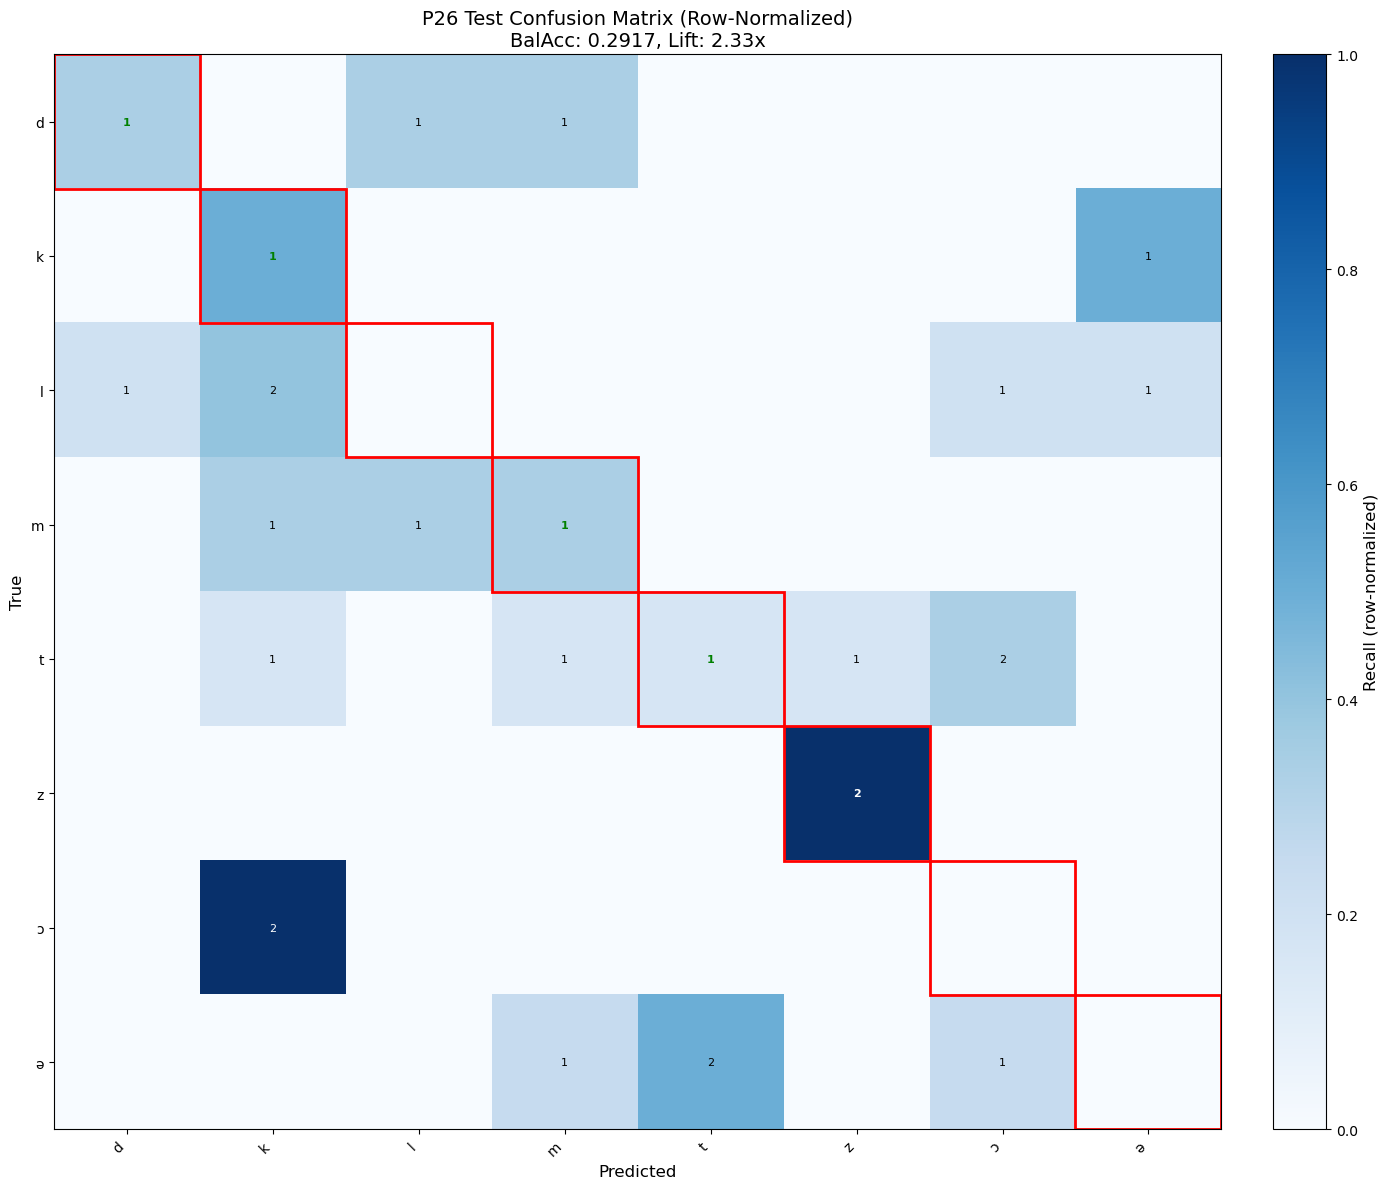


Per-class accuracy (sorted by recall):
----------------------------------------
  z   :  2/2   = 1.00 ********************
  k   :  1/2   = 0.50 **********
  d   :  1/3   = 0.33 ******
  m   :  1/3   = 0.33 ******
  t   :  1/6   = 0.17 ***
  l   :  0/5   = 0.00 
  ɔ   :  0/2   = 0.00 
  ə   :  0/4   = 0.00 

Classes with correct predictions: 5/8
Average per-class recall: 0.2917


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get predictions and labels from test results
y_true = prep.test_results['true_labels']
y_pred = prep.test_results['predictions']

# Get unique classes (sorted for consistent ordering)
classes = sorted(prep.valid_classes)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Normalize by row (true labels) for better visualization
cm_normalized = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-10)

# Plot
fig, ax = plt.subplots(figsize=(14, 12))

# Use imshow for more control
im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Recall (row-normalized)', fontsize=12)

# Set ticks
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, fontsize=10, rotation=45, ha='right')
ax.set_yticklabels(classes, fontsize=10)

# Add text annotations
for i in range(len(classes)):
    for j in range(len(classes)):
        value = cm[i, j]
        if value > 0:
            # Highlight diagonal with different color
            if i == j:
                color = 'white' if cm_normalized[i, j] > 0.5 else 'green'
                weight = 'bold'
            else:
                color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
                weight = 'normal'
            ax.text(j, i, str(value), ha='center', va='center', 
                   color=color, fontsize=8, fontweight=weight)

# Highlight diagonal cells with red border
for i in range(len(classes)):
    rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, 
                          edgecolor='red', linewidth=2)
    ax.add_patch(rect)

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'P26 Test Confusion Matrix (Row-Normalized)\nBalAcc: {prep.test_results["test_acc"]:.4f}, Lift: {prep.test_results["test_lift"]:.2f}x', fontsize=14)

plt.tight_layout()
plt.show()

# Per-class accuracy with sorting by performance
print("\nPer-class accuracy (sorted by recall):")
print("-" * 40)

class_results = []
for i, cls in enumerate(classes):
    total = cm[i, :].sum()
    correct = cm[i, i]
    if total > 0:
        acc = correct / total
        class_results.append((cls, correct, total, acc))

# Sort by accuracy descending
class_results.sort(key=lambda x: x[3], reverse=True)

for cls, correct, total, acc in class_results:
    bar = '*' * int(acc * 20)
    print(f"  {cls:<4}: {correct:>2}/{total:<3} = {acc:.2f} {bar}")

# Summary statistics
correct_classes = sum(1 for _, _, _, acc in class_results if acc > 0)
print(f"\nClasses with correct predictions: {correct_classes}/{len(classes)}")
print(f"Average per-class recall: {np.mean([acc for _, _, _, acc in class_results]):.4f}")

In [35]:
prep.summary()


PREPROCESSOR CONFIGURATION SUMMARY
Patient: P03
Channels: high30_var (30/133)
Baseline: none
Frequency bands: [(30, 70)]
Aggregation: std
Valid classes: 8
Random baseline: 0.1250

Data shapes:
  Train: (121, 30)
  Val: (27, 30)
  Test: (27, 30)

Best classifier: BalancedRF
  Val BalAcc: 0.2202 (1.76x lift)

Final Test Results:
  Test BalAcc: 0.2917 (2.33x lift)


FEATURE QUALITY EVALUATION

--- Basic Stats ---
Total samples: 14149
Unique phonemes: 48
Unique patients: 11
Unique feature shapes: 10
Time frames: min=4, max=4, unique=1
Channels: min=30, max=126, unique=10

--- Per-Patient Classification Test ---

Patient    Samples  Classes  Accuracy  Baseline  Lift
------------------------------------------------------------
P20            146       16  0.136     0.062     2.18x
P21           1137       33  0.121     0.030     4.00x
P22           1385       33  0.133     0.030     4.38x
P23           2060       35  0.134     0.029     4.71x
P24           1327       34  0.137     0.029     4.66x
P25           1172       33  0.132     0.030     4.36x
P26           1068       32  0.126     0.031     4.04x
P27           1327       33  0.127     0.030     4.18x
P28           1224       34  0.121     0.029     4.11x
P29           1517       34  0.133     0.029     4.51x
P30           1495       35  0.130     0.029     4.54x
------------------------------

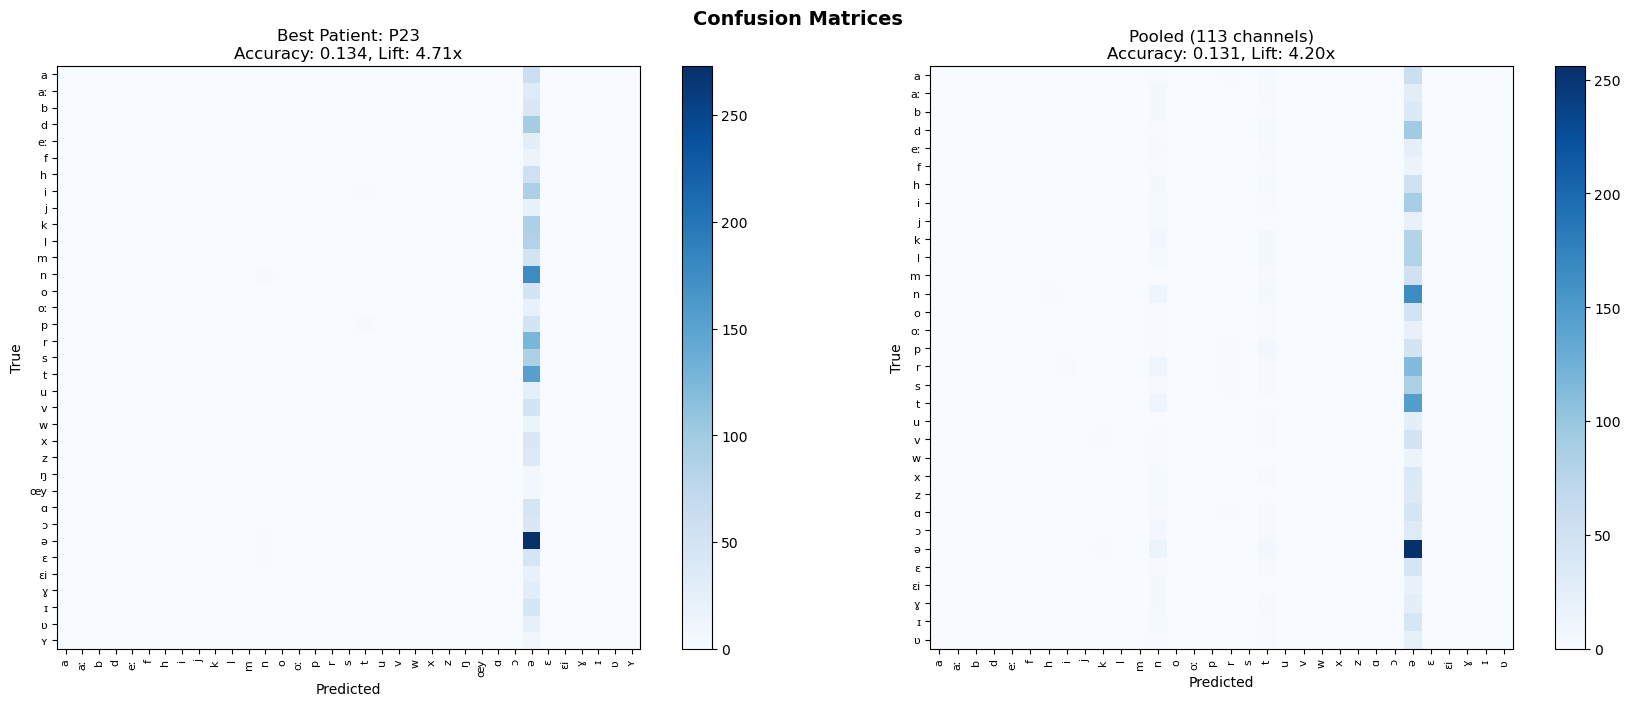

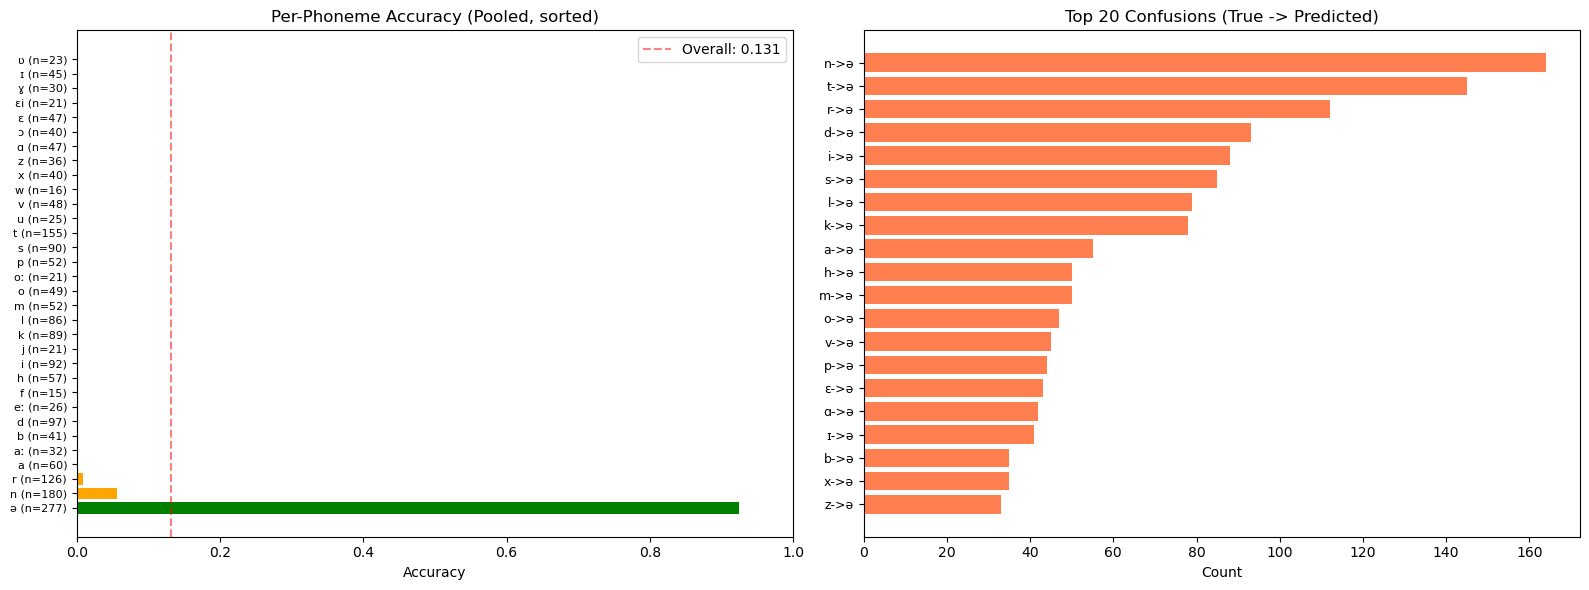


CLASSIFICATION REPORT (Pooled)
              precision    recall  f1-score   support

           a       0.00      0.00      0.00        60
          aː       0.00      0.00      0.00        32
           b       0.00      0.00      0.00        41
           d       0.00      0.00      0.00        97
          eː       0.00      0.00      0.00        26
           f       0.00      0.00      0.00        15
           h       0.00      0.00      0.00        57
           i       0.00      0.00      0.00        92
           j       0.00      0.00      0.00        21
           k       0.00      0.00      0.00        89
           l       0.00      0.00      0.00        86
           m       0.00      0.00      0.00        52
           n       0.09      0.06      0.07       180
           o       0.00      0.00      0.00        49
          oː       0.00      0.00      0.00        21
           p       0.00      0.00      0.00        52
           r       0.20      0.01      0.02      

In [58]:
def evaluate_feature_quality_v2(hg_pipeline, show_confusion=True):
    """
    Feature quality evaluation that handles variable shapes.
    
    Args:
        hg_pipeline: Pipeline with train data
        show_confusion: If True, show confusion matrix for best patient and pooled data
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import confusion_matrix, classification_report
    from collections import Counter
    
    print("="*70)
    print("FEATURE QUALITY EVALUATION")
    print("="*70)
    
    train = hg_pipeline.train
    features = train['features']
    labels = train['phoneme_labels']
    pids = train['phoneme_participant_ids']
    
    print(f"\n--- Basic Stats ---")
    print(f"Total samples: {len(features)}")
    print(f"Unique phonemes: {len(set(labels))}")
    print(f"Unique patients: {len(set(pids))}")
    
    # Check feature shapes
    shapes = [f.shape for f in features]
    unique_shapes = set(shapes)
    print(f"Unique feature shapes: {len(unique_shapes)}")
    
    # Analyze shape variation
    n_frames = [s[0] for s in shapes]
    n_channels = [s[1] for s in shapes]
    
    print(f"Time frames: min={min(n_frames)}, max={max(n_frames)}, unique={len(set(n_frames))}")
    print(f"Channels: min={min(n_channels)}, max={max(n_channels)}, unique={len(set(n_channels))}")
    
    # --- Per-Patient Analysis ---
    # print(f"\n--- Per-Patient Channel Counts ---")
    patient_channels = {}
    for pid, feat in zip(pids, features):
        if pid not in patient_channels:
            patient_channels[pid] = feat.shape[1]
    
    # for pid in sorted(patient_channels.keys())[:10]:
    #     print(f"  {pid}: {patient_channels[pid]} channels")
    # print(f"  ... ({len(patient_channels)} patients total)")
    
    # --- Evaluate per patient (same channel count) ---
    print(f"\n--- Per-Patient Classification Test ---")
    
    patient_results = {}
    patient_predictions = {}  # Store for confusion matrix
    
    for pid in sorted(set(pids)):
        # Get data for this patient
        mask = np.array([p == pid for p in pids])
        X_patient = [features[i] for i in range(len(features)) if mask[i]]
        y_patient = np.array([labels[i] for i in range(len(labels)) if mask[i]])
        
        # Average over time to get (1, n_channels) then flatten
        X_patient = np.vstack([f.mean(axis=0).reshape(1, -1) for f in X_patient])
        
        # Remove unknown labels
        valid = y_patient != '?'
        X_patient = X_patient[valid]
        y_patient = y_patient[valid]
        
        # Filter to classes with enough samples
        label_counts = Counter(y_patient)
        valid_classes = [c for c, count in label_counts.items() if count >= 5]
        
        if len(valid_classes) < 2:
            continue
        
        class_mask = np.isin(y_patient, valid_classes)
        X_filt = X_patient[class_mask]
        y_filt = y_patient[class_mask]
        
        if len(y_filt) < 20:
            continue
        
        # Scale and classify
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_filt)
        
        rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
        
        n_splits = min(5, min(Counter(y_filt).values()))
        if n_splits < 2:
            continue
            
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        
        try:
            scores = cross_val_score(rf, X_scaled, y_filt, cv=cv, scoring='accuracy')
            
            # Get predictions for confusion matrix
            y_pred = cross_val_predict(rf, X_scaled, y_filt, cv=cv)
            
            baseline = 1 / len(valid_classes)
            lift = scores.mean() / baseline
            
            patient_results[pid] = {
                'accuracy': scores.mean(),
                'baseline': baseline,
                'lift': lift,
                'n_samples': len(y_filt),
                'n_classes': len(valid_classes)
            }
            
            patient_predictions[pid] = {
                'y_true': y_filt,
                'y_pred': y_pred,
                'classes': valid_classes
            }
        except:
            continue
    
    # Print results
    print(f"\nPatient    Samples  Classes  Accuracy  Baseline  Lift")
    print("-" * 60)
    
    for pid in sorted(patient_results.keys()):
        r = patient_results[pid]
        print(f"{pid:10} {r['n_samples']:7}  {r['n_classes']:7}  {r['accuracy']:.3f}     {r['baseline']:.3f}     {r['lift']:.2f}x")
    
    # Summary
    if patient_results:
        avg_lift = np.mean([r['lift'] for r in patient_results.values()])
        avg_acc = np.mean([r['accuracy'] for r in patient_results.values()])
        print("-" * 60)
        print(f"{'Average':10} {'-':>7}  {'-':>7}  {avg_acc:.3f}     {'-':>5}     {avg_lift:.2f}x")
    
    # Find best patient
    best_pid = max(patient_results.keys(), key=lambda p: patient_results[p]['lift'])
    print(f"\nBest patient: {best_pid} (lift: {patient_results[best_pid]['lift']:.2f}x)")
    
    # --- Fixed-size feature test ---
    print(f"\n--- Testing with Summary Features (time-averaged) ---")
    
    # Group by channel count
    channel_groups = {}
    for i, (feat, label) in enumerate(zip(features, labels)):
        n_ch = feat.shape[1]
        if n_ch not in channel_groups:
            channel_groups[n_ch] = {'X': [], 'y': []}
        channel_groups[n_ch]['X'].append(feat.mean(axis=0))
        channel_groups[n_ch]['y'].append(label)
    
    print(f"\nChannel groups: {sorted(channel_groups.keys())}")
    
    # Test largest group
    largest_group = max(channel_groups.keys(), key=lambda k: len(channel_groups[k]['y']))
    X_largest = np.vstack(channel_groups[largest_group]['X'])
    y_largest = np.array(channel_groups[largest_group]['y'])
    
    # Filter
    valid = y_largest != '?'
    X_largest = X_largest[valid]
    y_largest = y_largest[valid]
    
    label_counts = Counter(y_largest)
    valid_classes = [c for c, count in label_counts.items() if count >= 10]
    class_mask = np.isin(y_largest, valid_classes)
    X_filt = X_largest[class_mask]
    y_filt = y_largest[class_mask]
    
    print(f"Largest channel group ({largest_group} channels): {len(y_filt)} samples, {len(valid_classes)} classes")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filt)
    
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_scaled, y_filt, cv=cv, scoring='accuracy')
    
    # Get predictions for pooled confusion matrix
    y_pred_pooled = cross_val_predict(rf, X_scaled, y_filt, cv=cv)
    
    baseline = 1 / len(valid_classes)
    
    print(f"5-fold CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"Random baseline: {baseline:.3f}")
    print(f"Lift over baseline: {scores.mean() / baseline:.2f}x")
    
    # --- Confusion Matrices ---
    if show_confusion:
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
        
        # 1. Best patient confusion matrix
        best_data = patient_predictions[best_pid]
        y_true_best = best_data['y_true']
        y_pred_best = best_data['y_pred']
        classes_best = sorted(set(y_true_best) | set(y_pred_best))
        
        cm_best = confusion_matrix(y_true_best, y_pred_best, labels=classes_best)
        
        im1 = axes[0].imshow(cm_best, cmap='Blues')
        axes[0].set_xticks(range(len(classes_best)))
        axes[0].set_yticks(range(len(classes_best)))
        axes[0].set_xticklabels(classes_best, rotation=90, fontsize=8)
        axes[0].set_yticklabels(classes_best, fontsize=8)
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('True')
        axes[0].set_title(f'Best Patient: {best_pid}\nAccuracy: {patient_results[best_pid]["accuracy"]:.3f}, Lift: {patient_results[best_pid]["lift"]:.2f}x')
        plt.colorbar(im1, ax=axes[0])
        
        # 2. Pooled confusion matrix (largest channel group)
        classes_pooled = sorted(set(y_filt) | set(y_pred_pooled))
        cm_pooled = confusion_matrix(y_filt, y_pred_pooled, labels=classes_pooled)
        
        im2 = axes[1].imshow(cm_pooled, cmap='Blues')
        axes[1].set_xticks(range(len(classes_pooled)))
        axes[1].set_yticks(range(len(classes_pooled)))
        axes[1].set_xticklabels(classes_pooled, rotation=90, fontsize=8)
        axes[1].set_yticklabels(classes_pooled, fontsize=8)
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')
        axes[1].set_title(f'Pooled ({largest_group} channels)\nAccuracy: {scores.mean():.3f}, Lift: {scores.mean()/baseline:.2f}x')
        plt.colorbar(im2, ax=axes[1])
        
        plt.tight_layout()
        plt.show()
        
        # Per-phoneme accuracy for pooled data
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Calculate per-phoneme accuracy
        phoneme_acc = {}
        phoneme_counts = Counter(y_filt)
        
        for p in classes_pooled:
            correct = sum(1 for t, pred in zip(y_filt, y_pred_pooled) if t == p and pred == p)
            total = phoneme_counts.get(p, 0)
            phoneme_acc[p] = correct / total if total > 0 else 0
        
        # Sort by accuracy
        sorted_phonemes = sorted(phoneme_acc.keys(), key=lambda x: phoneme_acc[x], reverse=True)
        
        colors = ['green' if phoneme_acc[p] > scores.mean() else 'orange' if phoneme_acc[p] > 0 else 'red' 
                  for p in sorted_phonemes]
        
        axes[0].barh(range(len(sorted_phonemes)), [phoneme_acc[p] for p in sorted_phonemes], color=colors)
        axes[0].set_yticks(range(len(sorted_phonemes)))
        axes[0].set_yticklabels([f"{p} (n={phoneme_counts[p]})" for p in sorted_phonemes], fontsize=8)
        axes[0].set_xlabel('Accuracy')
        axes[0].set_title('Per-Phoneme Accuracy (Pooled, sorted)')
        axes[0].axvline(scores.mean(), color='red', linestyle='--', alpha=0.5, label=f'Overall: {scores.mean():.3f}')
        axes[0].legend()
        axes[0].set_xlim([0, 1])
        
        # Top confusions
        confusion_pairs = []
        for i, true_label in enumerate(classes_pooled):
            for j, pred_label in enumerate(classes_pooled):
                if true_label != pred_label and cm_pooled[i, j] > 0:
                    confusion_pairs.append((true_label, pred_label, cm_pooled[i, j]))
        
        confusion_pairs.sort(key=lambda x: x[2], reverse=True)
        top_confusions = confusion_pairs[:20]
        
        conf_labels = [f"{t}->{p}" for t, p, _ in top_confusions]
        conf_counts = [c for _, _, c in top_confusions]
        
        axes[1].barh(range(len(top_confusions)), conf_counts, color='coral')
        axes[1].set_yticks(range(len(top_confusions)))
        axes[1].set_yticklabels(conf_labels, fontsize=9)
        axes[1].set_xlabel('Count')
        axes[1].set_title('Top 20 Confusions (True -> Predicted)')
        axes[1].invert_yaxis()
        
        plt.tight_layout()
        plt.show()
        
        # Print classification report
        print("\n" + "="*70)
        print("CLASSIFICATION REPORT (Pooled)")
        print("="*70)
        print(classification_report(y_filt, y_pred_pooled, zero_division=0))
    
    return patient_results


# Run evaluation
results = evaluate_feature_quality_v2(high_gamma_pipeline, show_confusion=True)

In [37]:
def test_vowel_consonant(hg_pipeline):
    """Test binary vowel vs consonant classification."""
    
    vowels = {'a', 'e', 'i', 'o', 'u', 'ɑ', 'ɛ', 'ɪ', 'ɔ', 'ʏ', 'ə', 'eː', 'oː', 'aː', 'yː', 'øː', 'iː', 'uː'}
    
    train = hg_pipeline.train
    features = train['features']
    labels = train['phoneme_labels']
    pids = train['phoneme_participant_ids']
    
    # Create binary labels
    binary_labels = []
    for label in labels:
        if label == '?':
            binary_labels.append('?')
        elif label in vowels:
            binary_labels.append('vowel')
        else:
            binary_labels.append('consonant')
    
    binary_labels = np.array(binary_labels)
    
    # Group by channel count
    channel_groups = {}
    for i, (feat, label) in enumerate(zip(features, binary_labels)):
        if label == '?':
            continue
        n_ch = feat.shape[1]
        if n_ch not in channel_groups:
            channel_groups[n_ch] = {'X': [], 'y': []}
        channel_groups[n_ch]['X'].append(feat.mean(axis=0))
        channel_groups[n_ch]['y'].append(label)
    
    # Test largest group
    largest_ch = max(channel_groups.keys(), key=lambda k: len(channel_groups[k]['y']))
    X = np.vstack(channel_groups[largest_ch]['X'])
    y = np.array(channel_groups[largest_ch]['y'])
    
    print(f"Vowel vs Consonant Classification ({largest_ch} channels)")
    print(f"Samples: {len(y)} (vowels: {sum(y=='vowel')}, consonants: {sum(y=='consonant')})")
    
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.preprocessing import StandardScaler
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
    
    print(f"5-fold CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"Random baseline: 0.500")
    print(f"Lift: {scores.mean() / 0.5:.2f}x")


test_vowel_consonant(high_gamma_pipeline)

Vowel vs Consonant Classification (130 channels)
Samples: 1415 (vowels: 546, consonants: 869)
5-fold CV accuracy: 0.611 (+/- 0.008)
Random baseline: 0.500
Lift: 1.22x


In [59]:
def test_segmentation_approaches(pipeline, patient_id='P23', n_test_words=50):
    """
    Test different phoneme segmentation approaches on one patient.
    
    Args:
        pipeline: Pipeline with loaded data (needs split_result and word_segments_dict)
        patient_id: Which patient to test
        n_test_words: Number of words to test per approach
    """
    import numpy as np
    from collections import Counter
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.preprocessing import StandardScaler
    
    print("="*70)
    print(f"TESTING SEGMENTATION APPROACHES - {patient_id}")
    print("="*70)
    
    # Get data for this patient
    split_result = pipeline.split_result
    word_segments_dict = split_result['word_segments_dict']
    detector = pipeline.detector
    config = pipeline.config
    
    if patient_id not in word_segments_dict:
        print(f"Patient {patient_id} not found!")
        return
    
    # Collect word instances for this patient
    instances = []
    for word, indices in split_result['train'].get(patient_id, {}).items():
        for idx in indices:
            instances.append({
                'word': word,
                'idx': idx,
                'data': word_segments_dict[patient_id]['words'][word]['instances'][idx]
            })
    
    if len(instances) < n_test_words:
        n_test_words = len(instances)
    
    print(f"Testing on {n_test_words} word instances from {patient_id}")
    print(f"Total available: {len(instances)} instances")
    
    # Define approaches to test
    approaches = {
        'raw_boundaries': {
            'description': 'Raw boundaries, no extension, no fixed window',
            'extend_short': False,
            'fixed_window': False,
            'drop_invalid': False
        },
        'extend_only': {
            'description': 'Extend short segments, no fixed window',
            'extend_short': True,
            'fixed_window': False,
            'drop_invalid': False
        },
        'fixed_window_only': {
            'description': 'No extension, fixed window (102 samples)',
            'extend_short': False,
            'fixed_window': True,
            'drop_invalid': False
        },
        'extend_and_fixed': {
            'description': 'Extend short + fixed window',
            'extend_short': True,
            'fixed_window': True,
            'drop_invalid': False
        },
        'drop_invalid': {
            'description': 'Drop segments outside [0.025, 0.4]s',
            'extend_short': False,
            'fixed_window': False,
            'drop_invalid': True
        },
        'extend_and_drop': {
            'description': 'Extend short + drop invalid words',
            'extend_short': True,
            'fixed_window': False,
            'drop_invalid': True
        }
    }
    
    results = {}
    
    for approach_name, settings in approaches.items():
        print(f"\n--- Testing: {approach_name} ---")
        print(f"    {settings['description']}")
        
        features = []
        labels = []
        dropped_words = 0
        dropped_phonemes = 0
        total_phonemes = 0
        
        for inst in instances[:n_test_words]:
            word = inst['word']
            word_data = inst['data']
            
            eeg_segment = word_data['eeg_segment']
            spec_segment = word_data['spectrogram_segment']
            audio_segment = word_data.get('audio_segment')
            
            # Get expected phonemes
            expected_phonemes = detector.phonetic_dict.extract_phonemes(word)
            if not expected_phonemes:
                continue
            
            total_phonemes += len(expected_phonemes)
            
            # Detect boundaries
            result = detector.detect_boundaries(
                spectrogram=spec_segment,
                word=word,
                participant_id=patient_id,
                word_position=0,
                use_multifeature=detector.use_multifeature,
                use_rms_boundaries=detector.use_rms_boundaries,
                audio_segment=audio_segment,
                audio_sr=config.audio_sr
            )
            
            boundary_samples = result.get('boundary_samples', [])
            segments = result.get('segments', [])
            
            # Check for segment/phoneme mismatch
            if len(segments) != len(expected_phonemes):
                dropped_words += 1
                dropped_phonemes += len(expected_phonemes)
                continue
            
            # Apply approach-specific processing
            min_samples = config.min_eeg_samples_for_features
            min_duration = config.min_phoneme_duration
            max_duration = config.max_phoneme_duration
            
            # Get segment boundaries
            if settings['extend_short']:
                seg_bounds = detector._extend_short_segments(
                    boundary_samples, 
                    eeg_segment.shape[0], 
                    min_samples
                )
            else:
                seg_bounds = [(boundary_samples[i], boundary_samples[i+1]) 
                              for i in range(len(boundary_samples)-1)]
            
            # Check durations if dropping invalid
            if settings['drop_invalid']:
                durations = [(end - start) / config.eeg_sr for start, end in seg_bounds]
                has_invalid = any(d < min_duration or d > max_duration for d in durations)
                if has_invalid:
                    dropped_words += 1
                    dropped_phonemes += len(expected_phonemes)
                    continue
            
            # Extract features for each phoneme
            word_valid = True
            word_features = []
            word_labels = []
            
            for j, (phoneme, (start, end)) in enumerate(zip(expected_phonemes, seg_bounds)):
                start = int(max(0, start))
                end = int(min(eeg_segment.shape[0], end))
                
                if start >= end:
                    word_valid = False
                    break
                
                raw_seg = eeg_segment[start:end]
                
                # Apply fixed window if requested
                if settings['fixed_window']:
                    target_samples = config.fixed_feature_samples
                    n_samples = raw_seg.shape[0]
                    
                    if n_samples > target_samples:
                        # Truncate from center
                        trim_start = (n_samples - target_samples) // 2
                        raw_seg = raw_seg[trim_start:trim_start + target_samples]
                    elif n_samples < target_samples:
                        # Pad with edge values
                        pad_total = target_samples - n_samples
                        pad_before = pad_total // 2
                        pad_after = pad_total - pad_before
                        raw_seg = np.pad(raw_seg, ((pad_before, pad_after), (0, 0)), mode='edge')
                
                # Check minimum samples for feature extraction
                if raw_seg.shape[0] < min_samples:
                    word_valid = False
                    break
                
                # Extract high gamma features
                try:
                    from extract_features import extractHG
                    feat = extractHG(raw_seg, config.eeg_sr)
                    
                    if feat.shape[0] == 0:
                        word_valid = False
                        break
                    
                    # Average over time
                    feat_avg = feat.mean(axis=0)
                    word_features.append(feat_avg)
                    word_labels.append(phoneme)
                    
                except Exception as e:
                    word_valid = False
                    break
            
            if word_valid and len(word_features) == len(expected_phonemes):
                features.extend(word_features)
                labels.extend(word_labels)
            else:
                dropped_words += 1
                dropped_phonemes += len(expected_phonemes)
        
        # Evaluate
        print(f"    Samples extracted: {len(features)}")
        print(f"    Words dropped: {dropped_words}")
        print(f"    Phonemes dropped: {dropped_phonemes}/{total_phonemes} ({100*dropped_phonemes/total_phonemes:.1f}%)")
        
        if len(features) < 20:
            print(f"    NOT ENOUGH DATA FOR CLASSIFICATION")
            results[approach_name] = {
                'accuracy': 0,
                'lift': 0,
                'n_samples': len(features),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1
            }
            continue
        
        # Prepare for classification
        X = np.array(features)
        y = np.array(labels)
        
        # Filter to classes with enough samples
        label_counts = Counter(y)
        valid_classes = [c for c, count in label_counts.items() if count >= 3]
        
        if len(valid_classes) < 2:
            print(f"    NOT ENOUGH CLASSES")
            results[approach_name] = {
                'accuracy': 0,
                'lift': 0,
                'n_samples': len(features),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1
            }
            continue
        
        mask = np.isin(y, valid_classes)
        X_filt = X[mask]
        y_filt = y[mask]
        
        # Scale and classify
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_filt)
        
        rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        
        n_splits = min(3, min(Counter(y_filt).values()))
        if n_splits < 2:
            n_splits = 2
        
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        
        try:
            scores = cross_val_score(rf, X_scaled, y_filt, cv=cv, scoring='accuracy')
            baseline = 1 / len(valid_classes)
            lift = scores.mean() / baseline
            
            print(f"    Classes: {len(valid_classes)}")
            print(f"    Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
            print(f"    Baseline: {baseline:.3f}")
            print(f"    Lift: {lift:.2f}x")
            
            results[approach_name] = {
                'accuracy': scores.mean(),
                'lift': lift,
                'n_samples': len(X_filt),
                'n_classes': len(valid_classes),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1,
                'baseline': baseline
            }
        except Exception as e:
            print(f"    Classification failed: {e}")
            results[approach_name] = {
                'accuracy': 0,
                'lift': 0,
                'n_samples': len(features),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1
            }
    
    # Summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"\n{'Approach':<20} {'Samples':<10} {'Drop%':<10} {'Classes':<10} {'Accuracy':<10} {'Lift':<10}")
    print("-"*70)
    
    for name, r in sorted(results.items(), key=lambda x: x[1].get('lift', 0), reverse=True):
        print(f"{name:<20} {r.get('n_samples', 0):<10} {r.get('drop_rate', 0)*100:<10.1f} "
              f"{r.get('n_classes', 0):<10} {r.get('accuracy', 0):<10.3f} {r.get('lift', 0):<10.2f}x")
    
    # Best approach
    best = max(results.items(), key=lambda x: x[1].get('lift', 0))
    print(f"\nBEST APPROACH: {best[0]} (lift: {best[1].get('lift', 0):.2f}x)")
    
    return results


# Run the test
results = test_segmentation_approaches(
    high_gamma_pipeline, 
    patient_id='P23',  # Best performing patient
    n_test_words=100
)

TESTING SEGMENTATION APPROACHES - P23
Testing on 100 word instances from P23
Total available: 500 instances

--- Testing: raw_boundaries ---
    Raw boundaries, no extension, no fixed window
AcousticChangeDetector:   Need 5 peaks but only found 3 for word 'huidige' (Patient P23)
AcousticChangeDetector:   Need 3 peaks but only found 2 for word 'staat' (Patient P23)
AcousticChangeDetector:   Need 4 peaks but only found 3 for word 'Zalig' (Patient P23)
    Samples extracted: 44
    Words dropped: 79
    Phonemes dropped: 235/279 (84.2%)
    Classes: 5
    Accuracy: 0.481 (+/- 0.026)
    Baseline: 0.200
    Lift: 2.41x

--- Testing: extend_only ---
    Extend short segments, no fixed window
AcousticChangeDetector:   Need 5 peaks but only found 3 for word 'huidige' (Patient P23)
AcousticChangeDetector:   Need 3 peaks but only found 2 for word 'staat' (Patient P23)
AcousticChangeDetector:   Need 4 peaks but only found 3 for word 'Zalig' (Patient P23)
    Samples extracted: 44
    Words dropp

In [24]:
def visualize_pipeline_features(pipeline, patient_id=None, save_path=None):
    """
    Visualize features already extracted by the pipeline.
    
    Includes:
    - Basic feature distributions
    - Transient/kurtosis features (computed from pipeline features)
    - Feature separability analysis
    - Phoneme heatmaps
    - Learning curves (overall and feature-specific)
    - Dendrograms
    
    Args:
        pipeline: Dutch30Pipeline with train/test data already extracted
        patient_id: Optional - filter to specific patient, or None for all
        save_path: Directory to save figures
    
    Returns:
        dict: Analysis results
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import mannwhitneyu, kurtosis, skew
    from scipy.signal import hilbert
    from sklearn.model_selection import learning_curve, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
    from scipy.spatial.distance import pdist
    from collections import defaultdict
    import os
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    # Check pipeline has data
    if not hasattr(pipeline, 'train') or pipeline.train is None:
        raise ValueError("Pipeline has no training data. Run steps 1-6 first.")
    
    train_data = pipeline.train
    
    # Get data from pipeline
    features_list = train_data['features']
    labels = train_data['phoneme_labels']
    words = train_data['phoneme_words']
    participant_ids = train_data['phoneme_participant_ids']
    
    # Filter by patient if specified
    if patient_id is not None:
        indices = [i for i, pid in enumerate(participant_ids) if pid == patient_id]
        if not indices:
            print(f"No data found for patient {patient_id}")
            return None
        features_list = [features_list[i] for i in indices]
        labels = [labels[i] for i in indices]
        words = [words[i] for i in indices]
        participant_ids = [participant_ids[i] for i in indices]
        print(f"Filtered to {len(indices)} samples for {patient_id}")
    
    print(f"Total samples: {len(features_list)}")
    print(f"Unique phonemes: {len(set(labels))}")
    print(f"Unique patients: {len(set(participant_ids))}")
    
    # Define vowels
    vowels = getattr(pipeline.config, 'vowels', None)
    if vowels is None:
        vowels = {
            # Short monophthongs
            'a', 'ɑ', 'ɛ', 'ɪ', 'i', 'ɔ', 'o', 'u', 'ʏ', 'y', 'ə', 'e', 'ø',
            
            # Long vowels (IPA length marker)
            'aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː', 'ɑː', 'ɔː', 'ɛː', 'ɵː',
            
            # Long vowels (colon notation - in case your data uses this)
            'a:', 'e:', 'i:', 'o:', 'u:', 'y:', 'ø:', 'ɑ:', 'ɔ:', 'ɛ:', 'ɵ:',
            
            # Diphthongs
            'ɛi', 'œy', 'ɑu', 'ʌu',
        }
    
    # ========================================================================
    # FEATURE EXTRACTION FROM PIPELINE DATA
    # ========================================================================
    
    def extract_summary_features(feat):
        """
        Extract summary statistics from pipeline feature matrix.
        
        Args:
            feat: numpy array - can be (n_frames, n_channels) or (1, n_features)
        
        Returns:
            dict: Summary features including transient-like measures
        """
        if feat is None or feat.size == 0:
            return None
        
        # Handle different input shapes
        if feat.ndim == 1:
            feat = feat.reshape(1, -1)
        
        n_frames, n_features = feat.shape
        
        summary = {}
        
        # If single frame (1, n_features), treat n_features as the signal
        if n_frames == 1:
            signal = feat.flatten()
            
            # Basic statistics
            summary['mean'] = np.mean(signal)
            summary['std'] = np.std(signal)
            summary['max'] = np.max(signal)
            summary['min'] = np.min(signal)
            summary['range'] = summary['max'] - summary['min']
            
            # Energy features
            summary['total_energy'] = np.sum(signal ** 2)
            summary['mean_energy'] = np.mean(signal ** 2)
            
            # Distribution across features/channels
            summary['channel_variance'] = np.var(signal)
            summary['channel_range'] = summary['range']
            
            # Temporal features (not applicable for single frame)
            summary['temporal_mean'] = summary['mean']
            summary['temporal_std'] = 0
            summary['temporal_range'] = 0
            summary['temporal_variance'] = 0
            
            # Duration
            summary['n_frames'] = n_frames
            summary['n_channels'] = n_features
            
            # Transient features from the feature vector
            if len(signal) > 3:
                kurt_val = kurtosis(signal, nan_policy='omit')
                summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
                
                skew_val = skew(signal, nan_policy='omit')
                summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
            else:
                summary['kurtosis'] = 0
                summary['skewness'] = 0
            
            # Spatial kurtosis (across channels/features)
            summary['channel_kurtosis'] = summary['kurtosis']
            summary['temporal_kurtosis'] = 0
            
            # Peak-to-RMS
            rms = np.sqrt(np.mean(signal ** 2))
            summary['peak_to_rms'] = np.max(np.abs(signal)) / (rms + 1e-10)
            summary['crest_factor'] = np.max(np.abs(signal)) / (np.std(signal) + 1e-10)
            
            # Envelope features (use signal directly)
            summary['envelope_kurtosis'] = summary['kurtosis']
            summary['envelope_skewness'] = summary['skewness']
            summary['envelope_std'] = summary['std']
            
            # Windowed kurtosis (split signal into windows)
            if len(signal) >= 20:
                n_windows = 5
                window_size = len(signal) // n_windows
                window_kurtosis = []
                
                for i in range(n_windows):
                    window = signal[i * window_size:(i + 1) * window_size]
                    if len(window) > 3:
                        wk = kurtosis(window, nan_policy='omit')
                        if np.isfinite(wk):
                            window_kurtosis.append(wk)
                
                if window_kurtosis:
                    summary['kurtosis_windowed_mean'] = np.mean(window_kurtosis)
                    summary['kurtosis_windowed_max'] = np.max(window_kurtosis)
                    summary['kurtosis_windowed_std'] = np.std(window_kurtosis) if len(window_kurtosis) > 1 else 0
                else:
                    summary['kurtosis_windowed_mean'] = 0
                    summary['kurtosis_windowed_max'] = 0
                    summary['kurtosis_windowed_std'] = 0
            else:
                summary['kurtosis_windowed_mean'] = 0
                summary['kurtosis_windowed_max'] = 0
                summary['kurtosis_windowed_std'] = 0
            
            # Line length and zero crossing (across feature vector)
            summary['line_length'] = np.sum(np.abs(np.diff(signal))) / (len(signal) + 1e-10)
            centered = signal - np.mean(signal)
            summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
            
        else:
            # Original logic for (n_frames, n_channels) data
            flat = feat.flatten()
            
            # Basic statistics
            summary['mean'] = np.mean(feat)
            summary['std'] = np.std(feat)
            summary['max'] = np.max(feat)
            summary['min'] = np.min(feat)
            summary['range'] = summary['max'] - summary['min']
            
            # Temporal features (across frames)
            frame_means = np.mean(feat, axis=1)
            summary['temporal_mean'] = np.mean(frame_means)
            summary['temporal_std'] = np.std(frame_means)
            summary['temporal_range'] = np.max(frame_means) - np.min(frame_means)
            
            # Channel features (across channels)
            channel_means = np.mean(feat, axis=0)
            summary['channel_variance'] = np.var(channel_means)
            summary['channel_range'] = np.max(channel_means) - np.min(channel_means)
            
            # Energy features
            summary['total_energy'] = np.sum(feat ** 2)
            summary['mean_energy'] = np.mean(feat ** 2)
            
            # Temporal variance
            summary['temporal_variance'] = np.mean(np.var(feat, axis=0))
            
            # Duration
            summary['n_frames'] = n_frames
            summary['n_channels'] = n_features
            
            # Kurtosis features
            if len(flat) > 3:
                kurt_val = kurtosis(flat, nan_policy='omit')
                summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
                
                skew_val = skew(flat, nan_policy='omit')
                summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
            else:
                summary['kurtosis'] = 0
                summary['skewness'] = 0
            
            # Temporal kurtosis
            if len(frame_means) > 3:
                temp_kurt = kurtosis(frame_means, nan_policy='omit')
                summary['temporal_kurtosis'] = temp_kurt if np.isfinite(temp_kurt) else 0
            else:
                summary['temporal_kurtosis'] = 0
            
            # Channel kurtosis
            if len(channel_means) > 3:
                chan_kurt = kurtosis(channel_means, nan_policy='omit')
                summary['channel_kurtosis'] = chan_kurt if np.isfinite(chan_kurt) else 0
            else:
                summary['channel_kurtosis'] = 0
            
            # Peak-to-RMS
            rms = np.sqrt(np.mean(feat ** 2))
            summary['peak_to_rms'] = np.max(np.abs(feat)) / (rms + 1e-10)
            summary['crest_factor'] = np.max(np.abs(feat)) / (np.std(feat) + 1e-10)
            
            # Envelope features
            if len(frame_means) > 3:
                env_kurt = kurtosis(frame_means, nan_policy='omit')
                summary['envelope_kurtosis'] = env_kurt if np.isfinite(env_kurt) else 0
                
                env_skew = skew(frame_means, nan_policy='omit')
                summary['envelope_skewness'] = env_skew if np.isfinite(env_skew) else 0
            else:
                summary['envelope_kurtosis'] = 0
                summary['envelope_skewness'] = 0
            
            summary['envelope_std'] = np.std(frame_means)
            
            # Windowed kurtosis
            if n_frames >= 6:
                n_windows = min(5, n_frames // 2)
                window_size = n_frames // n_windows
                window_kurtosis = []
                
                for i in range(n_windows):
                    window = feat[i * window_size:(i + 1) * window_size, :].flatten()
                    if len(window) > 3:
                        wk = kurtosis(window, nan_policy='omit')
                        if np.isfinite(wk):
                            window_kurtosis.append(wk)
                
                if window_kurtosis:
                    summary['kurtosis_windowed_mean'] = np.mean(window_kurtosis)
                    summary['kurtosis_windowed_max'] = np.max(window_kurtosis)
                    summary['kurtosis_windowed_std'] = np.std(window_kurtosis) if len(window_kurtosis) > 1 else 0
                else:
                    summary['kurtosis_windowed_mean'] = 0
                    summary['kurtosis_windowed_max'] = 0
                    summary['kurtosis_windowed_std'] = 0
            else:
                summary['kurtosis_windowed_mean'] = 0
                summary['kurtosis_windowed_max'] = 0
                summary['kurtosis_windowed_std'] = 0
            
            # Line length and zero crossing
            summary['line_length'] = np.sum(np.abs(np.diff(frame_means))) / (len(frame_means) + 1e-10)
            centered = frame_means - np.mean(frame_means)
            summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
        
        return summary
        # ========================================================================
        # EXTRACT FEATURES FROM ALL SAMPLES
        # ========================================================================
        
    print("Extracting summary features from pipeline data...")
    summaries = []
    valid_indices = []
        
    for i, feat in enumerate(features_list):
        s = extract_summary_features(feat)
        if s is not None:
            summaries.append(s)
            valid_indices.append(i)
        
    # Filter labels to valid indices
    labels = [labels[i] for i in valid_indices]
    words = [words[i] for i in valid_indices]
    participant_ids = [participant_ids[i] for i in valid_indices]
        
    print(f"Valid samples after filtering: {len(summaries)}")
        
    if len(summaries) == 0:
        print("No valid samples found!")
        return None
        
    # Get feature names from first summary
    feature_names = list(summaries[0].keys())
    print(f"Extracted {len(feature_names)} features: {feature_names[:5]}...")
        
    # Create feature matrix
    X = np.array([[s[fn] for fn in feature_names] for s in summaries])
        
    # Create binary labels (vowel vs consonant)
    is_vowel = [1 if label in vowels else 0 for label in labels]
    y = np.array(is_vowel)
        
    # Handle NaN/Inf
    X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
        
    n_vowels = sum(y)
    n_consonants = len(y) - n_vowels
    print(f"Vowels: {n_vowels}, Consonants: {n_consonants}")
        
    baseline = max(n_vowels, n_consonants) / len(y)
    print(f"Baseline accuracy: {baseline:.2f}")
        
    # ========================================================================
    # HELPER FUNCTIONS
    # ========================================================================
    
    def cohens_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        if n1 < 2 or n2 < 2:
            return 0
        var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return abs(np.mean(g1) - np.mean(g2)) / (pooled_std + 1e-10)
    
    def sig_str(p):
        if p < 0.001: return "***"
        if p < 0.01: return "**"
        if p < 0.05: return "*"
        return "ns"
    
        
    # Compute statistics for each feature
    comparison_results = {}
    for i, feat_name in enumerate(feature_names):
        vowel_vals = X[y == 1, i]
        cons_vals = X[y == 0, i]
        
        if len(vowel_vals) > 1 and len(cons_vals) > 1:
            try:
                _, pval = mannwhitneyu(vowel_vals, cons_vals, alternative='two-sided')
            except:
                pval = 1.0
            d = cohens_d(vowel_vals, cons_vals)
            comparison_results[feat_name] = {
                'pval': pval,
                'd': d,
                'vowel_mean': np.mean(vowel_vals),
                'cons_mean': np.mean(cons_vals),
                'vowel_vals': vowel_vals,
                'cons_vals': cons_vals
            }
    
    # Title suffix for patient
    title_patient = f" - {patient_id}" if patient_id else " - All Patients"
    
    # Define feature groups
    standard_features = ['mean', 'std', 'total_energy', 'mean_energy', 
                         'temporal_variance', 'channel_variance', 'n_frames', 'range']
    standard_features = [f for f in standard_features if f in feature_names]
    
    transient_features = ['kurtosis', 'temporal_kurtosis', 'channel_kurtosis',
                          'envelope_kurtosis', 'kurtosis_windowed_max', 'kurtosis_windowed_mean',
                          'peak_to_rms', 'crest_factor', 'skewness', 'envelope_skewness',
                          'line_length', 'zero_crossing']
    transient_features = [f for f in transient_features if f in feature_names]
    
    # ========================================================================
    # FIGURE 1: Standard Feature Distributions
    # ========================================================================
    
    n_std = len(standard_features)
    n_cols = 4
    n_rows = max(1, (n_std + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Standard Features: Vowel vs Consonant{title_patient}\n'
                 f'Method: {pipeline.feature_extraction_method} | '
                 f'Green = d>0.5 (good), Red = d<0.2 (poor)',
                 fontsize=12, fontweight='bold')
    
    for idx, feat_name in enumerate(standard_features):
        ax = axes[idx // n_cols, idx % n_cols]
        
        if feat_name not in comparison_results:
            ax.text(0.5, 0.5, f'{feat_name}\nNo data', ha='center', va='center', 
                    transform=ax.transAxes)
            continue
        
        res = comparison_results[feat_name]
        vowel_vals = res['vowel_vals']
        cons_vals = res['cons_vals']
        d = res['d']
        pval = res['pval']
        
        all_vals = np.concatenate([vowel_vals, cons_vals])
        bins = np.linspace(np.percentile(all_vals, 2), np.percentile(all_vals, 98), 30)
        
        ax.hist(vowel_vals, bins=bins, alpha=0.5, color='coral', density=True, 
                label='Vowels', edgecolor='darkred')
        ax.hist(cons_vals, bins=bins, alpha=0.5, color='steelblue', density=True, 
                label='Consonants', edgecolor='darkblue')
        
        ax.axvline(np.mean(vowel_vals), color='darkred', linestyle='--', linewidth=2)
        ax.axvline(np.mean(cons_vals), color='darkblue', linestyle='--', linewidth=2)
        
        if d > 0.5:
            ax.set_facecolor('#e8f5e9')
        elif d < 0.2:
            ax.set_facecolor('#ffebee')
        
        ax.set_title(f"{feat_name}\nd={d:.2f} ({sig_str(pval)})", fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        
        if idx == 0:
            ax.legend(fontsize=8)
    
    for idx in range(len(standard_features), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"1_standard_distributions.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 1_standard_distributions.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 2: Transient/Kurtosis Feature Distributions
    # ========================================================================
    
    n_trans = len(transient_features)
    n_cols = 4
    n_rows = max(1, (n_trans + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Transient/Kurtosis Features: Vowel vs Consonant{title_patient}\n'
                 f'These features capture burst/transient activity patterns',
                 fontsize=12, fontweight='bold')
    
    for idx, feat_name in enumerate(transient_features):
        ax = axes[idx // n_cols, idx % n_cols]
        
        if feat_name not in comparison_results:
            ax.text(0.5, 0.5, f'{feat_name}\nNo data', ha='center', va='center', 
                    transform=ax.transAxes)
            continue
        
        res = comparison_results[feat_name]
        vowel_vals = res['vowel_vals']
        cons_vals = res['cons_vals']
        d = res['d']
        pval = res['pval']
        
        all_vals = np.concatenate([vowel_vals, cons_vals])
        bins = np.linspace(np.percentile(all_vals, 2), np.percentile(all_vals, 98), 30)
        
        ax.hist(vowel_vals, bins=bins, alpha=0.5, color='coral', density=True, 
                label='Vowels', edgecolor='darkred')
        ax.hist(cons_vals, bins=bins, alpha=0.5, color='steelblue', density=True, 
                label='Consonants', edgecolor='darkblue')
        
        ax.axvline(np.mean(vowel_vals), color='darkred', linestyle='--', linewidth=2)
        ax.axvline(np.mean(cons_vals), color='darkblue', linestyle='--', linewidth=2)
        
        if d > 0.5:
            ax.set_facecolor('#e8f5e9')
        elif d < 0.2:
            ax.set_facecolor('#ffebee')
        
        ax.set_title(f"{feat_name}\nd={d:.2f} ({sig_str(pval)})", fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        
        if idx == 0:
            ax.legend(fontsize=8)
    
    for idx in range(len(transient_features), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"2_transient_distributions.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 2_transient_distributions.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 3: Feature Separability Ranking
    # ========================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Feature Separability Analysis{title_patient}\n"
                 f"Cohen's d: <0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large",
                 fontsize=13, fontweight='bold')
    
    sorted_features = sorted(comparison_results.keys(), 
                             key=lambda f: comparison_results[f]['d'], 
                             reverse=True)
    
    # Top left: All features ranked
    ax = axes[0, 0]
    top_n = min(20, len(sorted_features))
    x = np.arange(top_n)
    d_vals = [comparison_results[f]['d'] for f in sorted_features[:top_n]]
    colors = ['green' if d > 0.5 else 'orange' if d > 0.2 else 'red' for d in d_vals]
    
    ax.barh(x, d_vals, color=colors, alpha=0.7)
    ax.set_yticks(x)
    ax.set_yticklabels(sorted_features[:top_n], fontsize=9)
    ax.set_xlabel("Cohen's d")
    ax.set_title(f"Top {top_n} Features by Effect Size")
    ax.axvline(0.2, color='gray', linestyle=':', label='Small (0.2)')
    ax.axvline(0.5, color='gray', linestyle='--', label='Medium (0.5)')
    ax.axvline(0.8, color='gray', linestyle='-', label='Large (0.8)')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Top right: Transient features only
    ax = axes[0, 1]
    transient_in_results = [f for f in transient_features if f in comparison_results]
    
    if transient_in_results:
        x_trans = np.arange(len(transient_in_results))
        d_trans = [comparison_results[f]['d'] for f in transient_in_results]
        colors_trans = ['green' if d > 0.5 else 'orange' if d > 0.2 else 'red' for d in d_trans]
        
        ax.barh(x_trans, d_trans, color=colors_trans, alpha=0.7)
        ax.set_yticks(x_trans)
        ax.set_yticklabels(transient_in_results, fontsize=9)
        ax.set_xlabel("Cohen's d")
        ax.set_title("Transient/Kurtosis Features Only")
        ax.axvline(0.2, color='gray', linestyle=':')
        ax.axvline(0.5, color='gray', linestyle='--')
        ax.grid(True, alpha=0.3, axis='x')
    else:
        ax.text(0.5, 0.5, 'No transient features', ha='center', va='center', 
                transform=ax.transAxes)
    
    # Bottom left: Standard vs Transient comparison
    ax = axes[1, 0]
    
    std_d = [comparison_results[f]['d'] for f in standard_features if f in comparison_results]
    trans_d = [comparison_results[f]['d'] for f in transient_features if f in comparison_results]
    
    bp = ax.boxplot([std_d, trans_d], labels=['Standard', 'Transient'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    
    ax.axhline(0.2, color='gray', linestyle=':', alpha=0.7)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
    ax.set_ylabel("Cohen's d")
    ax.set_title("Standard vs Transient Features")
    ax.grid(True, alpha=0.3, axis='y')
    
    # Bottom right: Summary text
    ax = axes[1, 1]
    
    summary_text = f"SUMMARY\n{'='*40}\n\n"
    summary_text += f"Samples: {len(y)} ({n_vowels} V, {n_consonants} C)\n"
    summary_text += f"Baseline: {baseline:.2f}\n\n"
    
    summary_text += "TOP 5 OVERALL:\n"
    for i, f in enumerate(sorted_features[:5]):
        d = comparison_results[f]['d']
        summary_text += f"  {i+1}. {f}: d={d:.3f}\n"
    
    summary_text += "\nTOP 5 TRANSIENT:\n"
    trans_sorted = sorted(transient_in_results, key=lambda f: comparison_results[f]['d'], reverse=True)
    for i, f in enumerate(trans_sorted[:5]):
        d = comparison_results[f]['d']
        summary_text += f"  {i+1}. {f}: d={d:.3f}\n"
    
    ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"3_separability.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 3_separability.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 4: Phoneme Heatmap
    # ========================================================================
    
    all_phonemes = sorted(set(labels), key=lambda p: (p not in vowels, p))
    n_phonemes = len(all_phonemes)
    
    # Select features for heatmap (mix of standard and transient)
    heatmap_features = ['mean_energy', 'temporal_variance', 'kurtosis', 
                        'temporal_kurtosis', 'peak_to_rms', 'zero_crossing',
                        'envelope_kurtosis', 'n_frames']
    heatmap_features = [f for f in heatmap_features if f in feature_names]
    
    if not heatmap_features:
        heatmap_features = feature_names[:8]
    
    # Build phoneme feature matrix
    phoneme_features = defaultdict(lambda: defaultdict(list))
    for i, label in enumerate(labels):
        for j, feat_name in enumerate(feature_names):
            phoneme_features[label][feat_name].append(X[i, j])
    
    matrix = np.zeros((n_phonemes, len(heatmap_features)))
    for i, phoneme in enumerate(all_phonemes):
        for j, feat_name in enumerate(heatmap_features):
            vals = phoneme_features[phoneme][feat_name]
            matrix[i, j] = np.mean(vals) if vals else 0
    
    # Z-score normalize columns
    for j in range(matrix.shape[1]):
        if np.std(matrix[:, j]) > 0:
            matrix[:, j] = (matrix[:, j] - np.mean(matrix[:, j])) / np.std(matrix[:, j])
    
    fig_height = max(8, n_phonemes * 0.35)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    
    fig.suptitle(f"Phoneme Feature Heatmap ({n_phonemes} phonemes){title_patient}\n"
                 f"V = vowel | Red = high, Blue = low (z-scored)",
                 fontsize=12, fontweight='bold')
    
    im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    
    ax.set_xticks(range(len(heatmap_features)))
    ax.set_xticklabels(heatmap_features, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(n_phonemes))
    
    fontsize = 10 if n_phonemes <= 20 else 8 if n_phonemes <= 40 else 6
    ax.set_yticklabels(all_phonemes, fontsize=fontsize)
    
    for i, p in enumerate(all_phonemes):
        if p in vowels:
            ax.text(-0.7, i, 'V', ha='center', va='center', fontsize=fontsize, 
                    color='coral', fontweight='bold')
    
    plt.colorbar(im, label='Z-score', shrink=0.8)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"4_phoneme_heatmap.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 4_phoneme_heatmap.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 5: Learning Curves - All Features
    # ========================================================================
    
    if len(y) >= 30:
        print("\nComputing learning curves...")
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        n_samples = len(y)
        min_train = max(10, int(n_samples * 0.1))
        max_train = int(n_samples * 0.8)
        train_sizes = np.linspace(min_train, max_train, 8).astype(int)
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        
        train_sizes_out, train_scores, test_scores = learning_curve(
            clf, X_scaled, y, train_sizes=train_sizes, cv=cv,
            scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42
        )
        
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        train_mean = np.mean(train_scores, axis=1)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Learning Curves - All {len(feature_names)} Features{title_patient}", 
                     fontsize=13, fontweight='bold')
        
        ax = axes[0]
        ax.fill_between(train_sizes_out, test_mean - test_std, test_mean + test_std, 
                        alpha=0.2, color='steelblue')
        ax.plot(train_sizes_out, test_mean, 'o-', color='steelblue', linewidth=2, 
                label='Test accuracy')
        ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5, 
                   label=f'Baseline ({baseline:.2f})')
        ax.set_xlabel('Training Samples')
        ax.set_ylabel('Accuracy')
        ax.set_title('Test Accuracy vs Training Size')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        ax = axes[1]
        ax.plot(train_sizes_out, train_mean, 'o--', color='coral', 
                linewidth=1.5, label='Train')
        ax.plot(train_sizes_out, test_mean, 'o-', color='steelblue', 
                linewidth=2, label='Test')
        ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
        ax.set_xlabel('Training Samples')
        ax.set_ylabel('Accuracy')
        ax.set_title('Train vs Test (gap = overfitting)')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"5_learning_curves_all.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 5_learning_curves_all.png")
        
        plt.show()
        
        # ====================================================================
        # FIGURE 6: Feature-Specific Learning Curves (Kurtosis/Transient Focus)
        # ====================================================================
        
        print("\nComputing feature-specific learning curves...")
        
        # Select key features for individual analysis
        key_features = ['kurtosis', 'temporal_kurtosis', 'envelope_kurtosis',
                        'peak_to_rms', 'mean_energy', 'zero_crossing']
        key_features = [f for f in key_features if f in feature_names][:6]
        
        if key_features:
            n_key = len(key_features)
            n_cols = 3
            n_rows = (n_key + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
            axes = axes.flatten() if n_rows > 1 else axes
            if n_rows == 1 and n_cols > 1:
                axes = list(axes)
            
            fig.suptitle(f'Feature-Specific Learning Curves{title_patient}\n'
                         f'Focus on transient/kurtosis features',
                         fontsize=13, fontweight='bold')
            
            for idx, feat_name in enumerate(key_features):
                ax = axes[idx] if isinstance(axes, (list, np.ndarray)) else axes
                
                feat_idx = feature_names.index(feat_name)
                X_single = X_scaled[:, feat_idx:feat_idx+1]
                
                try:
                    _, _, test_single = learning_curve(
                        LogisticRegression(max_iter=500, random_state=42),
                        X_single, y, train_sizes=train_sizes, cv=cv,
                        scoring='accuracy', n_jobs=-1
                    )
                    
                    test_mean_single = np.mean(test_single, axis=1)
                    test_std_single = np.std(test_single, axis=1)
                    
                    ax.fill_between(train_sizes_out, 
                                    test_mean_single - test_std_single,
                                    test_mean_single + test_std_single, 
                                    alpha=0.2, color='steelblue')
                    ax.plot(train_sizes_out, test_mean_single, 'o-', color='steelblue',
                            linewidth=2, markersize=5)
                    ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
                    
                    d = comparison_results[feat_name]['d'] if feat_name in comparison_results else 0
                    final_acc = test_mean_single[-1]
                    
                    ax.set_title(f'{feat_name}\nd={d:.2f} | Final acc={final_acc:.2f}', fontsize=10)
                    ax.set_xlabel('Training Samples')
                    ax.set_ylabel('Test Accuracy')
                    ax.grid(True, alpha=0.3)
                    ax.set_ylim(0.4, 0.8)
                    
                except Exception as e:
                    ax.text(0.5, 0.5, f'{feat_name}\nError: {str(e)[:20]}', 
                            ha='center', va='center', transform=ax.transAxes)
            
            # Hide unused
            if isinstance(axes, (list, np.ndarray)):
                for idx in range(len(key_features), len(axes)):
                    axes[idx].axis('off')
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(os.path.join(save_path, f"6_learning_curves_features.png"), 
                            dpi=150, bbox_inches='tight')
                print(f"Saved: 6_learning_curves_features.png")
            
            plt.show()
        
        # ====================================================================
        # FIGURE 7: Feature Group Learning Curves
        # ====================================================================
        
        print("\nComputing feature group learning curves...")
        
        feature_groups = {
            'Transient/Kurtosis': [f for f in transient_features if f in feature_names],
            'Standard': [f for f in standard_features if f in feature_names],
            'All Features': feature_names
        }
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Learning Curves by Feature Group{title_patient}', 
                     fontsize=13, fontweight='bold')
        
        for idx, (group_name, group_features) in enumerate(feature_groups.items()):
            ax = axes[idx]
            
            if not group_features:
                ax.text(0.5, 0.5, f'{group_name}\nNo features', 
                        ha='center', va='center', transform=ax.transAxes)
                continue
            
            group_indices = [feature_names.index(f) for f in group_features]
            X_group = X_scaled[:, group_indices]
            
            try:
                _, _, test_group = learning_curve(
                    RandomForestClassifier(n_estimators=30, max_depth=4, random_state=42, n_jobs=-1),
                    X_group, y, train_sizes=train_sizes, cv=cv,
                    scoring='accuracy', n_jobs=-1
                )
                
                test_mean_group = np.mean(test_group, axis=1)
                test_std_group = np.std(test_group, axis=1)
                
                ax.fill_between(train_sizes_out, 
                                test_mean_group - test_std_group,
                                test_mean_group + test_std_group, 
                                alpha=0.2, color='steelblue')
                ax.plot(train_sizes_out, test_mean_group, 'o-', color='steelblue',
                        linewidth=2, markersize=5)
                ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
                
                ax.set_title(f'{group_name}\n({len(group_features)} features)\n'
                             f'Final acc={test_mean_group[-1]:.2f}', fontsize=10)
                ax.set_xlabel('Training Samples')
                ax.set_ylabel('Test Accuracy')
                ax.grid(True, alpha=0.3)
                ax.set_ylim(0.4, 0.9)
                
            except Exception as e:
                ax.text(0.5, 0.5, f'{group_name}\nError', 
                        ha='center', va='center', transform=ax.transAxes)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"7_learning_curves_groups.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 7_learning_curves_groups.png")
        
        plt.show()
        
    else:
        print(f"Not enough samples ({len(y)}) for learning curve analysis")
        train_sizes_out = None
    
    # ========================================================================
    # FIGURE 8: Phoneme Dendrogram (Overall)
    # ========================================================================
    
    print("\nComputing dendrograms...")
    
    if n_phonemes >= 3:
        # Build phoneme-level feature matrix
        phoneme_matrix = np.zeros((n_phonemes, len(feature_names)))
        phoneme_counts = []
        
        for i, phoneme in enumerate(all_phonemes):
            indices = [j for j, lab in enumerate(labels) if lab == phoneme]
            phoneme_counts.append(len(indices))
            for k in range(len(feature_names)):
                phoneme_matrix[i, k] = np.mean(X[indices, k])
        
        # Normalize
        phoneme_matrix_norm = (phoneme_matrix - np.mean(phoneme_matrix, axis=0)) / (np.std(phoneme_matrix, axis=0) + 1e-10)
        
        # Linkage
        linkage_matrix = linkage(phoneme_matrix_norm, method='ward')
        
        # Create dendrogram
        fig, ax = plt.subplots(figsize=(14, max(8, n_phonemes * 0.3)))
        
        def leaf_label(id):
            phoneme = all_phonemes[id]
            count = phoneme_counts[id]
            v_marker = "[V]" if phoneme in vowels else "[C]"
            return f"{phoneme} {v_marker} (n={count})"
        
        dendro = dendrogram(
            linkage_matrix,
            labels=[leaf_label(i) for i in range(n_phonemes)],
            orientation='right',
            leaf_font_size=10 if n_phonemes <= 30 else 8,
            ax=ax
        )
        
        # Color labels
        ylbls = ax.get_ymajorticklabels()
        for lbl in ylbls:
            text = lbl.get_text()
            if '[V]' in text:
                lbl.set_color('coral')
            else:
                lbl.set_color('steelblue')
        
        ax.set_xlabel('Distance (Ward)')
        ax.set_title(f'Phoneme Clustering - All Features{title_patient}\n'
                     f'Coral = Vowel [V], Blue = Consonant [C]',
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"8_dendrogram_overall.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 8_dendrogram_overall.png")
        
        plt.show()
        
        # ====================================================================
        # FIGURE 9: Feature-Specific Dendrograms
        # ====================================================================
        
        dendro_features = ['kurtosis', 'temporal_kurtosis', 'mean_energy', 
                           'peak_to_rms', 'temporal_variance', 'zero_crossing']
        dendro_features = [f for f in dendro_features if f in feature_names][:6]
        
        if dendro_features:
            n_dendro = len(dendro_features)
            n_cols = 3
            n_rows = (n_dendro + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
            axes = axes.flatten()
            
            fig.suptitle(f'Feature-Specific Dendrograms{title_patient}\n'
                         f'How phonemes cluster for each feature',
                         fontsize=13, fontweight='bold')
            
            for idx, feat_name in enumerate(dendro_features):
                ax = axes[idx]
                
                feat_idx = feature_names.index(feat_name)
                single_feat_matrix = phoneme_matrix_norm[:, feat_idx:feat_idx+1]
                
                distances = pdist(single_feat_matrix, metric='euclidean')
                
                if np.all(distances == 0):
                    ax.text(0.5, 0.5, f'{feat_name}\nNo variance', 
                            ha='center', va='center', transform=ax.transAxes)
                    continue
                
                linkage_single = linkage(single_feat_matrix, method='ward')
                
                dendro = dendrogram(
                    linkage_single,
                    labels=all_phonemes,
                    orientation='right',
                    leaf_font_size=8 if n_phonemes <= 30 else 6,
                    ax=ax
                )
                
                ylbls = ax.get_ymajorticklabels()
                for lbl in ylbls:
                    phoneme = lbl.get_text()
                    if phoneme in vowels:
                        lbl.set_color('coral')
                    else:
                        lbl.set_color('steelblue')
                
                d = comparison_results[feat_name]['d'] if feat_name in comparison_results else 0
                ax.set_title(f'{feat_name} (d={d:.2f})', fontsize=10)
                ax.set_xlabel('Distance')
                ax.grid(True, alpha=0.3, axis='x')
            
            for idx in range(len(dendro_features), len(axes)):
                axes[idx].axis('off')
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(os.path.join(save_path, f"9_dendrograms_features.png"), 
                            dpi=150, bbox_inches='tight')
                print(f"Saved: 9_dendrograms_features.png")
            
            plt.show()
        
        # ====================================================================
        # FIGURE 10: Cluster Quality Analysis
        # ====================================================================
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Cluster Quality Analysis{title_patient}', 
                     fontsize=13, fontweight='bold')
        
        # Purity at different k
        ax = axes[0]
        cluster_range = range(2, min(30, n_phonemes))
        purities = []
        
        for n_clusters in cluster_range:
            cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
            
            total_purity = 0
            for c in range(1, n_clusters + 1):
                cluster_phonemes = [all_phonemes[i] for i in range(n_phonemes) 
                                    if cluster_labels[i] == c]
                if cluster_phonemes:
                    n_vowels_in_cluster = sum(1 for p in cluster_phonemes if p in vowels)
                    n_cons_in_cluster = len(cluster_phonemes) - n_vowels_in_cluster
                    purity = max(n_vowels_in_cluster, n_cons_in_cluster) / len(cluster_phonemes)
                    total_purity += purity * len(cluster_phonemes)
            
            purities.append(total_purity / n_phonemes)
        
        ax.plot(list(cluster_range), purities, 'o-', color='steelblue', linewidth=2)
        ax.axhline(0.5, color='red', linestyle='--', label='Random')
        ax.set_xlabel('Number of Clusters')
        ax.set_ylabel('Cluster Purity')
        ax.set_title('V/C Separation Quality')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        # Cluster composition at k=2
        ax = axes[1]
        cluster_labels_2 = fcluster(linkage_matrix, 2, criterion='maxclust')
        
        c1 = [all_phonemes[i] for i in range(n_phonemes) if cluster_labels_2[i] == 1]
        c2 = [all_phonemes[i] for i in range(n_phonemes) if cluster_labels_2[i] == 2]
        
        c1_v = sum(1 for p in c1 if p in vowels)
        c1_c = len(c1) - c1_v
        c2_v = sum(1 for p in c2 if p in vowels)
        c2_c = len(c2) - c2_v
        
        x = np.arange(2)
        width = 0.35
        ax.bar(x - width/2, [c1_v, c2_v], width, label='Vowels', color='coral')
        ax.bar(x + width/2, [c1_c, c2_c], width, label='Consonants', color='steelblue')
        ax.set_xticks(x)
        ax.set_xticklabels(['Cluster 1', 'Cluster 2'])
        ax.set_ylabel('Count')
        ax.set_title('Cluster Composition (k=2)')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Feature importance for V/C separation
        ax = axes[2]
        feature_importance = []
        for k, feat_name in enumerate(feature_names):
            if feat_name in comparison_results:
                feature_importance.append((feat_name, comparison_results[feat_name]['d']))
        
        feature_importance.sort(key=lambda x: x[1], reverse=True)
        top_10 = feature_importance[:10]
        
        names = [f[0] for f in top_10]
        scores = [f[1] for f in top_10]
        colors = ['green' if s > 0.5 else 'orange' if s > 0.2 else 'red' for s in scores]
        
        ax.barh(range(len(names)), scores, color=colors, alpha=0.7)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=9)
        ax.set_xlabel("Cohen's d")
        ax.set_title('Top 10 Features for V/C')
        ax.axvline(0.2, color='gray', linestyle=':')
        ax.axvline(0.5, color='gray', linestyle='--')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"10_cluster_quality.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 10_cluster_quality.png")
        
        plt.show()
    
    else:
        print(f"Not enough phonemes ({n_phonemes}) for dendrogram analysis")
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Feature extraction: {pipeline.feature_extraction_method}")
    print(f"Patient: {patient_id if patient_id else 'All'}")
    print(f"Samples: {len(y)} ({n_vowels} vowels, {n_consonants} consonants)")
    print(f"Phonemes: {n_phonemes}")
    print(f"Baseline: {baseline:.2f}")
    
    print(f"\nTop 5 features overall:")
    for i, f in enumerate(sorted_features[:5]):
        d = comparison_results[f]['d']
        print(f"  {i+1}. {f}: d={d:.3f}")
    
    print(f"\nTop 5 transient features:")
    trans_sorted = sorted([f for f in transient_features if f in comparison_results], 
                          key=lambda f: comparison_results[f]['d'], reverse=True)
    for i, f in enumerate(trans_sorted[:5]):
        d = comparison_results[f]['d']
        print(f"  {i+1}. {f}: d={d:.3f}")
    
    return {
        'comparison_results': comparison_results,
        'feature_names': feature_names,
        'X': X,
        'y': y,
        'labels': labels,
        'all_phonemes': all_phonemes,
        'baseline': baseline,
        'standard_features': standard_features,
        'transient_features': transient_features
    }

In [ ]:
def analyze_all_patients(pipeline, patient_ids=None, save_path=None):
    """
    Loop through all patients and extract key metrics from feature analysis.
    
    Args:
        pipeline: Dutch30Pipeline with train/test data already extracted
        patient_ids: List of patient IDs to analyze, or None for all
        save_path: Directory to save results
    
    Returns:
        dict: Contains DataFrames with patient summaries, feature rankings, etc.
    """
    import numpy as np
    import pandas as pd
    from scipy.stats import mannwhitneyu, kurtosis, skew
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    import os
    import warnings
    warnings.filterwarnings('ignore')
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    # Check pipeline has data
    if not hasattr(pipeline, 'train') or pipeline.train is None:
        raise ValueError("Pipeline has no training data. Run steps 1-6 first.")
    
    train_data = pipeline.train
    
    # Get all patient IDs if not specified
    all_participant_ids = train_data['phoneme_participant_ids']
    if patient_ids is None:
        patient_ids = sorted(set(all_participant_ids))
    
    print(f"Analyzing {len(patient_ids)} patients: {patient_ids}")
    
    # Define vowels
    vowels = {
        'a', 'ɑ', 'ɛ', 'ɪ', 'i', 'ɔ', 'o', 'u', 'ʏ', 'y', 'ə', 'e', 'ø',
        'aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː', 'ɑː', 'ɔː', 'ɛː', 'ɵː',
        'a:', 'e:', 'i:', 'o:', 'u:', 'y:', 'ø:', 'ɑ:', 'ɔ:', 'ɛ:', 'ɵ:',
        'ɛi', 'œy', 'ɑu', 'ʌu',
    }
    
    # ========================================================================
    # FEATURE EXTRACTION FUNCTION
    # ========================================================================
    
    def extract_summary_features(feat):
        """Extract summary statistics from pipeline feature matrix."""
        if feat is None or feat.size == 0:
            return None
        
        if feat.ndim == 1:
            feat = feat.reshape(1, -1)
        
        n_frames, n_features = feat.shape
        summary = {}
        
        if n_frames == 1:
            signal = feat.flatten()
        else:
            signal = feat.flatten()
        
        # Basic statistics
        summary['mean'] = np.mean(signal)
        summary['std'] = np.std(signal)
        summary['max'] = np.max(signal)
        summary['min'] = np.min(signal)
        summary['range'] = summary['max'] - summary['min']
        
        # Energy features
        summary['total_energy'] = np.sum(signal ** 2)
        summary['mean_energy'] = np.mean(signal ** 2)
        
        # Distribution features
        summary['channel_variance'] = np.var(signal)
        
        # Kurtosis and skewness
        if len(signal) > 3:
            kurt_val = kurtosis(signal, nan_policy='omit')
            summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
            
            skew_val = skew(signal, nan_policy='omit')
            summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
        else:
            summary['kurtosis'] = 0
            summary['skewness'] = 0
        
        # Peak features
        rms = np.sqrt(np.mean(signal ** 2))
        summary['peak_to_rms'] = np.max(np.abs(signal)) / (rms + 1e-10)
        summary['crest_factor'] = np.max(np.abs(signal)) / (np.std(signal) + 1e-10)
        
        # Line length and zero crossing
        summary['line_length'] = np.sum(np.abs(np.diff(signal))) / (len(signal) + 1e-10)
        centered = signal - np.mean(signal)
        summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
        
        return summary
    
    # ========================================================================
    # HELPER FUNCTIONS
    # ========================================================================
    
    def cohens_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        if n1 < 2 or n2 < 2:
            return 0
        var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return abs(np.mean(g1) - np.mean(g2)) / (pooled_std + 1e-10)
    
    # ========================================================================
    # ANALYZE EACH PATIENT
    # ========================================================================
    
    # Storage for results
    patient_summaries = []
    feature_rankings = []
    phoneme_counts = []
    classification_results = []
    
    for pid in patient_ids:
        print(f"\nAnalyzing {pid}...")
        
        # Filter data for this patient
        indices = [i for i, p in enumerate(all_participant_ids) if p == pid]
        
        if not indices:
            print(f"  No data for {pid}")
            continue
        
        features_list = [train_data['features'][i] for i in indices]
        labels = [train_data['phoneme_labels'][i] for i in indices]
        
        # Extract summary features
        summaries = []
        valid_indices = []
        
        for i, feat in enumerate(features_list):
            s = extract_summary_features(feat)
            if s is not None:
                summaries.append(s)
                valid_indices.append(i)
        
        if len(summaries) == 0:
            print(f"  No valid features for {pid}")
            continue
        
        # Filter labels
        labels = [labels[i] for i in valid_indices]
        
        # Get feature names and create matrix
        feature_names = list(summaries[0].keys())
        X = np.array([[s[fn] for fn in feature_names] for s in summaries])
        X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
        
        # Create binary labels
        is_vowel = [1 if label in vowels else 0 for label in labels]
        y = np.array(is_vowel)
        
        n_vowels = sum(y)
        n_consonants = len(y) - n_vowels
        n_phonemes = len(set(labels))
        baseline = max(n_vowels, n_consonants) / len(y)
        
        # ================================================================
        # COMPUTE FEATURE STATISTICS
        # ================================================================
        
        feature_stats = {}
        for i, feat_name in enumerate(feature_names):
            vowel_vals = X[y == 1, i]
            cons_vals = X[y == 0, i]
            
            if len(vowel_vals) > 1 and len(cons_vals) > 1:
                try:
                    _, pval = mannwhitneyu(vowel_vals, cons_vals, alternative='two-sided')
                except:
                    pval = 1.0
                d = cohens_d(vowel_vals, cons_vals)
                
                feature_stats[feat_name] = {
                    'cohens_d': d,
                    'pval': pval,
                    'vowel_mean': np.mean(vowel_vals),
                    'vowel_std': np.std(vowel_vals),
                    'cons_mean': np.mean(cons_vals),
                    'cons_std': np.std(cons_vals),
                }
        
        # ================================================================
        # CLASSIFICATION ACCURACY
        # ================================================================
        
        if len(y) >= 20 and n_vowels >= 5 and n_consonants >= 5:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            cv = StratifiedKFold(n_splits=min(5, min(n_vowels, n_consonants)), shuffle=True, random_state=42)
            
            try:
                scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
                cv_accuracy = np.mean(scores)
                cv_std = np.std(scores)
            except:
                cv_accuracy = np.nan
                cv_std = np.nan
        else:
            cv_accuracy = np.nan
            cv_std = np.nan
        
        # ================================================================
        # STORE PATIENT SUMMARY
        # ================================================================
        
        # Sort features by Cohen's d
        sorted_features = sorted(feature_stats.keys(), 
                                  key=lambda f: feature_stats[f]['cohens_d'], 
                                  reverse=True)
        
        top_features = sorted_features[:5]
        
        patient_summary = {
            'patient_id': pid,
            'n_samples': len(y),
            'n_vowels': n_vowels,
            'n_consonants': n_consonants,
            'n_phonemes': n_phonemes,
            'baseline': baseline,
            'cv_accuracy': cv_accuracy,
            'cv_std': cv_std,
            'lift': cv_accuracy / baseline if not np.isnan(cv_accuracy) else np.nan,
        }
        
        # Add top 5 features
        for rank, feat_name in enumerate(top_features, 1):
            patient_summary[f'top{rank}_feature'] = feat_name
            patient_summary[f'top{rank}_d'] = feature_stats[feat_name]['cohens_d']
        
        # Add specific feature values
        key_features = ['kurtosis', 'mean_energy', 'peak_to_rms', 'skewness', 'std']
        for feat_name in key_features:
            if feat_name in feature_stats:
                patient_summary[f'{feat_name}_d'] = feature_stats[feat_name]['cohens_d']
                patient_summary[f'{feat_name}_pval'] = feature_stats[feat_name]['pval']
                patient_summary[f'{feat_name}_vowel_mean'] = feature_stats[feat_name]['vowel_mean']
                patient_summary[f'{feat_name}_cons_mean'] = feature_stats[feat_name]['cons_mean']
        
        patient_summaries.append(patient_summary)
        
        # ================================================================
        # STORE FEATURE RANKINGS FOR THIS PATIENT
        # ================================================================
        
        for feat_name in feature_names:
            if feat_name in feature_stats:
                feature_rankings.append({
                    'patient_id': pid,
                    'feature': feat_name,
                    'cohens_d': feature_stats[feat_name]['cohens_d'],
                    'pval': feature_stats[feat_name]['pval'],
                    'vowel_mean': feature_stats[feat_name]['vowel_mean'],
                    'cons_mean': feature_stats[feat_name]['cons_mean'],
                })
        
        # ================================================================
        # STORE PHONEME COUNTS
        # ================================================================
        
        for label in set(labels):
            count = labels.count(label)
            phoneme_counts.append({
                'patient_id': pid,
                'phoneme': label,
                'count': count,
                'is_vowel': label in vowels,
            })
        
        print(f"  Samples: {len(y)} ({n_vowels}V, {n_consonants}C)")
        print(f"  Baseline: {baseline:.2f}, CV Accuracy: {cv_accuracy:.2f}" if not np.isnan(cv_accuracy) else f"  Baseline: {baseline:.2f}, CV Accuracy: N/A")
        print(f"  Top feature: {top_features[0]} (d={feature_stats[top_features[0]]['cohens_d']:.3f})")
    
    # ========================================================================
    # CREATE DATAFRAMES
    # ========================================================================
    
    df_patients = pd.DataFrame(patient_summaries)
    df_features = pd.DataFrame(feature_rankings)
    df_phonemes = pd.DataFrame(phoneme_counts)
    
    # ========================================================================
    # CREATE AGGREGATE SUMMARIES
    # ========================================================================
    
    # Best features across all patients
    if len(df_features) > 0:
        df_feature_summary = df_features.groupby('feature').agg({
            'cohens_d': ['mean', 'std', 'min', 'max'],
            'pval': 'mean',
        }).round(4)
        df_feature_summary.columns = ['d_mean', 'd_std', 'd_min', 'd_max', 'pval_mean']
        df_feature_summary = df_feature_summary.sort_values('d_mean', ascending=False)
    else:
        df_feature_summary = pd.DataFrame()
    
    # ========================================================================
    # PRINT SUMMARY TABLES
    # ========================================================================
    
    print("\n" + "=" * 80)
    print("PATIENT SUMMARY")
    print("=" * 80)
    
    display_cols = ['patient_id', 'n_samples', 'n_vowels', 'n_consonants', 
                    'baseline', 'cv_accuracy', 'lift', 'top1_feature', 'top1_d']
    display_cols = [c for c in display_cols if c in df_patients.columns]
    print(df_patients[display_cols].to_string(index=False))
    
    print("\n" + "=" * 80)
    print("FEATURE RANKING (ACROSS ALL PATIENTS)")
    print("=" * 80)
    print(df_feature_summary.head(15).to_string())
    
    print("\n" + "=" * 80)
    print("OVERALL STATISTICS")
    print("=" * 80)
    print(f"Total patients analyzed: {len(df_patients)}")
    print(f"Mean CV accuracy: {df_patients['cv_accuracy'].mean():.3f} (+/- {df_patients['cv_accuracy'].std():.3f})")
    print(f"Mean baseline: {df_patients['baseline'].mean():.3f}")
    print(f"Mean lift: {df_patients['lift'].mean():.3f}")
    print(f"Best patient: {df_patients.loc[df_patients['cv_accuracy'].idxmax(), 'patient_id']} ({df_patients['cv_accuracy'].max():.3f})")
    print(f"Worst patient: {df_patients.loc[df_patients['cv_accuracy'].idxmin(), 'patient_id']} ({df_patients['cv_accuracy'].min():.3f})")
    
    # ========================================================================
    # SAVE TO FILES
    # ========================================================================
    
    if save_path:
        df_patients.to_csv(os.path.join(save_path, 'patient_summary.csv'), index=False)
        df_features.to_csv(os.path.join(save_path, 'feature_rankings.csv'), index=False)
        df_feature_summary.to_csv(os.path.join(save_path, 'feature_summary.csv'))
        df_phonemes.to_csv(os.path.join(save_path, 'phoneme_counts.csv'), index=False)
        
        print(f"\nSaved to {save_path}:")
        print("  - patient_summary.csv")
        print("  - feature_rankings.csv")
        print("  - feature_summary.csv")
        print("  - phoneme_counts.csv")
    
    return {
        'patients': df_patients,
        'features': df_features,
        'feature_summary': df_feature_summary,
        'phonemes': df_phonemes,
    }

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict, Counter

# Define speech-related brain regions
SPEECH_REGIONS = {
    # Primary speech areas
    'superior_temporal': ['ctx_lh_S_temporal_sup', 'ctx_rh_S_temporal_sup', 
                          'ctx_lh_G_temporal_sup', 'ctx_rh_G_temporal_sup',
                          'ctx_lh_G_temp_sup-Lateral', 'ctx_rh_G_temp_sup-Lateral',
                          'ctx_lh_G_temp_sup-Plan_tempo', 'ctx_rh_G_temp_sup-Plan_tempo'],
    'middle_temporal': ['ctx_lh_G_temporal_middle', 'ctx_rh_G_temporal_middle',
                        'ctx_lh_S_temporal_inf', 'ctx_rh_S_temporal_inf'],
    'inferior_frontal': ['ctx_lh_G_front_inf-Opercular', 'ctx_rh_G_front_inf-Opercular',
                         'ctx_lh_G_front_inf-Triangul', 'ctx_rh_G_front_inf-Triangul',
                         'ctx_lh_S_front_inf', 'ctx_rh_S_front_inf'],
    'precentral': ['ctx_lh_G_precentral', 'ctx_rh_G_precentral',
                   'ctx_lh_S_precentral-inf-part', 'ctx_rh_S_precentral-inf-part',
                   'ctx_lh_S_precentral-sup-part', 'ctx_rh_S_precentral-sup-part'],
    'postcentral': ['ctx_lh_G_postcentral', 'ctx_rh_G_postcentral',
                    'ctx_lh_S_postcentral', 'ctx_rh_S_postcentral'],
    'insula': ['ctx_lh_G_Ins_lg_and_S_cent_ins', 'ctx_rh_G_Ins_lg_and_S_cent_ins',
               'ctx_lh_G_insular_short', 'ctx_rh_G_insular_short',
               'ctx_lh_S_circular_insula_inf', 'ctx_rh_S_circular_insula_inf',
               'ctx_lh_S_circular_insula_sup', 'ctx_rh_S_circular_insula_sup'],
    'supramarginal': ['ctx_lh_G_pariet_inf-Supramar', 'ctx_rh_G_pariet_inf-Supramar'],
}

# Flatten for easy lookup
SPEECH_REGION_LOOKUP = {}
for category, regions in SPEECH_REGIONS.items():
    for region in regions:
        SPEECH_REGION_LOOKUP[region] = category


def analyze_electrode_coverage(data_dir, patient_ids):
    """Analyze electrode coverage of speech regions for each patient."""
    
    results = []
    
    for pid in patient_ids:
        loc_file = os.path.join(data_dir, f'{pid}_electrode_locations.csv')
        
        if not os.path.exists(loc_file):
            print(f"Warning: No electrode file for {pid}")
            continue
        
        df = pd.read_csv(loc_file)
        
        # Count electrodes by region type
        total_electrodes = len(df)
        locations = df['location'].tolist()
        
        # Count speech-related electrodes
        speech_electrodes = defaultdict(int)
        non_speech_count = 0
        white_matter_count = 0
        unknown_count = 0
        
        for loc in locations:
            if 'White-Matter' in str(loc):
                white_matter_count += 1
            elif loc == 'Unknown' or pd.isna(loc):
                unknown_count += 1
            elif loc in SPEECH_REGION_LOOKUP:
                speech_electrodes[SPEECH_REGION_LOOKUP[loc]] += 1
            else:
                non_speech_count += 1
        
        total_speech = sum(speech_electrodes.values())
        
        results.append({
            'patient_id': pid,
            'total_electrodes': total_electrodes,
            'speech_electrodes': total_speech,
            'speech_ratio': total_speech / total_electrodes if total_electrodes > 0 else 0,
            'white_matter': white_matter_count,
            'unknown': unknown_count,
            'non_speech_cortex': non_speech_count,
            **{f'speech_{k}': v for k, v in speech_electrodes.items()}
        })
    
    return pd.DataFrame(results)


def correlate_with_feature_quality(electrode_df, feature_rankings_df):
    """Correlate electrode coverage with feature quality."""
    
    # Merge dataframes
    merged = electrode_df.merge(
        feature_rankings_df.groupby('patient_id').agg({
            'd_mean': 'mean',
            'd_max': 'max'
        }).reset_index(),
        on='patient_id',
        how='left'
    )
    
    return merged


# Run analysis
data_dir = pipeline.dutch30_extractor.data_dir
patient_ids = list(set(pipeline.train['phoneme_participant_ids']))

print("Analyzing electrode coverage...")
electrode_df = analyze_electrode_coverage(data_dir, patient_ids)

# Add promising/weak classification
promising_ids = ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15',
                 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
electrode_df['group'] = electrode_df['patient_id'].apply(
    lambda x: 'Promising' if x in promising_ids else 'Weak'
)

print("\n" + "="*80)
print("ELECTRODE COVERAGE BY PATIENT")
print("="*80)
print(electrode_df[['patient_id', 'group', 'total_electrodes', 'speech_electrodes', 
                    'speech_ratio', 'white_matter', 'unknown']].to_string(index=False))

# Compare groups
print("\n" + "="*80)
print("COMPARISON: PROMISING vs WEAK PATIENTS")
print("="*80)

comparison = electrode_df.groupby('group').agg({
    'total_electrodes': ['mean', 'std'],
    'speech_electrodes': ['mean', 'std'],
    'speech_ratio': ['mean', 'std'],
    'white_matter': ['mean', 'std'],
    'unknown': ['mean', 'std']
}).round(2)

print(comparison)

# Speech region breakdown
print("\n" + "="*80)
print("SPEECH REGION BREAKDOWN BY GROUP")
print("="*80)

speech_cols = [col for col in electrode_df.columns if col.startswith('speech_') and col != 'speech_electrodes' and col != 'speech_ratio']
if speech_cols:
    for col in speech_cols:
        electrode_df[col] = electrode_df[col].fillna(0)
    
    speech_breakdown = electrode_df.groupby('group')[speech_cols].mean().round(2)
    print(speech_breakdown.T)

# Statistical test
print("\n" + "="*80)
print("STATISTICAL COMPARISON")
print("="*80)

from scipy import stats

promising_speech = electrode_df[electrode_df['group'] == 'Promising']['speech_ratio']
weak_speech = electrode_df[electrode_df['group'] == 'Weak']['speech_ratio']

t_stat, p_val = stats.ttest_ind(promising_speech, weak_speech)
print(f"Speech ratio - Promising: {promising_speech.mean():.3f} vs Weak: {weak_speech.mean():.3f}")
print(f"T-test: t={t_stat:.2f}, p={p_val:.3f}")

promising_total = electrode_df[electrode_df['group'] == 'Promising']['total_electrodes']
weak_total = electrode_df[electrode_df['group'] == 'Weak']['total_electrodes']

t_stat2, p_val2 = stats.ttest_ind(promising_total, weak_total)
print(f"\nTotal electrodes - Promising: {promising_total.mean():.1f} vs Weak: {weak_total.mean():.1f}")
print(f"T-test: t={t_stat2:.2f}, p={p_val2:.3f}")

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def analyze_patient_optimal_features(pipeline, patient_id, data_dir, n_bands=6):
    """Find optimal feature setup and identify top features for a patient."""
    
    vowels = {'a', 'e', 'i', 'o', 'u', 'ə', 'ɛ', 'ɪ', 'ɔ', 'ʏ', 'ɑ', 
              'aː', 'eː', 'iː', 'oː', 'uː', 'ɛi', 'œy', 'ɑu', 'yː', 'øː'}
    
    # Get patient data
    indices = [i for i, p in enumerate(pipeline.train['phoneme_participant_ids']) 
               if p == patient_id]
    
    if len(indices) < 20:
        return None
    
    # Prepare features
    X = []
    for i in indices:
        feat = pipeline.train['features'][i]
        if feat.ndim > 1:
            feat = feat.mean(axis=0)
        X.append(feat.flatten())
    
    lengths = [len(x) for x in X]
    if len(set(lengths)) > 1:
        max_len = max(lengths)
        X = [np.pad(x, (0, max_len - len(x)), mode='constant') for x in X]
    
    X = np.array(X)
    labels = [pipeline.train['phoneme_labels'][i] for i in indices]
    y = np.array([1 if l in vowels else 0 for l in labels])
    
    if len(np.unique(y)) < 2:
        return None
    
    # Calculate effect sizes
    vowel_X = X[y == 1]
    consonant_X = X[y == 0]
    
    effect_sizes = []
    for i in range(X.shape[1]):
        v = vowel_X[:, i]
        c = consonant_X[:, i]
        pooled_std = np.sqrt((np.var(v) + np.var(c)) / 2)
        d = (np.mean(v) - np.mean(c)) / (pooled_std + 1e-10)
        effect_sizes.append(d)
    
    effect_sizes = np.array(effect_sizes)
    abs_effect_sizes = np.abs(effect_sizes)
    
    # Test different feature counts
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    baseline = max(np.mean(y), 1 - np.mean(y))
    
    feature_counts = [1, 3, 5, 10, 15, 20, 30, 50]
    feature_counts = [n for n in feature_counts if n <= X.shape[1]]
    
    results = {'patient_id': patient_id, 'n_samples': len(X), 'baseline': baseline}
    best_lift = 0
    best_n = 0
    
    for n in feature_counts:
        top_n = np.argsort(abs_effect_sizes)[-n:]
        X_top = X[:, top_n]
        scores = cross_val_score(clf, X_top, y, cv=5)
        lift = np.mean(scores) / baseline
        
        results[f'top{n}_acc'] = np.mean(scores)
        results[f'top{n}_lift'] = lift
        
        if lift > best_lift:
            best_lift = lift
            best_n = n
    
    # All features
    scores = cross_val_score(clf, X, y, cv=5)
    results['all_acc'] = np.mean(scores)
    results['all_lift'] = np.mean(scores) / baseline
    
    results['best_n_features'] = best_n
    results['best_lift'] = best_lift
    
    # Get top 10 feature details
    top10_idx = np.argsort(abs_effect_sizes)[-10:][::-1]
    
    # Load electrode locations
    loc_file = os.path.join(data_dir, f'{patient_id}_electrode_locations.csv')
    if os.path.exists(loc_file):
        df_elec = pd.read_csv(loc_file)
    else:
        df_elec = None
    
    top_features = []
    for rank, idx in enumerate(top10_idx, 1):
        ch = idx // n_bands
        band = idx % n_bands
        d = effect_sizes[idx]
        
        if df_elec is not None and ch < len(df_elec):
            name = df_elec.iloc[ch]['electrode_name_1']
            loc = df_elec.iloc[ch]['location']
        else:
            name = f"CH{ch}"
            loc = "Unknown"
        
        top_features.append({
            'patient_id': patient_id,
            'rank': rank,
            'feature_idx': idx,
            'channel': ch,
            'band': band,
            'effect_size': d,
            'abs_effect_size': abs(d),
            'electrode': name,
            'location': loc
        })
    
    return {
        'summary': results,
        'top_features': pd.DataFrame(top_features),
        'all_effect_sizes': effect_sizes
    }


def analyze_all_chosen_patients(pipeline, patient_ids, data_dir):
    """Analyze all chosen patients and compare results."""
    
    all_summaries = []
    all_top_features = []
    
    print("="*80)
    print("ANALYZING OPTIMAL FEATURE SETUP FOR EACH PATIENT")
    print("="*80)
    
    for pid in patient_ids:
        print(f"\nProcessing {pid}...")
        result = analyze_patient_optimal_features(pipeline, pid, data_dir)
        
        if result is None:
            print(f"  Skipped (insufficient data)")
            continue
        
        all_summaries.append(result['summary'])
        all_top_features.append(result['top_features'])
        
        # Print summary for this patient
        s = result['summary']
        print(f"  Samples: {s['n_samples']}, Baseline: {s['baseline']:.3f}")
        print(f"  Best setup: top {s['best_n_features']} features -> {s['best_lift']:.2f}x lift")
        print(f"  All features: {s['all_lift']:.2f}x lift")
    
    df_summary = pd.DataFrame(all_summaries)
    df_all_features = pd.concat(all_top_features, ignore_index=True)
    
    # Print comparison table
    print("\n" + "="*80)
    print("SUMMARY: OPTIMAL FEATURE COUNT PER PATIENT")
    print("="*80)
    
    cols_to_show = ['patient_id', 'n_samples', 'baseline', 'best_n_features', 'best_lift', 'all_lift']
    print(df_summary[cols_to_show].to_string(index=False))
    
    # Print lift by feature count
    print("\n" + "="*80)
    print("LIFT BY FEATURE COUNT")
    print("="*80)
    
    lift_cols = [c for c in df_summary.columns if c.endswith('_lift') and c != 'best_lift']
    lift_cols = ['patient_id'] + sorted(lift_cols, key=lambda x: int(x.replace('top', '').replace('_lift', '').replace('all', '999')))
    
    print(df_summary[lift_cols].round(2).to_string(index=False))
    
    # Analyze common top features across patients
    print("\n" + "="*80)
    print("TOP FEATURES BY PATIENT")
    print("="*80)
    
    for pid in patient_ids:
        patient_features = df_all_features[df_all_features['patient_id'] == pid]
        if len(patient_features) == 0:
            continue
        
        print(f"\n{pid}:")
        print(f"  {'Rank':<6} {'Ch':<6} {'Band':<6} {'d':<8} {'Electrode':<10} {'Location'}")
        print("  " + "-" * 70)
        
        for _, row in patient_features.head(5).iterrows():
            print(f"  {row['rank']:<6} {row['channel']:<6} {row['band']:<6} {row['effect_size']:<8.3f} {row['electrode']:<10} {row['location']}")
    
    # Analyze common brain regions
    print("\n" + "="*80)
    print("BRAIN REGIONS IN TOP 10 FEATURES (ACROSS ALL PATIENTS)")
    print("="*80)
    
    location_counts = df_all_features['location'].value_counts()
    print(f"\n{'Location':<45} {'Count':<8} {'Avg |d|'}")
    print("-" * 70)
    
    for loc in location_counts.head(15).index:
        count = location_counts[loc]
        avg_d = df_all_features[df_all_features['location'] == loc]['abs_effect_size'].mean()
        print(f"{loc:<45} {count:<8} {avg_d:.3f}")
    
    # Analyze frequency bands
    print("\n" + "="*80)
    print("FREQUENCY BANDS IN TOP 10 FEATURES (ACROSS ALL PATIENTS)")
    print("="*80)
    
    band_counts = df_all_features['band'].value_counts().sort_index()
    print(f"\n{'Band':<8} {'Count':<8} {'Avg |d|'}")
    print("-" * 30)
    
    for band in range(6):
        if band in band_counts.index:
            count = band_counts[band]
            avg_d = df_all_features[df_all_features['band'] == band]['abs_effect_size'].mean()
            print(f"{band:<8} {count:<8} {avg_d:.3f}")
    
    # Find if any channels appear for multiple patients
    print("\n" + "="*80)
    print("COMMON ELECTRODE LOCATIONS ACROSS PATIENTS")
    print("="*80)
    
    location_by_patient = df_all_features.groupby('location')['patient_id'].nunique()
    common_locations = location_by_patient[location_by_patient > 1].sort_values(ascending=False)
    
    if len(common_locations) > 0:
        print(f"\nLocations appearing in top features for multiple patients:")
        for loc, n_patients in common_locations.items():
            patients = df_all_features[df_all_features['location'] == loc]['patient_id'].unique()
            avg_d = df_all_features[df_all_features['location'] == loc]['abs_effect_size'].mean()
            print(f"  {loc}: {n_patients} patients ({', '.join(patients)}), avg |d| = {avg_d:.3f}")
    else:
        print("No common locations found across patients")
    
    return {
        'summary': df_summary,
        'all_features': df_all_features
    }


# Run analysis for chosen patients
chosen_patients =  ['P03', 'P04', 'P06', 'P11', 'P16', 'P17', 'P20', 'P21']  # Add any others you identified
data_dir = pipeline.dutch30_extractor.data_dir

results = analyze_all_chosen_patients(pipeline, chosen_patients, data_dir)

1. RAW SIGNAL OVERVIEW


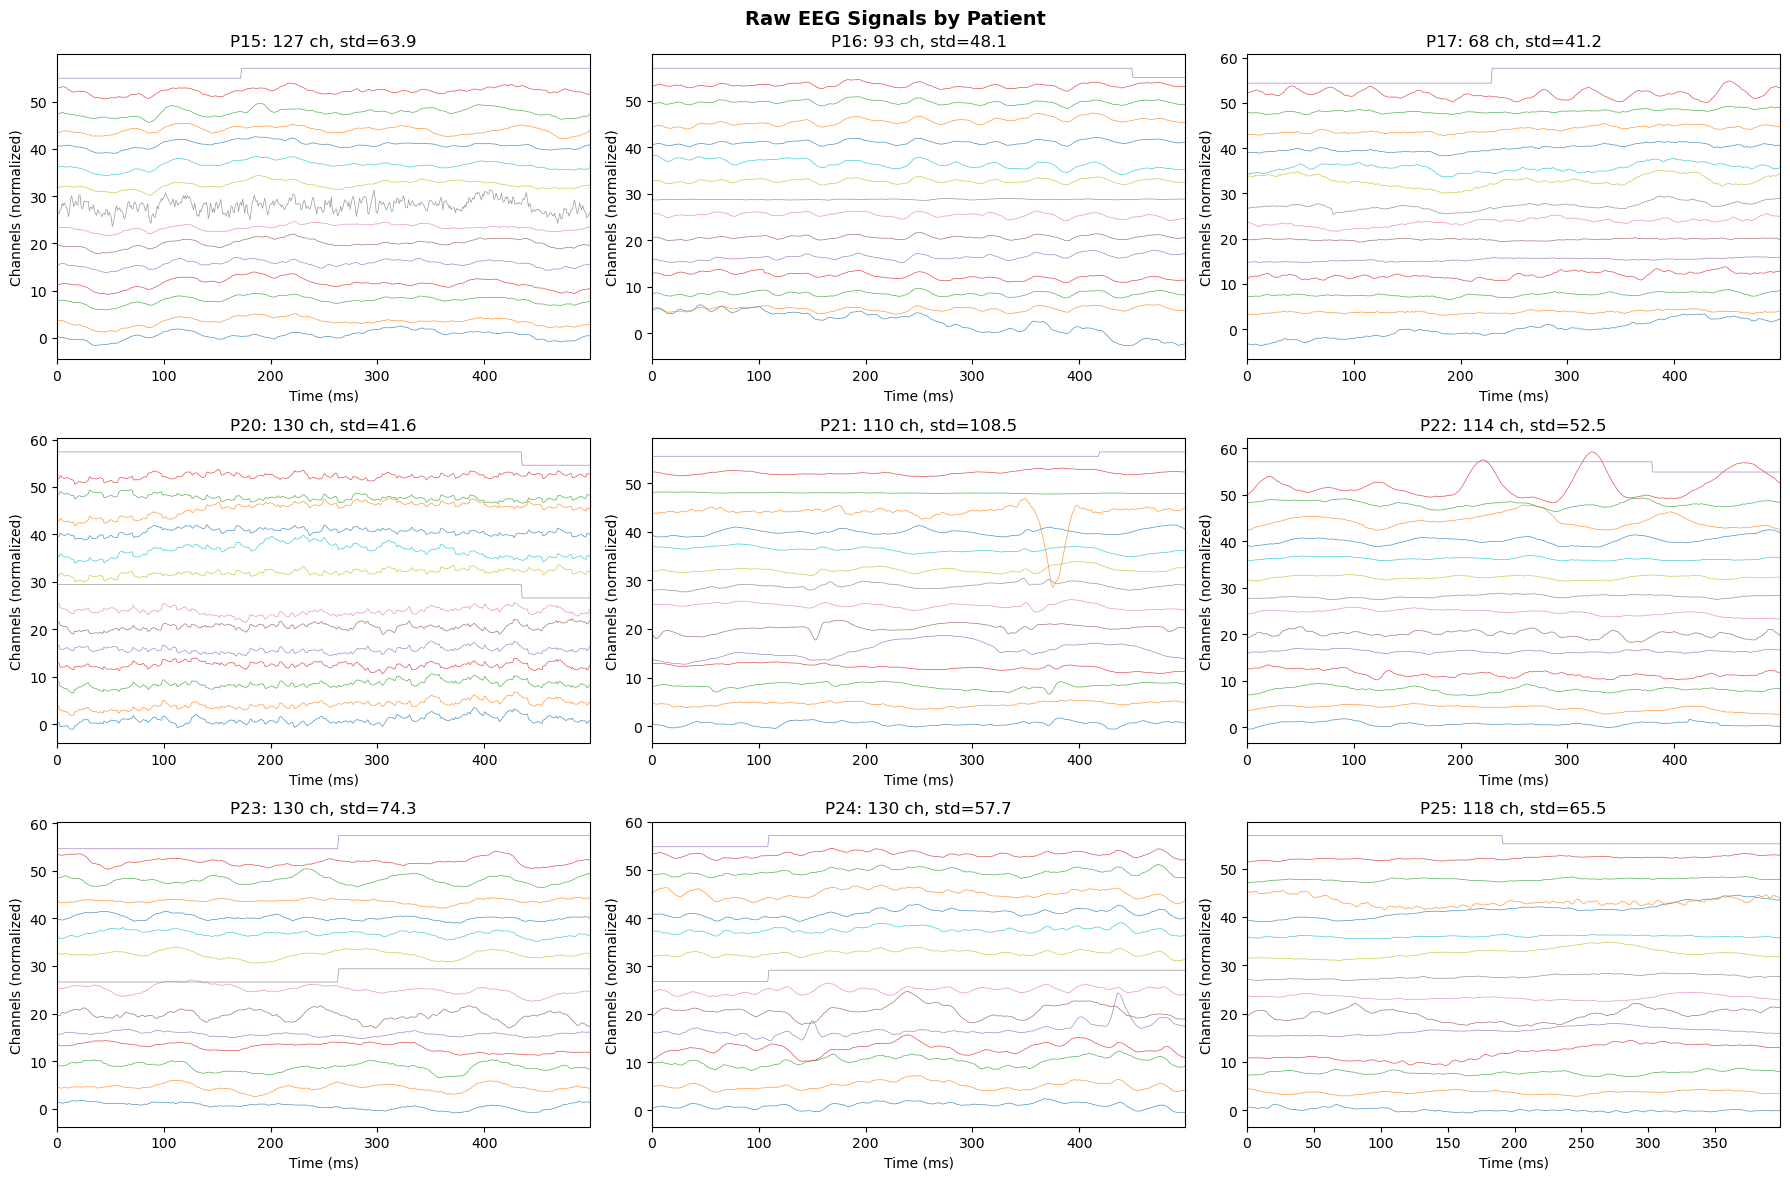


PATIENT SIGNAL STATISTICS
Patient    Channels   Std          Range        Mean|x|     
----------------------------------------------------------------------
P15        127        63.95        2495.90      42.02       
P16        93         48.06        1403.22      46.36       
P17        68         41.24        1692.87      25.41       
P20        130        41.62        1920.31      27.27       
P21        110        108.49       2361.91      78.80       
P22        114        52.49        1606.93      37.08       
P23        130        74.33        3210.45      50.00       
P24        130        57.68        1459.86      46.30       
P25        118        65.46        1158.20      44.03       

2. CHANNEL DISTRIBUTIONS


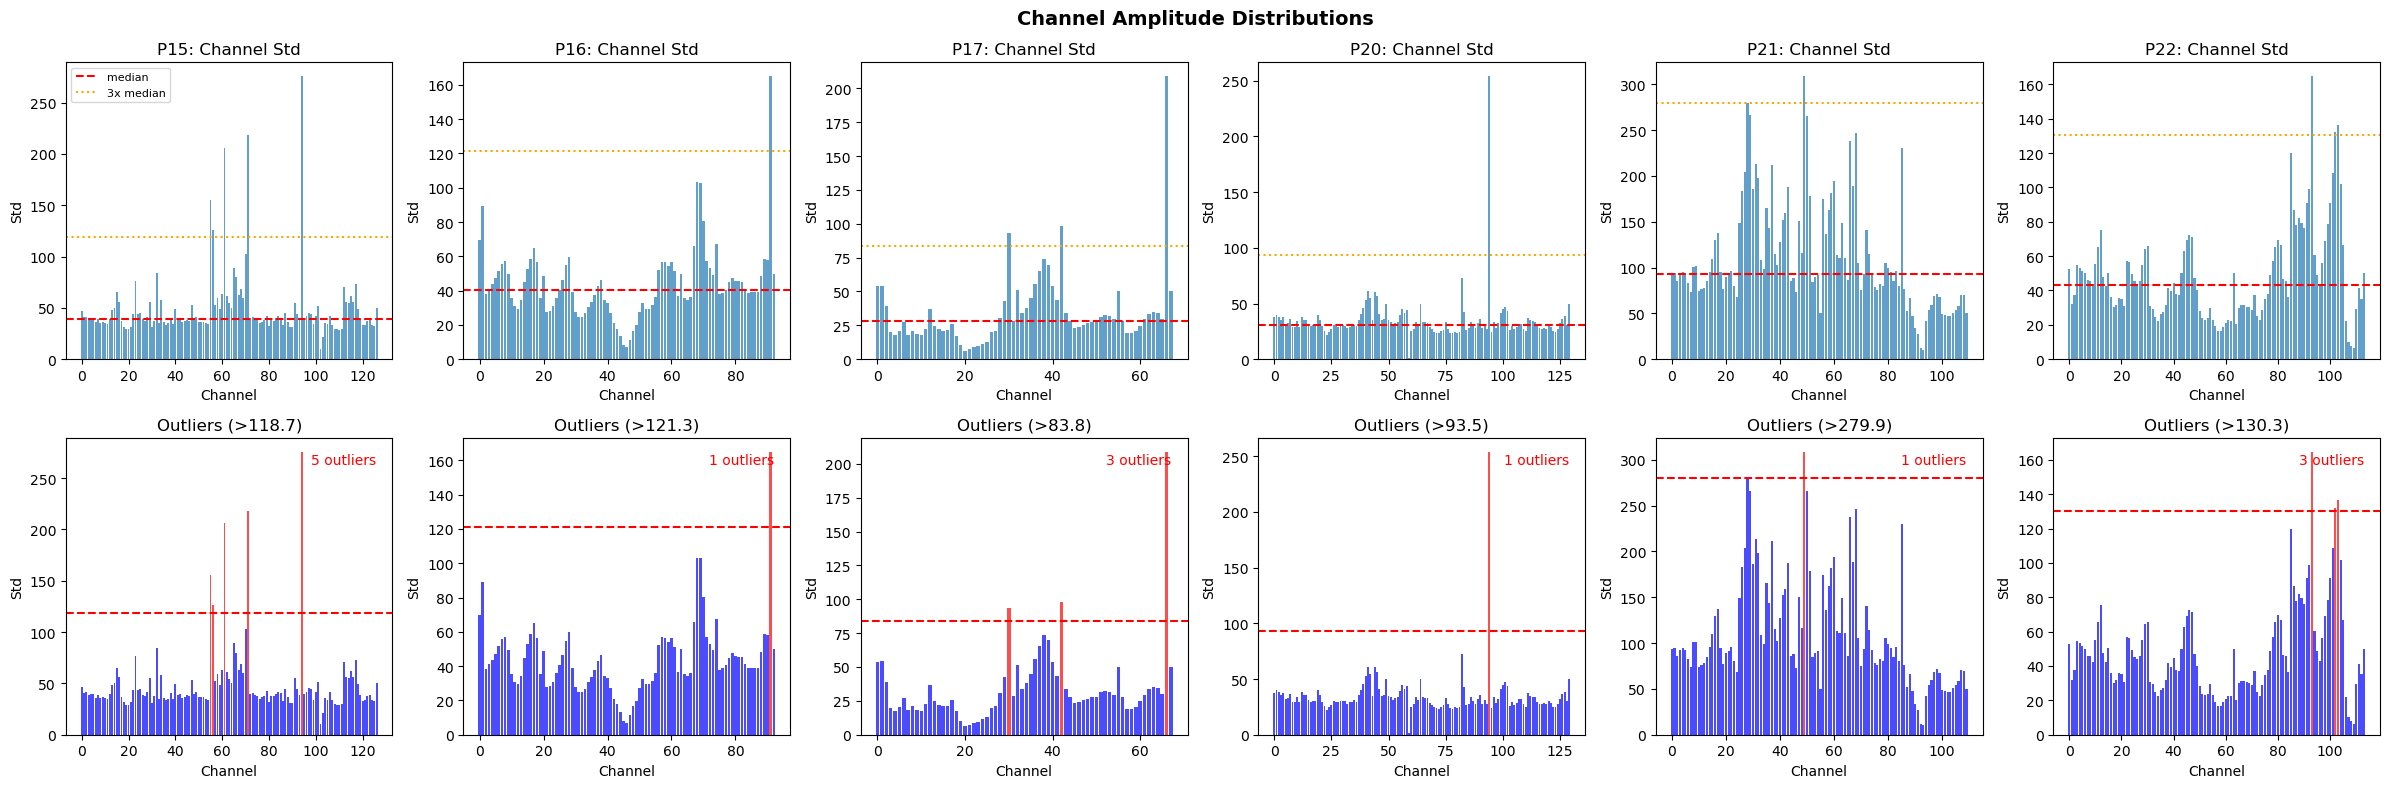


3. POWER SPECTRA


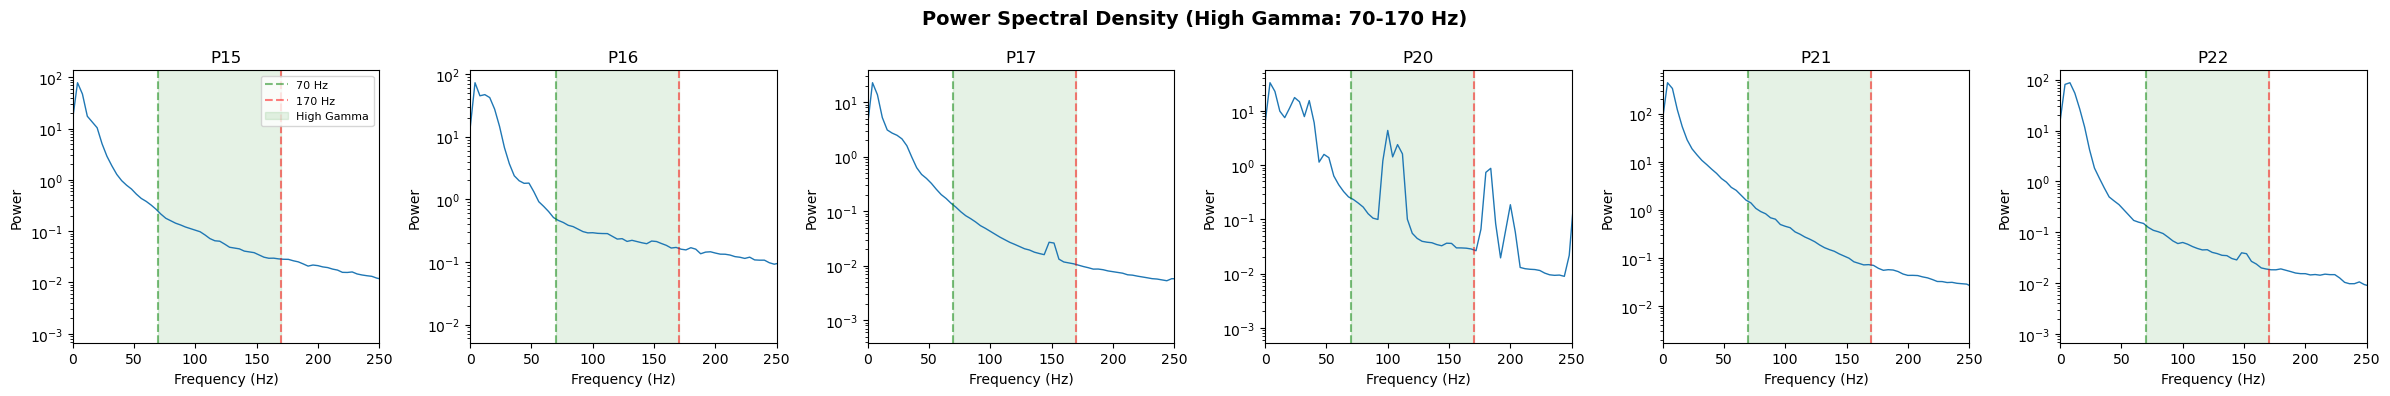


4. EXTRACTED FEATURES

FEATURE STATISTICS BY PATIENT
Patient    Samples    Mean         Std          Min          Max         
----------------------------------------------------------------------
P15        240        -0.7198      7.7583       -65.3775     276.4415    
P21        1159       -1.3198      5.4481       -21.5908     181.6921    
P24        1341       -0.3535      1.3881       -14.3640     43.3557     
P17        242        -0.2950      1.0876       -9.2439      24.7097     
P22        1399       -0.3119      1.0352       -4.1304      70.6855     
P16        240        -0.2177      1.0019       -15.7615     14.3649     
P20        234        -0.4651      1.5837       -5.6929      26.6724     
P25        1184       -0.5601      3.5960       -80.6790     60.8497     


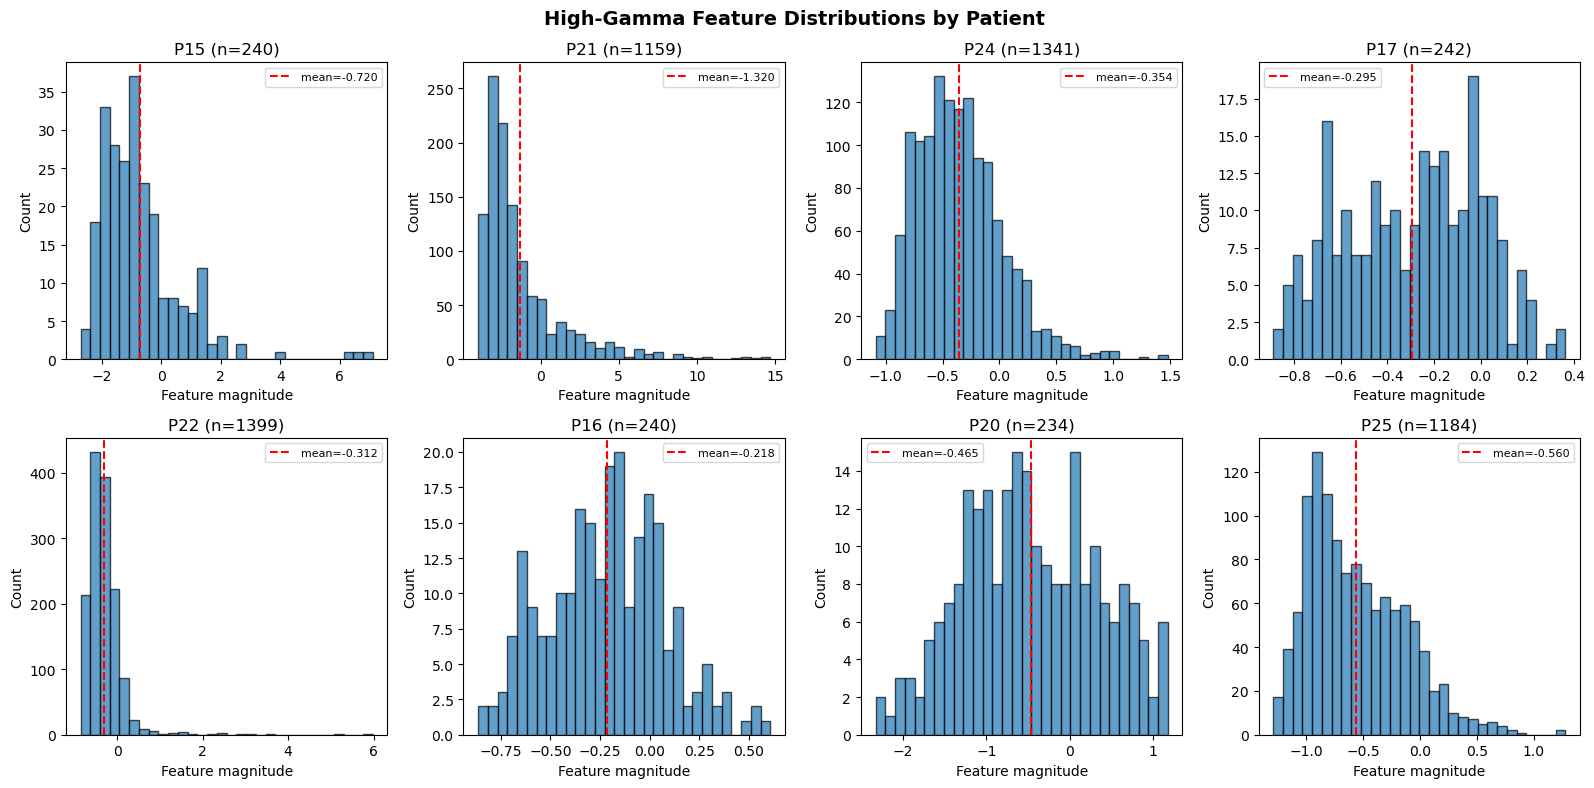

In [29]:
def visualize_patient_signals(pipeline, patient_ids=None, duration_sec=1.0, n_channels_to_show=20):
    """
    Visualize raw EEG signals for each patient to identify signal quality issues.
    
    Args:
        pipeline: Pipeline with loaded data
        patient_ids: List of patient IDs to visualize (default: all available)
        duration_sec: Duration of signal to show in seconds
        n_channels_to_show: Number of channels to display per patient
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    if patient_ids is None:
        patient_ids = list(pipeline.split_result['word_segments_dict'].keys())
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    n_patients = len(patient_ids)
    n_cols = min(3, n_patients)
    n_rows = (n_patients + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    if n_patients == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    patient_stats = {}
    
    for idx, pid in enumerate(patient_ids):
        ax = axes[idx]
        
        if pid not in word_segments_dict:
            ax.set_title(f"{pid}: No data")
            continue
        
        # Get first word's EEG segment
        words_data = word_segments_dict[pid]['words']
        first_word = list(words_data.keys())[0]
        eeg_segment = words_data[first_word]['instances'][0]['eeg_segment']
        
        n_samples = min(int(duration_sec * config.eeg_sr), eeg_segment.shape[0])
        n_channels = eeg_segment.shape[1]
        channels_to_plot = min(n_channels_to_show, n_channels)
        
        # Select evenly spaced channels
        channel_indices = np.linspace(0, n_channels-1, channels_to_plot, dtype=int)
        
        # Time axis
        time = np.arange(n_samples) / config.eeg_sr * 1000  # in ms
        
        # Plot each channel with offset
        eeg_subset = eeg_segment[:n_samples, channel_indices]
        
        # Normalize for visualization
        eeg_norm = eeg_subset / (np.std(eeg_subset) + 1e-10)
        
        # Add offset for each channel
        offsets = np.arange(channels_to_plot) * 4  # 4 std units between channels
        eeg_offset = eeg_norm + offsets
        
        for ch_idx in range(channels_to_plot):
            ax.plot(time, eeg_offset[:, ch_idx], linewidth=0.5, alpha=0.8)
        
        # Calculate stats
        signal_std = np.std(eeg_segment)
        signal_range = np.ptp(eeg_segment)
        signal_mean = np.mean(np.abs(eeg_segment))
        
        patient_stats[pid] = {
            'n_channels': n_channels,
            'std': signal_std,
            'range': signal_range,
            'mean_abs': signal_mean
        }
        
        ax.set_title(f"{pid}: {n_channels} ch, std={signal_std:.1f}")
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Channels (normalized)")
        ax.set_xlim([0, time[-1]])
    
    # Hide unused axes
    for idx in range(n_patients, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Raw EEG Signals by Patient", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print("PATIENT SIGNAL STATISTICS")
    print("="*70)
    print(f"{'Patient':<10} {'Channels':<10} {'Std':<12} {'Range':<12} {'Mean|x|':<12}")
    print("-"*70)
    
    for pid in sorted(patient_stats.keys()):
        stats = patient_stats[pid]
        print(f"{pid:<10} {stats['n_channels']:<10} {stats['std']:<12.2f} "
              f"{stats['range']:<12.2f} {stats['mean_abs']:<12.2f}")
    
    return patient_stats


def visualize_channel_distributions(pipeline, patient_ids=None):
    """
    Show distribution of signal amplitude across channels for each patient.
    Helps identify outlier channels.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    if patient_ids is None:
        patient_ids = list(pipeline.split_result['word_segments_dict'].keys())[:6]
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(2, n_patients, figsize=(4*n_patients, 8))
    
    if n_patients == 1:
        axes = axes.reshape(2, 1)
    
    for idx, pid in enumerate(patient_ids):
        if pid not in word_segments_dict:
            continue
        
        # Collect EEG from multiple words
        words_data = word_segments_dict[pid]['words']
        all_eeg = []
        
        for word, word_info in list(words_data.items())[:20]:
            for instance in word_info['instances'][:3]:
                eeg = instance['eeg_segment']
                all_eeg.append(eeg)
        
        if not all_eeg:
            continue
        
        # Concatenate all segments
        eeg_concat = np.vstack(all_eeg)
        n_channels = eeg_concat.shape[1]
        
        # Calculate per-channel statistics
        channel_std = np.std(eeg_concat, axis=0)
        channel_mean = np.mean(eeg_concat, axis=0)
        channel_range = np.ptp(eeg_concat, axis=0)
        
        # Top plot: Channel std
        ax1 = axes[0, idx]
        ax1.bar(range(n_channels), channel_std, alpha=0.7)
        ax1.axhline(np.median(channel_std), color='r', linestyle='--', label='median')
        ax1.axhline(np.median(channel_std) * 3, color='orange', linestyle=':', label='3x median')
        ax1.set_title(f"{pid}: Channel Std")
        ax1.set_xlabel("Channel")
        ax1.set_ylabel("Std")
        if idx == 0:
            ax1.legend(fontsize=8)
        
        # Bottom plot: Identify outliers
        ax2 = axes[1, idx]
        median_std = np.median(channel_std)
        outlier_threshold = median_std * 3
        
        colors = ['red' if s > outlier_threshold else 'blue' for s in channel_std]
        ax2.bar(range(n_channels), channel_std, color=colors, alpha=0.7)
        ax2.axhline(outlier_threshold, color='red', linestyle='--')
        ax2.set_title(f"Outliers (>{outlier_threshold:.1f})")
        ax2.set_xlabel("Channel")
        ax2.set_ylabel("Std")
        
        # Count outliers
        n_outliers = sum(1 for s in channel_std if s > outlier_threshold)
        ax2.text(0.95, 0.95, f"{n_outliers} outliers", transform=ax2.transAxes,
                ha='right', va='top', fontsize=10, color='red')
    
    plt.suptitle("Channel Amplitude Distributions", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def visualize_signal_spectra(pipeline, patient_ids=None):
    """
    Show power spectral density for each patient to check frequency content.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.signal import welch
    
    if patient_ids is None:
        patient_ids = list(pipeline.split_result['word_segments_dict'].keys())[:6]
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(1, n_patients, figsize=(4*n_patients, 4))
    
    if n_patients == 1:
        axes = [axes]
    
    for idx, pid in enumerate(patient_ids):
        ax = axes[idx]
        
        if pid not in word_segments_dict:
            continue
        
        # Get EEG data
        words_data = word_segments_dict[pid]['words']
        all_eeg = []
        
        for word, word_info in list(words_data.items())[:10]:
            for instance in word_info['instances'][:2]:
                eeg = instance['eeg_segment']
                all_eeg.append(eeg)
        
        if not all_eeg:
            continue
        
        eeg_concat = np.vstack(all_eeg)
        n_channels = eeg_concat.shape[1]
        
        # Compute average PSD across channels
        psds = []
        for ch in range(min(20, n_channels)):  # Sample 20 channels
            freqs, psd = welch(eeg_concat[:, ch], fs=config.eeg_sr, nperseg=256)
            psds.append(psd)
        
        avg_psd = np.mean(psds, axis=0)
        
        # Plot
        ax.semilogy(freqs, avg_psd, linewidth=1)
        ax.axvline(70, color='g', linestyle='--', alpha=0.5, label='70 Hz')
        ax.axvline(170, color='r', linestyle='--', alpha=0.5, label='170 Hz')
        ax.axvspan(70, 170, alpha=0.1, color='green', label='High Gamma')
        
        ax.set_title(f"{pid}")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power")
        ax.set_xlim([0, 250])
        if idx == 0:
            ax.legend(fontsize=8)
    
    plt.suptitle("Power Spectral Density (High Gamma: 70-170 Hz)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def compare_patient_features(pipeline, patient_ids=None):
    """
    Compare extracted high-gamma features across patients.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import defaultdict
    
    if patient_ids is None:
        patient_ids = list(set(pipeline.train['phoneme_participant_ids']))[:8]
    
    train_data = pipeline.train
    
    # Group features by patient
    patient_features = defaultdict(list)
    
    for i, feat in enumerate(train_data['features']):
        pid = train_data['phoneme_participant_ids'][i]
        if pid in patient_ids:
            if feat.ndim > 1:
                feat_agg = feat.mean(axis=0)
            else:
                feat_agg = feat
            patient_features[pid].append(feat_agg)
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(2, min(4, n_patients), figsize=(16, 8))
    axes = axes.flatten()
    
    print("\n" + "="*70)
    print("FEATURE STATISTICS BY PATIENT")
    print("="*70)
    print(f"{'Patient':<10} {'Samples':<10} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
    print("-"*70)
    
    for idx, pid in enumerate(patient_ids[:8]):
        if pid not in patient_features:
            continue
        
        features = np.array(patient_features[pid])
        
        # Stats
        feat_mean = np.mean(features)
        feat_std = np.std(features)
        feat_min = np.min(features)
        feat_max = np.max(features)
        
        print(f"{pid:<10} {len(features):<10} {feat_mean:<12.4f} {feat_std:<12.4f} "
              f"{feat_min:<12.4f} {feat_max:<12.4f}")
        
        if idx < len(axes):
            ax = axes[idx]
            
            # Plot feature distribution (mean across channels)
            feature_means = np.mean(features, axis=1)
            ax.hist(feature_means, bins=30, alpha=0.7, edgecolor='black')
            ax.axvline(np.mean(feature_means), color='r', linestyle='--', 
                      label=f'mean={np.mean(feature_means):.3f}')
            ax.set_title(f"{pid} (n={len(features)})")
            ax.set_xlabel("Feature magnitude")
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
    
    # Hide unused axes
    for idx in range(len(patient_ids), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("High-Gamma Feature Distributions by Patient", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return patient_features


# Run all visualizations
print("1. RAW SIGNAL OVERVIEW")
patient_stats = visualize_patient_signals(high_gamma_pipeline, duration_sec=0.5, n_channels_to_show=15)

print("\n2. CHANNEL DISTRIBUTIONS")
visualize_channel_distributions(high_gamma_pipeline)

print("\n3. POWER SPECTRA")
visualize_signal_spectra(high_gamma_pipeline)

print("\n4. EXTRACTED FEATURES")
patient_features = compare_patient_features(high_gamma_pipeline)